<a href="https://colab.research.google.com/github/todd-jang/AIFFEL_quest_rs/blob/main/GoingDeeper/07_BERT/BERT_pretrained_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 들어가며

## 변화의 흐름 - Word Embedding과 Context
---
우리는 NLP task를 풀기 위하여 인간의 언어를 컴퓨터의 언어로 바꾸어 주는 작업을 반드시 거쳐야만 합니다(임베딩). 단어가 가지고 있는 의미를 숫자에 녹여내기 위해서 tf-idf, word2vec, fasttext 등 다양한 임베딩 방법들을 공부해 보기도 했지요. 우리가 기존에 배웠던 임베딩 방식은 워드임베딩(Word Embedding)이라고 합니다. 즉, 단어 하나하나를 임베딩하는 방식이지요.

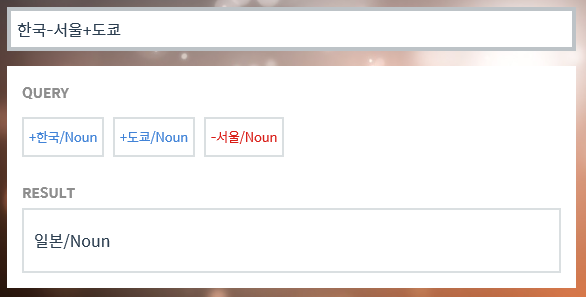

[학습이 끝난 word embedding으로 단어들 간의 거리 재보기(출처 : http://w.elnn.kr/search/)]

워드 임베딩은 학습이 완료되면 각 단어 하나하나가 특정 임베딩(벡터)을 가지게 됩니다. 그래서 우리는 위와 같이 단어 사이의 거리를 재고, 관계를 파악할 수 있었던 것이죠.

혹시...

생각해 본 적 있나요?
생긴 것은 똑같이 생겼는데 다른 뜻을 가지고 있는 단어들(동음이의어, 다의어 등)은 어떻게 표현될지?

**[아이스브레이킹] 베를린 음식이 위험한 이유는 왜일까요?**

A. [ 독일 수도! ]

<details>
<summary>💡예시답안 확인하기💡</summary>

조심해야지요~독일 수도... 🤣🤣🤣

없어도 괜찮아요. 이제 생각해 보면 되죠.🤓
예시를 보면서 생각해 봅시다.

**예시 1) bank**

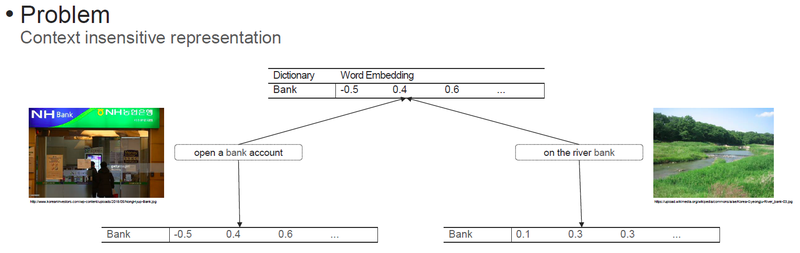

**예시 2) 차**
  1. 시간이 늦었으니 커피 말고 `차`나 한 잔 마시자
  2. 제주도는 버스로 움직이기 힘들어. `차`가 있어야 해.
  3. 축구공을 이쪽으로 `차`.

이제 어떤 문제가 발생하는지 감이 오시나요?

워드 임베딩 방법들은, 주변 단어를 **학습할 때만** 고려하게 됩니다. 다른 모델의 입력으로써 사용할 때(학습된 벡터들을 이용하여 input 단어들을 벡터화시킬 때)는 동음이의어, 다의어와 같은 경우들을 모두 고정된 하나의 벡터로 표현하게 되면서 주변의 단어들을 고려하지 않게 되는 것이죠. 정작 학습할 때는 문맥을 열심히 보더니, 테스트할 때는 현재 단어 한 개만 보는 모양새가 되어버렸습니다.3

똑똑한 여러분은 '문맥을 고려하는 임베딩(Contextual Embedding)을 만들면 되지 않나?!'라고 생각하실 겁니다.

네! 맞습니다! 바로 앞으로 등장하는 모델들은 이러한 **문맥(context)** 을 잘 반영하는 모델들입니다.

## 학습 목표
---
  - 최근 NLP 모델 발전의 흐름을 이해하고 설명할 수 있다.

  - 대표적인 모델에 사용된 훈련 방법을 파악하고, 이를 사용할 수 있다.

  - Task에 맞는 모델을 선택하여 활용할 수 있다.

## 학습 내용
---
  - 2. Transfer Learning과 Language Modeling
    - 전이학습과 LM의 정의는?
  - 3. ELMO(Embedding from Language Models)
    - 단어 표현을 문맥에 맞게!
  - 4. GPT(Generative Pre-Training Transformer)
    - 거대한 변화의 서막, GPT
  - 5. BERT(Bidirectional Encoder Representations from Transformers)
    - ?요까일보 잘 더 면으집뒤
  - 6. Transformer-XL(Transformer Extra Long)
    - 길이는 더 이상 문제가 되지 않는다!
  - 7. XLNet, BART
    - 더 길게, 더 다양하게
  - 8. ALBERT(A Lite BERT for Self-supervised Learning of Language Representations)
    - 트랜스포머도 가볍게 만들 수 있어요.
  - 9. T5(Text-to-Text Transfer Transformer)
    - 전이학습을 극한까지 끌어올려보아요.
  - 10. Switch Transformer
    - T5도 가볍게 만들 수...있어요?
  - 11. ERNIE
    - 마스킹 _ 법을 통해 la_guage rep__sent_tion을 향상_켰어요.

# Transfer Learning과 Language Modeling

## Transfer Learning(전이 학습)
---
전이 학습이란 말 들어보셨나요? 단어 자체는 들어보지 않아도 개념들은 한 번씩 접해보셨으리라 생각합니다.

pretrain과 fine-tuning으로 더 많이 들었을지도 모르겠네요.

**Q. 예시를 들어 전이학습을 쉽게 설명해볼까요?**

A. [ 학습을 마친 신경망(일부 혹은 전부)을 유사하거나 다른 환경에서 사용하는 것을 의미합니다. 쉽게 생각해 보면, 사과를 깎는 것을 배운 아이에게 배를 깎도록 다시 학습시키는 거죠! ]

<details>
<summary>💡예시답안 확인하기💡</summary>

전이 학습은 특정 환경에서 학습을 마친 신경망(일부 혹은 전부)을 유사하거나 다른 환경에서 사용하는 것을 의미합니다. 쉽게 생각해 보면, 사과를 깎는 것을 배운 아이에게 배를 깎도록 다시 학습시키는 거죠. 이미 사과를 깎는 것을 배웠으니 비슷하게 생긴 배도 유사한 방법으로 쉽게 깎을 수 있을 것이라고 생각이 들죠?

이처럼 전이 학습을 이용하게 되면 적은 데이터로도 성능을 곧잘 만들어 낼 수 있다는 이점이 있습니다.

그렇다면 자연어에서의 전이 학습은 언제, 어디서 사용되는 것일까요?

## Language Modeling(언어 모델)
---
자연어 처리에서의 전이 학습은 보통 language model(언어 모델)과 관련이 깊습니다.

언어 모델은 입력으로 주어진 시퀀스의 다음을 학습하는 과정에서 주어진 시퀀스가 얼마나 자연스러운지를 학습하게 됩니다. 즉, 언어 모델은 `철수가 밥을 마셨다`인지 `철수가 밥을 먹었다`인지를 데이터로부터 학습을 하게 됩니다. 이렇게 학습을 완료한 언 어모델은 언어의 패턴과 규칙을 학습하여 전반적인 언어의 특징을 익히게 됩니다.

자연어 처리에서 바로 이 언어 모델이 pretrained model이 되는 것입니다. 이미 언어의 전반적인 것을 아는 신경망에게 언어와 관련된 문제를 풀게 하는 것이지요. 이처럼 주어진 문제(다운스트림 테스크 혹은 downstream task)를 잘 풀기 위해 pretrained model을 재학습시키는 것을 fine-tuning이라고 부릅니다.

## Transformer
---
사실 최근 NLP의 가장 큰 흐름은 트랜스포머라고 해도 무방하다고 생각합니다. GPT, BERT 등 이후에 만들어지는 모델들은 트랜스포머가 기반이기 때문이죠.
또한, BERT를 시작으로 BERT를 개선하는 수많은 모델들이 나오기 시작했습니다. 성능 또한 향상되었구요!

따라서 modern NLP라고 하면 Transformer를 빼놓을 수 없답니다!

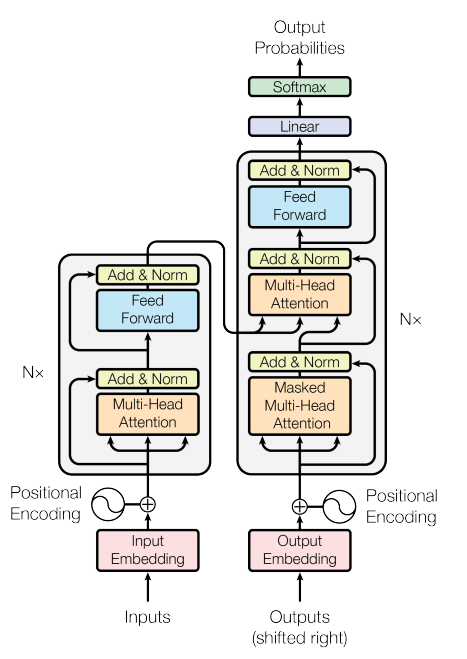

여기까지 오신 여러분들은 이미 트랜스포머의 모델 구조나 특징에 대해 익숙하실 거로 생각합니다. 트랜스포머에 대해 간략하게 짚고 넘어가 보죠.

트랜스포머는 Encoder-Decoder 구조로, RNN이나 LSTM 등을 사용하지 않고 attention만을 이용한 모델입니다. 그래서 비록 LSTM 등 RNN 구조를 사용하지 않지만 번역기 모델 등에 사용하는 seq2seq 모델과 구조적으로는 동일합니다. Encoder-Decoder 모델이라면 입력부터 출력까지의 파이프라인이 이미 고정되어 있어서 이를 이용해 임베딩을 구하거나 전이 학습을 통해 다른 태스크에 활용하기 어려울 것 같습니다. 그렇다면 transformer 모델이 어떻게 modern NLP의 토대를 이루는 중요한 모델로 발전할 수 있었을까요?

*'너무 간략한 거 아니야?' 라고 생각하실 수도 있지만, 갈 길이 멀기 때문에 핵심적인 구조만 짚었습니다*

최근 자연어 처리에서 가장 중요한 부분인 contextualized embedding과 transfer learning, transformer까지 대략 짚어 보았습니다. 이 개념들을 통하여 최근 흐름에 올라타 보실까요?

# ELMO(Embedding from Language Models)

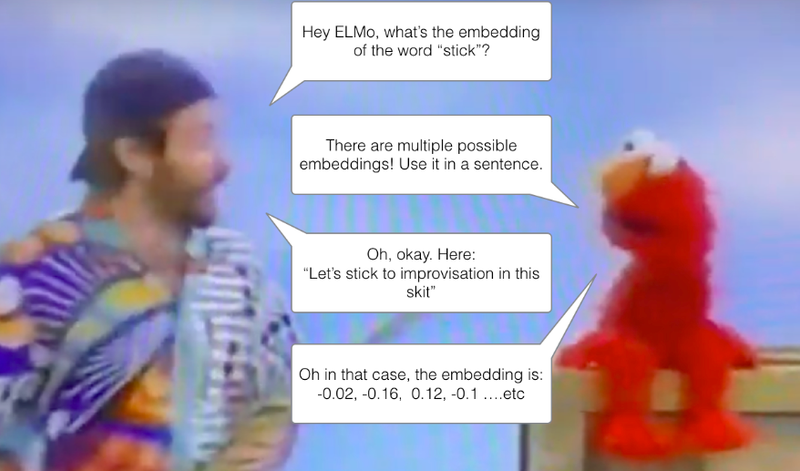

https://jalammar.github.io/images/elmo-embedding-robin-williams.png

ELMo는 문맥(context)을 반영한 임베딩을 pretrained model로 구현한 첫 번째 사례입니다. 언어 모델을 이용하여 임베딩을 한 것인데요. 이름에 포함된 LM이 바로 이 언어 모델을 가리키죠.

## ELMo의 구조
---
ELMo는 세 가지 요소로 구성되어 있습니다. 첫 번째는 character-level CNN, 두 번째는 bidirectional LSTM, 마지막으로 ELMo 레이어가 있습니다. 각각 어떤 역할을 하고 있는지 하나씩 살펴보도록 하겠습니다.

**1. character-level CNN**

character-level CNN은 입력된 문자들 간의 관계를 파악하고 임베딩 벡터로 변환하는 역할을 합니다.

ELMo는 character level로 문자를 인식합니다. 좀 더 구체적으로 말한다면, 해당 character의 유니코드 ID를 입력으로 받습니다. 예를 들어, `밥`이라는 단어를 입력으로 받으면 `ㅂㅏㅂ`에 해당되는 유니코드 `235, 176, 165` 세 개의 숫자가 됩니다.

이렇게 각각 입력받은 단어의 시작과 끝에 해당하는 스페셜 토큰 `<BOW>`와 `<EOW>`에 해당하는 유니코드를 앞뒤로 붙여줍니다. 이후 각 유니코드 아이디에 해당하는 행 벡터를 참조하여 붙입니다.(look-up table)

만들어진 벡터에 (n x 임베딩 차원 수) 사이즈의 필터로 컨볼루션하여 피처맵을 만들고 max-pooling하여 하나의 값을 뽑아냅니다. 이러한 작업을 반복하여 사용자가 원하는 크기만큼의 벡터로 만들어냅니다.

여기서 n은 한 번에 몇 개의 문자들을 함께 볼 것인가를 의미합니다. n이 2라면 `<BOW> ㅂ`, `ㅂ ㅏ`, `ㅏ ㅂ`, `ㅂ <EOW>` 이렇게 문자 2개씩 보면서 2개 사이의 관계를 파악하는 CNN이 됩니다.

ELMo의 original 코드에서는 각기 다른 사이즈를 가진 7개의 필터를 이용하여 2048차원의 벡터를 만든다고 합니다.

**2. bidirectional LSTM**

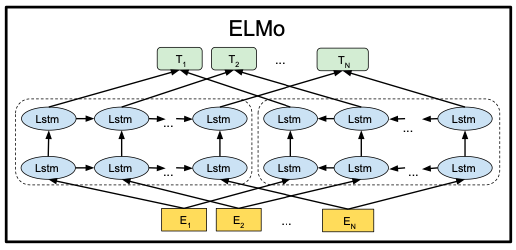

[ELMo의 구조 (출처 : https://arxiv.org/pdf/1810.04805.pdf)]

haracter-level CNN을 통과하여 만들어진 벡터$(E_1, E_2, ..., E_N$들은 bidirectional LSTM을 통과하게 됩니다.

pretrain시에 bidirectional LSTM은 주어진 입력에 다음에 올 단어들을 예측합니다.(bidirectional LM이라고도 불리웁니다.)

bidirectional이라는 것은 양방향으로 학습하는 것을 의미합니다. 주어진 입력을 한 번은 순방향으로, 한 번은 역방향으로 각각 2개의 LSTM layer를 통과하게 됩니다. 이렇게 양방향으로 학습하는 것은 모델의 사이즈와 학습에 걸리는 시간이 늘어날 수는 있지만 그만큼 성능이 좋답니다.

pretrain 시, 순방향과 역방향으로 LSTM을 통과한 히든 벡터들은 이후 softmax(소프트 맥스)를 취해 다음 단어를 예측하게 됩니다. 이때 **ELMo는 순방향과 역방향의 벡터를 합치거나 더하지 않습니다.** 각각의 **독립적인** 모델처럼 행동하게 되는데요. 이는 조금만 생각해 보면 이유를 알 수 있습니다. 하나는 순방향으로, 하나는 역방향으로 진행하다 보니 cheating(다른 방향의 모델에게 정답을 가르쳐 줌)의 가능성이 있기 때문이죠.

이렇게 ELMo는 단어를 하나씩 하나씩 슬라이딩하여 다음 단어를 예측하면서 문장 내의 단어와 단어들 사이의 관계를 학습하게 됩니다.

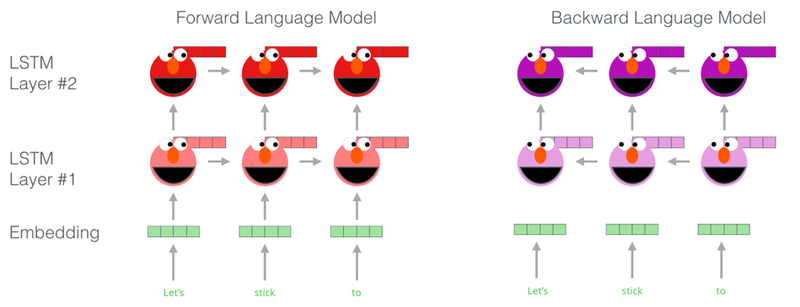

[pretrain을 끝마친 bidirectional LSTM(출처:https://jalammar.github.io/illustrated-bert/)]

**3. ELMO 임베딩 레이어**

ELMo 임베딩은 pretrain이 끝나고 finetuning을 하는 과정에서 만들어집니다.

맨 위 그림에서 Elmo 인형과의 대화처럼 `stick`이란 단어의 임베딩을 구한다고 가정해 봅시다.

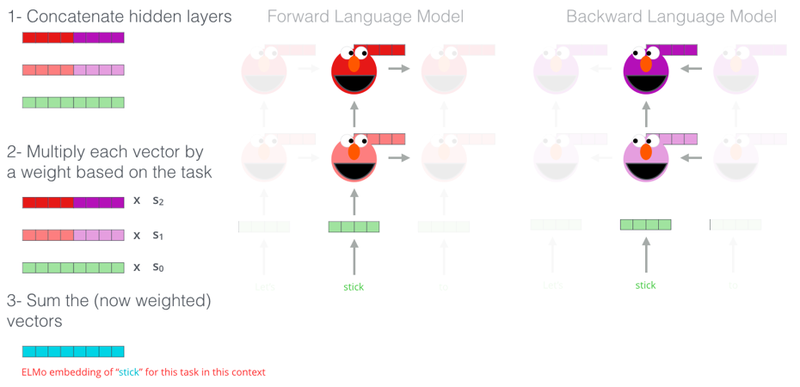


[ELMo embedding을 구하는 과정(출처:https://jalammar.github.io/illustrated-bert/)]

우선 구하려고 하는 토큰에 대한 각 층의 출력값을 모두 가지고 옵니다. 여기서의 각 층의 출력값이라고 하면, 임베딩 벡터(character-level CNN을 통과한 후 나오는 벡터), 각각의 LSTM layer에서의 hidden vector를 의미합니다.

각 층 $1,2,...,l,...$마다 가중치 $s_1, s_2, ...s_l, ...$를 곱해서 모두 더해줍니다.(weighted sum 혹은 가중합을 해준다고 말할 수 있습니다.)

마지막으로 다운스트림 태스크의 가중치 **γ**를 곱하면 ELMo의 임베딩이 됩니다.

여기서 갑자기 등장하는 가중치 $s_l$와 **γ**는 다운스트림 태스크별로 **finetuning 시 학습**되는 값들입니다.

복잡해 보이지만, **구하고자 하는 토큰에 대한 각 층의 출력값을 가중합한 것**이 ELMo 임베딩입니다.

## ELMo의 이용
---

**Q. 이렇게 구한 ELMo는 어디에, 어떻게 사용할 수 있을까요?**

A. [ 텍스트 데이터를 임베딩할 수 있습니다. 기존에 학습시킨 워드 임베딩과 같이 사용할 수도 있습니다. 논문에서는 ELMo로 임베딩 한 데이터를 6가지 task로 평가합니다(Question answering, textual entailment, semantic role labeling, coreference resolution, named entity extraction, sentiment analysis) ]

<details>
<summary>💡예시답안 확인하기💡</summary>

ELMo를 이용하여 텍스트 데이터를 임베딩할 수 있습니다.
기존에 학습시킨 워드 임베딩과 같이 사용할 수도 있습니다.
논문에서는 ELMo로 임베딩 한 데이터를 6가지 task로 평가합니다(Question answering, textual entailment, semantic role labeling, coreference resolution, named entity extraction, sentiment analysis).

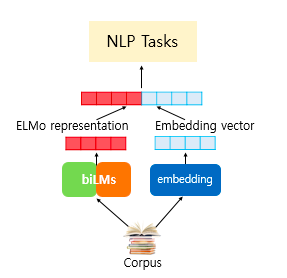

[ELMo 의 활용(출처: https://wikidocs.net/33930)]

더욱더 자세히 알아보고 싶다면 ELMo의 논문을 직접 읽어보세요!

  - [Deep contextualized word representations](https://arxiv.org/abs/1802.05365)

# GPT(Generative Pre-Training Transformer)

GPT는 **트랜스포머의 decoder 구조만을 이용하여 만든 네트워크**입니다. 트랜스포머의 decoder를 아주 깊고 깊게 쌓아 많은 데이터를 학습 시켜 성능을 높힌 네트워크죠!

## GPT의 구조
---
'Decoder만을 이용했다는 게 뭐야?'🤔 라는 생각이 드실 겁니다.

Transformer-Decoder를 한 번 더 보고 가시죠.

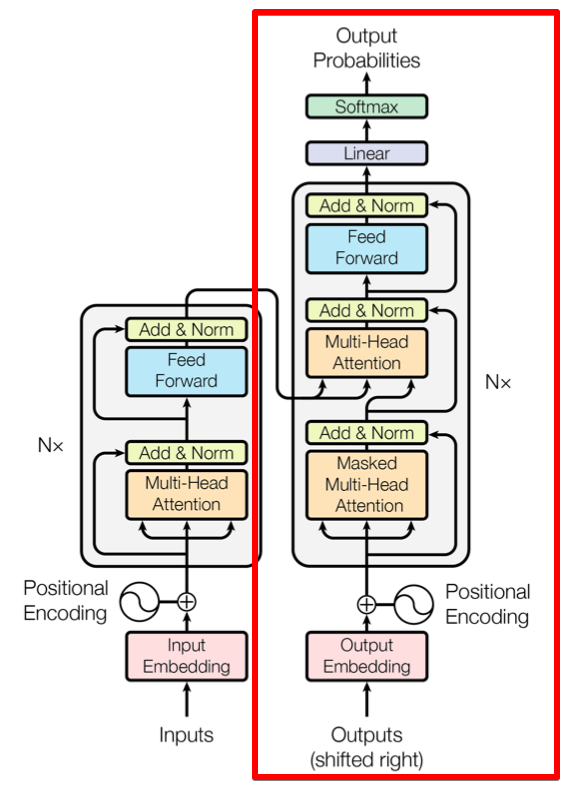

Decoder는 masked Multi-Head Attention, Multi-Head Attention, Feed Forward Neural Network로 이루어져 있었습니다. 바로 이 구조를 차용하여 Decoder block를 많이 쌓아 올리면?!

따란- GPT가 되는 것이죠.

🤔 '이게 다야?'라는 말이 절로 나오죠ㅎㅎㅎ;;;

이제 GPT를 두 부분으로 나누어서 좀 더 자세히 보겠습니다.

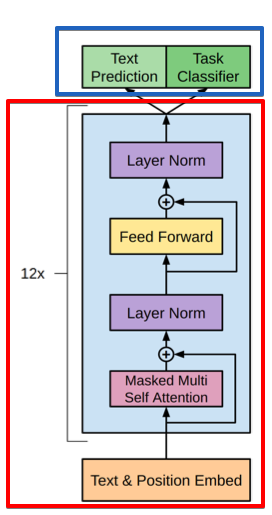

[GPT의 모델 구조(출처:https://s3-us-west-2.amazonaws.com/openai-assets/research-covers/language-unsupervised/language_understanding_paper.pdf)]

Transfomer Decoder Block : Pretraining LM (Unspervised Learning)
첫 번째로 볼 부분은 빨간색 박스 안입니다. pretrain 하는 부분으로 unsupervised learning(비지도 학습)을 하게 됩니다. 위에 트랜스포머의 구조 그대로죠?

**1. Embedding**

GPT는 텍스트의 Embedding으로 **BPE(Byte-pair Encoding)** 를 사용하고 있어요.

BPE는 모든 단어를 문자(바이트)들의 집합으로 취급하여 자주 등장하는 문자 쌍을 합치는 subword tokenization이었죠! 처음 보는 단어일지라도 문자(알파벳)들의 조합으로 나타내어 **OOV** 문제를 해결할 수 있다는 장점이 있었습니다.

기존 트랜스포머와 마찬가지로 position encoding(포지션 인코딩)도 함께 사용한답니다.

**2. Masked Multi-Head Attention**

**Masked Multi-Head Attention**은 모든 것을 병렬적으로 처리하는 트랜스포머에게 자기회귀적(Autoregressive)인 특성을 부여하기 위해 만든 장치입니다. 여기서 자기회귀적이라 함은 훈련 단계에서 디코더에게 정답 문장을 매 스텝 단위로 단어 하나씩 알려주고 그다음 단어를 예측(Next Token Prediction)하게 하는 형태로 학습되는 형태라는 뜻이죠. 이는 마치 sequence-to-sequence 모델에서 디코더가 번역 문장을 생성할 때 time-step을 하나하나 거치듯이 만들어주는 것입니다. 순차처리 방식의 RNN과 달리 정답 문장의 모든 단어를 한꺼번에 입력받는 트랜스포머의 decoder는 학습할 때 현재 자기보다 미래에 생성될 토큰을 보지 못하도록 masking이 필요하게 됩니다.

'어!? 근데 그렇게 생겼다면 어디서 본 것 같은데?!'🤔 라고 생각하신 분 계신가요?

사실 위에서부터 언급했듯이, 이 구조는 저희가 열심히 공부했던 **언어 모델**과 같은 구조입니다. 다시 한번 되짚어 보자면, 언어 모델은 비지도 학습을 통해 문장의 자연스러운 순서를 학습하게 됩니다. 그래서 GPT는 문자 생성에 매우 특화되어 있답니다. GPT를 연구한 Open AI도 너무나 자연스러운 문장을 만들어내서 그 악용이 두렵다며 전체 소스 코드를 공개하지 않았을 정도니깐요! 그렇다고 해서 요약, 텍스트 분류 등 다른 task들에서 성능이 떨어지는 것은 아닙니다.

Text Prediction & Text classification: finetuning downstream task (Supervised Learning)
pretrain이 끝나게 되면 GPT는 downstream task에 맞게 finetuning을 하게 됩니다. 바로 파란색 박스 부분에 해당되는 부분이죠. 여기서 우리는 기존에 봐왔던 모델들과 조금 다른 점을 발견할 수 있습니다. 바로 **두 개의 Objective**가 존재하는 것이죠.

말 그대로 모델이 두 가지의 문제를 동시에 푸는 겁니다. text prediction과 text classification이 각각 다른 모델들을 이용하여 output을 만들어내는 것이 아니라 한 모델에서 동시에 output을 내는 겁니다.

논문의 저자들은 이렇게 실제 풀어야 하는 문제인 주요 task와 동시에 보조적으로 또 다른 문제를 풀 때 **(Auxiliary objective)** 주요 task에 대한 정확도가 더 올라갔음을 확인했다고 하네요.

생각해 보면 LM 또한, auxiliary로 얻어진 결과라고 생각할 수 있습니다. 시퀀스의 다음 나올 단어들을 학습하다 보니 전체적인 언어의 구조를 알게 된 것이지요.

그렇다면 GPT의 모델 부분을 코드로 한 번 확인해 볼까요? 전체 코드를 한 번에 보면 복잡해 보일 수도 있겠지만, `TFGPT2MainLayer`라는 전체 모델 클래스 안에서 `TFBlock` 레이어 클래스를 반복해서 사용하고 있는 부분을 눈여겨 봐주세요. `TFBlock` 클래스 안에서 `TFAttention`, `TFMLP` 레이어가 사용되는 구조가 위에서 소개한 GPT의 모델 구조 그림에 표현되어 있습니다.

<details>
<summary>코드보기</summary>
<div markdown="1">



```
class TFAttention(tf.keras.layers.Layer):
    def __init__(self, nx, n_ctx, config, scale=False, **kwargs):
        super().__init__(**kwargs)

        n_state = nx  # in Attention: n_state=768 (nx=n_embd)
        # [switch nx => n_state from Block to Attention to keep identical to TF implem]
        assert n_state % config.n_head == 0
        self.n_ctx = n_ctx
        self.n_head = config.n_head
        self.split_size = n_state
        self.scale = scale
        self.output_attentions = config.output_attentions

        self.c_attn = TFConv1D(n_state * 3, nx, initializer_range=config.initializer_range, name="c_attn")
        self.c_proj = TFConv1D(n_state, nx, initializer_range=config.initializer_range, name="c_proj")
        self.attn_dropout = tf.keras.layers.Dropout(config.attn_pdrop)
        self.resid_dropout = tf.keras.layers.Dropout(config.resid_pdrop)
        self.pruned_heads = set()

    def prune_heads(self, heads):
        pass

    @staticmethod
    def causal_attention_mask(nd, ns, dtype):
        """
        1-2) masked attention에서 설명한 masking 부분
        """
        i = tf.range(nd)[:, None]
        j = tf.range(ns)
        m = i >= j - ns + nd
        return tf.cast(m, dtype)

    def _attn(self, q, k, v, attention_mask, head_mask, output_attentions, training=False):
				"""
				1-2) attention 계산
        q, k, v 의 shape : [batch, heads, sequence, features]
				"""

        w = tf.matmul(q, k, transpose_b=True)
        if self.scale:
            dk = tf.cast(shape_list(k)[-1], tf.float32)  # scale attention_scores
            w = w / tf.math.sqrt(dk)

        # w shape : [batch, heads, dst_sequence, src_sequence]
        _, _, nd, ns = shape_list(w)
        b = self.causal_attention_mask(nd, ns, dtype=w.dtype)
        b = tf.reshape(b, [1, 1, nd, ns])
        w = w * b - 1e4 * (1 - b)

        if attention_mask is not None:
            # attention mask 적용
            w = w + attention_mask

        w = tf.nn.softmax(w, axis=-1)
        w = self.attn_dropout(w, training=training)

        # Mask heads if we want to
        if head_mask is not None:
            w = w * head_mask

        outputs = [tf.matmul(w, v)]
        if output_attentions:
            outputs.append(w)
        return outputs

    def merge_heads(self, x):
        x = tf.transpose(x, [0, 2, 1, 3])
        x_shape = shape_list(x)
        new_x_shape = x_shape[:-2] + [x_shape[-2] * x_shape[-1]]
        return tf.reshape(x, new_x_shape)

    def split_heads(self, x):
        x_shape = shape_list(x)
        new_x_shape = x_shape[:-1] + [self.n_head, x_shape[-1] // self.n_head]
        x = tf.reshape(x, new_x_shape)
        return tf.transpose(x, (0, 2, 1, 3))  # (batch, head, seq_length, head_features)

    def call(self, x, layer_past, attention_mask, head_mask, use_cache, output_attentions, training=False):
        x = self.c_attn(x)
        query, key, value = tf.split(x, 3, axis=2)
        query = self.split_heads(query)
        key = self.split_heads(key)
        value = self.split_heads(value)
        if layer_past is not None:
            past_key, past_value = tf.unstack(layer_past, axis=0)
            key = tf.concat([past_key, key], axis=-2)
            value = tf.concat([past_value, value], axis=-2)

        # keras serialization을 위한 코드
        if use_cache:
            present = tf.stack([key, value], axis=0)
        else:
            present = (None,)

        attn_outputs = self._attn(query, key, value, attention_mask, head_mask, output_attentions, training=training)
        a = attn_outputs[0]

        a = self.merge_heads(a)
        a = self.c_proj(a)
        a = self.resid_dropout(a, training=training)

        outputs = [a, present] + attn_outputs[1:]
        return outputs  # a, present, (attentions)


class TFMLP(tf.keras.layers.Layer):
"""
Transformer의 Decoder Block에서 Feed Foward를 구현해 둔 부분
"""
    def __init__(self, n_state, config, **kwargs):
        super().__init__(**kwargs)
        nx = config.n_embd
        self.c_fc = TFConv1D(n_state, nx, initializer_range=config.initializer_range, name="c_fc")
        self.c_proj = TFConv1D(nx, n_state, initializer_range=config.initializer_range, name="c_proj")
        self.act = get_tf_activation("gelu")
        self.dropout = tf.keras.layers.Dropout(config.resid_pdrop)

    def call(self, x, training=False):
        h = self.act(self.c_fc(x)) # conv1d로 flatten 후 activation 적용
        h2 = self.c_proj(h)
        h2 = self.dropout(h2, training=training)
        return h2


class TFBlock(tf.keras.layers.Layer):
"""
Transformer의 Decoder Block을 구현해 둔 부분
"""
    def __init__(self, n_ctx, config, scale=False, **kwargs):
        super().__init__(**kwargs)
        nx = config.n_embd
        inner_dim = config.n_inner if config.n_inner is not None else 4 * nx
        self.ln_1 = tf.keras.layers.LayerNormalization(epsilon=config.layer_norm_epsilon, name="ln_1")
        self.attn = TFAttention(nx, n_ctx, config, scale, name="attn")
        self.ln_2 = tf.keras.layers.LayerNormalization(epsilon=config.layer_norm_epsilon, name="ln_2")
        self.mlp = TFMLP(inner_dim, config, name="mlp")

    def call(self, x, layer_past, attention_mask, head_mask, use_cache, output_attentions, training=False):
        a = self.ln_1(x)
        output_attn = self.attn(
            a, layer_past, attention_mask, head_mask, use_cache, output_attentions, training=training
        )
        a = output_attn[0]  # output_attn: a, present, (attentions)
        x = x + a

        m = self.ln_2(x)
        m = self.mlp(m, training=training)
        x = x + m

        outputs = [x] + output_attn[1:]
        return outputs  # x, present, (attentions)


@keras_serializable
class TFGPT2MainLayer(tf.keras.layers.Layer):
"""
모델의 전체 구조
"""
    config_class = GPT2Config

    def __init__(self, config, *inputs, **kwargs):
        super().__init__(*inputs, **kwargs)
        self.output_attentions = config.output_attentions
        self.output_hidden_states = config.output_hidden_states
        self.use_cache = config.use_cache
        self.return_dict = config.use_return_dict

        self.num_hidden_layers = config.n_layer
        self.vocab_size = config.vocab_size
        self.n_embd = config.n_embd

        self.wte = TFSharedEmbeddings(
            config.vocab_size, config.hidden_size, initializer_range=config.initializer_range, name="wte"
        )
        self.wpe = tf.keras.layers.Embedding(
            config.n_positions,
            config.n_embd,
            embeddings_initializer=get_initializer(config.initializer_range),
            name="wpe",
        )
        self.drop = tf.keras.layers.Dropout(config.embd_pdrop)
        self.h = [TFBlock(config.n_ctx, config, scale=True, name="h_._{}".format(i)) for i in range(config.n_layer)]
        self.ln_f = tf.keras.layers.LayerNormalization(epsilon=config.layer_norm_epsilon, name="ln_f")

    def get_input_embeddings(self):
        return self.wte

    def set_input_embeddings(self, value):
        self.wte.weight = value
        self.wte.vocab_size = self.wte.weight.shape[0]

    def _prune_heads(self, heads_to_prune):
        """
        Prunes heads of the model. heads_to_prune: dict of {layer_num: list of heads to prune in this layer}
        """
        raise NotImplementedError

    def call(
        self,
        inputs,
        past=None,
        attention_mask=None,
        token_type_ids=None,
        position_ids=None,
        head_mask=None,
        inputs_embeds=None,
        use_cache=None,
        output_attentions=None,
        output_hidden_states=None,
        return_dict=None,
        training=False,
    ):
        if isinstance(inputs, (tuple, list)):
            input_ids = inputs[0]
            past = inputs[1] if len(inputs) > 1 else past
            attention_mask = inputs[2] if len(inputs) > 2 else attention_mask
            token_type_ids = inputs[3] if len(inputs) > 3 else token_type_ids
            position_ids = inputs[4] if len(inputs) > 4 else position_ids
            head_mask = inputs[5] if len(inputs) > 5 else head_mask
            inputs_embeds = inputs[6] if len(inputs) > 6 else inputs_embeds
            use_cache = inputs[7] if len(inputs) > 7 else use_cache
            output_attentions = inputs[8] if len(inputs) > 8 else output_attentions
            output_hidden_states = inputs[9] if len(inputs) > 9 else output_hidden_states
            return_dict = inputs[10] if len(inputs) > 10 else return_dict
            assert len(inputs) <= 11, "Too many inputs."
        elif isinstance(inputs, (dict, BatchEncoding)):
            input_ids = inputs.get("input_ids")
            past = inputs.get("past", past)
            attention_mask = inputs.get("attention_mask", attention_mask)
            token_type_ids = inputs.get("token_type_ids", token_type_ids)
            position_ids = inputs.get("position_ids", position_ids)
            head_mask = inputs.get("head_mask", head_mask)
            inputs_embeds = inputs.get("inputs_embeds", inputs_embeds)
            use_cache = inputs.get("use_cache", use_cache)
            output_attentions = inputs.get("output_attentions", output_attentions)
            output_hidden_states = inputs.get("output_hidden_states", output_hidden_states)
            return_dict = inputs.get("return_dict", return_dict)
            assert len(inputs) <= 11, "Too many inputs."
        else:
            input_ids = inputs

        output_attentions = output_attentions if output_attentions is not None else self.output_attentions
        output_hidden_states = output_hidden_states if output_hidden_states is not None else self.output_hidden_states
        use_cache = use_cache if use_cache is not None else self.use_cache
        return_dict = return_dict if return_dict is not None else self.return_dict

        if input_ids is not None and inputs_embeds is not None:
            raise ValueError("You cannot specify both input_ids and inputs_embeds at the same time")
        elif input_ids is not None:
            input_shape = shape_list(input_ids)
            input_ids = tf.reshape(input_ids, [-1, input_shape[-1]])
        elif inputs_embeds is not None:
            input_shape = shape_list(inputs_embeds)[:-1]
        else:
            raise ValueError("You have to specify either input_ids or inputs_embeds")

        if past is None:
            past_length = 0
            past = [None] * len(self.h)
        else:
            past_length = shape_list(past[0][0])[-2]
        if position_ids is None:
            position_ids = tf.range(past_length, input_shape[-1] + past_length, dtype=tf.int32)[tf.newaxis, :]

        if attention_mask is not None:
            # 3D attention mask 만들기
            # Sizes : [batch_size, 1, 1, to_seq_length]
            # 3D attention mask를 [batch_size, num_heads, from_seq_length, to_seq_length]로 브로드캐스팅

            attention_mask = attention_mask[:, tf.newaxis, tf.newaxis, :]

            # attention_mask가 1.0이면 포함, 0.0이면 미포함 하여 attention 계산
            attention_mask = tf.cast(attention_mask, tf.float32)
            attention_mask = (1.0 - attention_mask) * -10000.0
        else:
            attention_mask = None

        # head_mask가 1.0이면, head를 유지
        # attention_probs : shape bsz x n_heads x N x N
        # input head_mask : shape [num_heads] 또는 [num_hidden_layers x num_heads]
        # head_mask : shape [num_hidden_layers x batch x num_heads x seq_length x seq_length]
        if head_mask is not None:
            raise NotImplementedError
        else:
            head_mask = [None] * self.num_hidden_layers
            # head_mask = tf.constant([0] * self.num_hidden_layers)

        position_ids = tf.reshape(position_ids, [-1, shape_list(position_ids)[-1]])

        if inputs_embeds is None:
            inputs_embeds = self.wte(input_ids, mode="embedding")
        position_embeds = self.wpe(position_ids)
        if token_type_ids is not None:
            token_type_ids = tf.reshape(token_type_ids, [-1, shape_list(token_type_ids)[-1]])
            token_type_embeds = self.wte(token_type_ids, mode="embedding")
        else:
            token_type_embeds = 0
        hidden_states = inputs_embeds + position_embeds + token_type_embeds
        hidden_states = self.drop(hidden_states, training=training)

        output_shape = input_shape + [shape_list(hidden_states)[-1]]

        presents = () if use_cache else None
        all_attentions = () if output_attentions else None
        all_hidden_states = () if output_hidden_states else None
        for i, (block, layer_past) in enumerate(zip(self.h, past)):
            if output_hidden_states:
                all_hidden_states = all_hidden_states + (tf.reshape(hidden_states, output_shape),)

            outputs = block(
                hidden_states,
                layer_past,
                attention_mask,
                head_mask[i],
                use_cache,
                output_attentions,
                training=training,
            )

            hidden_states, present = outputs[:2]
            if use_cache:
                presents = presents + (present,)

            if output_attentions:
                all_attentions = all_attentions + (outputs[2],)

        hidden_states = self.ln_f(hidden_states)

        hidden_states = tf.reshape(hidden_states, output_shape)
        # Add last hidden state
        if output_hidden_states:
            all_hidden_states = all_hidden_states + (hidden_states,)

        if output_attentions:
            attention_output_shape = input_shape[:-1] + [-1] + shape_list(all_attentions[0])[-2:]
            all_attentions = tuple(tf.reshape(t, attention_output_shape) for t in all_attentions)

        if not return_dict:
            return tuple(v for v in [hidden_states, presents, all_hidden_states, all_attentions] if v is not None)

        return TFBaseModelOutputWithPast(
            last_hidden_state=hidden_states,
            past_key_values=presents,
            hidden_states=all_hidden_states,
            attentions=all_attentions,
        )
```


</div>
</details>

Input Transformation

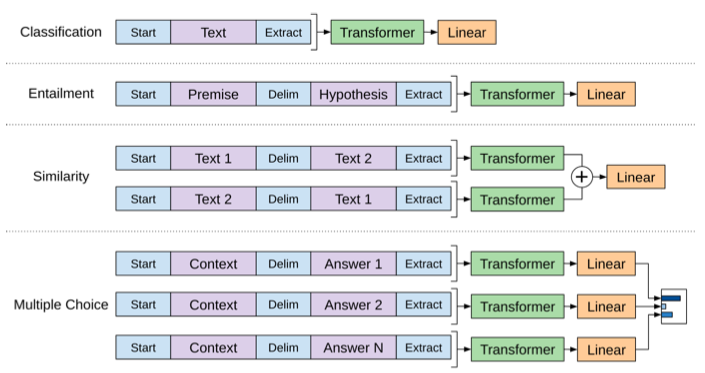


[GPT task(출처:https://s3-us-west-2.amazonaws.com/openai-assets/research-covers/language-unsupervised/language_understanding_paper.pdf)]

**Q. 모델이 한 개인데 어떻게 classification, entailment 등등 다양한 문제를 풀 수 있을까요?**

A. [ pretrain시에는 문장(단어의 시퀀스들)을 그대로 input을 줍니다. finetuning 시에도 똑같이 단어의 시퀀스들을 주면 되는데요 이때, input을 아주 조금만 변형시켜 주면 됩니다.]

<details>
<summary>💡예시답안 확인하기💡</summary>

눈치 채실 분들은 아셨겠지만(답은 좌측 상단에 있어요) 바로 `input`을 변형시켜서 입니다. GPT는 언어 모델이기 때문에 pretrain시에는 문장(단어의 시퀀스들)을 그대로 input을 줍니다. finetuning 시에도 똑같이 단어의 시퀀스들을 주면 되는데요 이때, input을 아주 조금만 변형시켜 주면 됩니다.

예를 들어 classification task를 풀기 위해 finetuning을 하게 된다면 `<start> <input text> <extract> <class>` 이렇게 구성된 데이터셋을 학습시키면 되는 것이죠. GPT는 이 데이터셋에 맞추어서 weight들을 조정하게 될 것입니다.

finetuning이 끝나고 테스트 시에는 `<start> <input text> <extract>`을 input으로 주면 해당 시퀀스에 뒤이어 나올 토큰 즉 `<class>`를 생성하게 되는 것이죠.

GPT vs. GPT2
---
원리는 똑같아요. GPT의 모델 구조를 그대로 사용하면서 파라미터 사이즈를 10배 정도 키우고 성능을 개선시킨 모델이 바로 GPT2입니다.

성능 개선을 위해서 쓴 테크닉들은 자세히는 다루지 않겠습니다. 넌지시 언급만 해보자면, 이전보다 더욱 정제된 데이터셋을 더욱 많이 사용해서 학습시킨 것과 토크나이저를 더 강력하게 만든 것 등등이 있습니다.

자세한 부분은 논문을 읽어보시는 것을 추천해드립니다!

  - [GPT](https://s3-us-west-2.amazonaws.com/openai-assets/research-covers/language-unsupervised/language_understanding_paper.pdf)
  - [GPT-2](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf)

쉬는 시간을 잠시 가져볼까요?

  - [AllenNLP - Demo](https://allenai.org/allennlp)

학습이 완료된 GPT를 이용해 볼 수 있는 사이트입니다. 원하는 대로 글을 적으면 다음 시퀀스를 만들어주는데요! GPT가 확률을 계산해서 확률이 높은 k 개의 단어를 생성하는 것을 볼 수 있습니다. 생각보다 그럴싸한 말들을 만들어 냅니다.

GPT3
---
2020년 6월 GPT3가 공개되었습니다. GPT1의 1000배, GPT2의 100 배 이상의 파라미터를 갖췄고, 성능도 크게 향상되었습니다. GPT3가 할 수 있는 작업에는 언어 관련 문제 풀이, 랜덤 글짓기, 간단한 사칙 연산, 번역, 간단한 웹 코딩, 문장 교정 등이 있었습니다.

GPT3 모델은 GPT2와 같은 구조를 가졌지만 모델과 데이터의 크기를 늘리고, 학습 시간을 늘렸습니다. 또한 modified initialization, pre-normalization, reversable tokenization을 적용하고, 트랜스포머 레이어의 attention 패턴에 대해 dense와 locally banded sparse attention을 번갈아 사용했죠.

하지만 GPT를 개발한 OPEN AI는 GPT3 모델을 오픈 소스로 공개하는 것을 꺼려왔는데요, 그 이유는 GPT3의 성능이 너무 뛰어나서 악용될 수 있다는 우려 때문이었죠. 하지만 GPT3를 이용한 API를 [클로즈 베타](https://beta.openai.com/)로 공개했습니다. 그 후 많은 사람들이 GPT3 API를 이용해 검색 엔진을 만들기, 이력서 작성하기, 간단한 프로그래밍하기, 블로그 글쓰기 등의 다양한 실험을 하였습니다. 어떤 실험을 했는지 궁금하다면 이 [블로그](https://uipath.tistory.com/44)를 읽어보세요. [Philosopher AI](https://philosopherai.com/)를 통해서도 직접 다양한 문장을 만들어 볼 수 있습니다.

뿐만 아니라 GPT3를 이용한 [AI Dungeon](https://play.aidungeon.com/)이라는 게임도 나왔습니다. 플레이어가 행동, 상황, 대사 등을 입력하면 게임 마스터인 AI가 입력된 것에 맞춰 각기 다른 상황을 풀어가게 됩니다. 하지만 AI Dungeon은 OPEN AI가 우려했던 것처럼 일부 사람들에 의해 악용되기도 하였습니다.

GPT3에 대한 자세한 내용은 아래의 논문을 참고해 보세요.

  - [GPT3](https://arxiv.org/pdf/2005.14165)

GPT Neo
---
GPT3를 복제한 GPT-Neo라는 모델이 EleutherAI라는 비영리 오픈 소스 연구 단체에서 오픈 소스로 공개되었습니다. 모델 뿐 아니라 대규모 데이터과 사전학습된 모델도 공개되었죠. 최근에는 60억 개의 파라미터를 가진 [GPT-J-6B](https://6b.eleuther.ai/)를 공개하기도 하였습니다. GPT3보다 작은 파라미터를 가지고 있지만 GPT3와 유사한 수준의 파라미터 수를 갖는 모델인 GPT-NeoX을 만들고 있다고 하니 기대해 보아도 좋을 것 같습니다.

  - [GPT-Neo](https://)
  - GPT-J-6B
  - GPT-NeoX

# BERT(Bidirectional Encoder Representations from Transformers)

대망의 BERT입니다.

2018년 돌연 혜성처럼 나타나 NLP계를 점령했던 BERT, 성능도 성능이지만 이후로도 많은 연구들에 영감을 주었던 모델입니다.

ELMo에 이어 BERT까지 새서미 스트리트라는 캐릭터 이름들을 따는 센스까지 ㅎㅎ

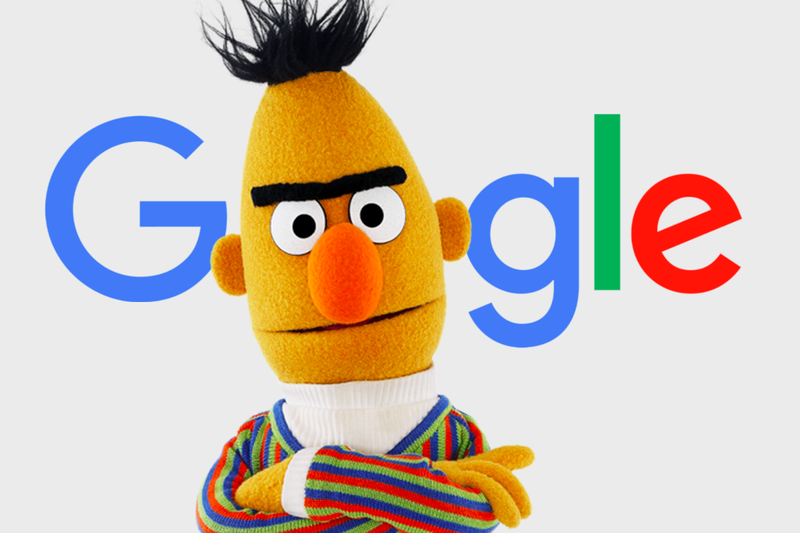

[새서미 스트리트의 캐릭터 BERT (출처 : https://www.effektiv.com/wp-content/uploads/freshizer/22d0859e46b8edf659638449e258a224_Bert-google-algorithmus2-1024-683-c.png)]

BERT에 대해 자세히 알아보기 전에 이전까지 배웠던 ELMo, GPT와 비교해 보는 시간을 마련했습니다.

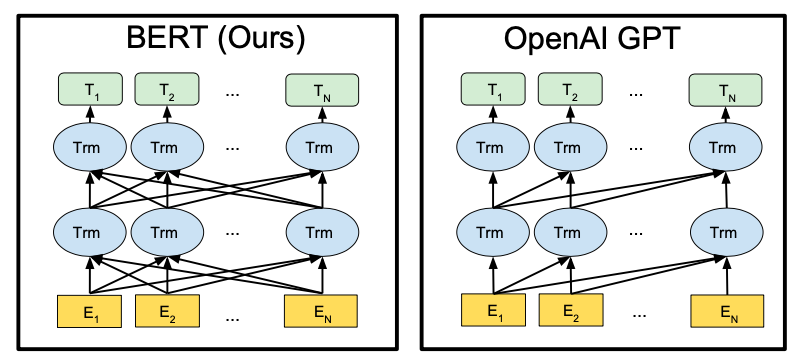

[BERT(좌)와 GPT(우)의 구조 (출처 : https://arxiv.org/pdf/1810.04805.pdf)]

먼저 GPT와 비교해 보겠습니다.

트랜스포머의 decoder를 이용하여 만든 모델인 만큼 GPT는 input을 한 방향으로만(uni-direction) 보게 됩니다. 다음 단어를 예측해야만 하는 LM의 특징이었죠.

이와는 다르게 BERT는 양방향(bi-direction)으로 input을 보고 있는 것을 확인할 수 있습니다. (사실 BERT의 B는 Bi-direction을 의미하고 있습니다.)

그림에서는 보이지 않지만 또 다른 큰 차이점이 존재합니다. BERT는 트랜스포머의 encoder만을 사용한 모델입니다.

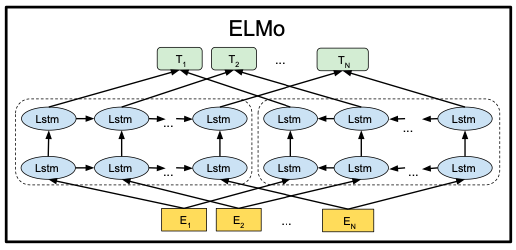

[ELMo의 구조 (출처 : https://arxiv.org/pdf/1810.04805.pdf)]

다음은 ELMo와의 비교입니다.

ELMo가 bidirection LSTM을 사용하긴 했지만 독립적인 모델처럼 학습하고 마지막 layer에서만 합쳐준다는 것을 잊지 않으셨죠?!
따라서 ELMo는 가장 위에 layer만 양방향 정보를 가지고 있습니다. 이는 모든 layer들이 양방향으로 보는 BERT와 가장 큰 차이점이라고 할 수 있죠.

BERT는 이처럼 진짜 bi-direction이 뭔지 보여주기 위해 만들어진 모델이랍니다. 이제 BERT의 핵심 아이디어를 알았으니 더 자세하게 알아볼까요?

## 1. BERT의 구조
---
앞서 말했듯이 BERT는 트랜스포머의 encoder 구조를 이용한 모델입니다. 이제부터는 트랜스포머와의 차이점을 위주로 이야기해 보겠습니다.

**1. Transformer Encoder Block**

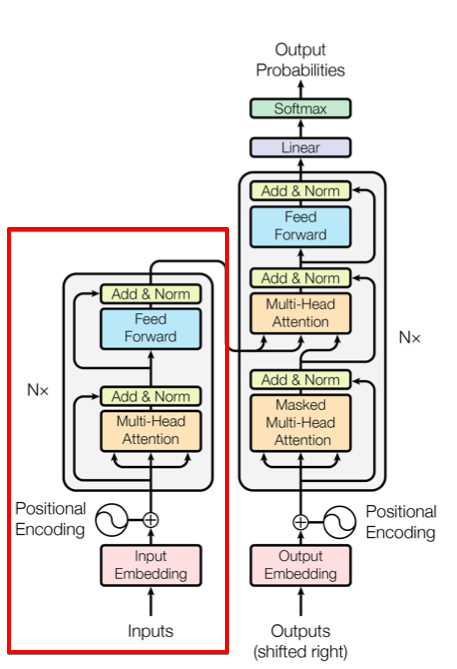

[Transformer의 모델 구조(출처:https://arxiv.org/pdf/1706.03762.pdf)]

**1) Embedding(임베딩)**

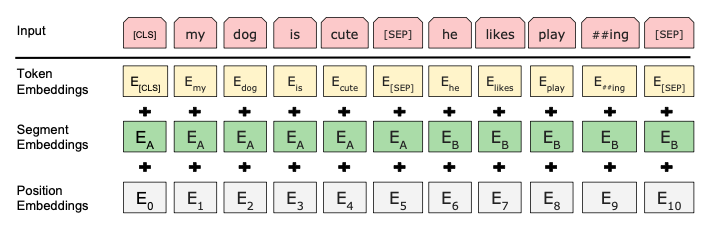

[BERT의 Positional Embedding (https://arxiv.org/abs/1810.04805)]

BERT는 기존의 트랜스포머와는 유사하지만 다른 임베딩 체계를 가지고 있습니다. 세 가지 임베딩을 가지고 있는데요. 하나하나 살펴보겠습니다.

  - **Token Embedding**  
  우선 Wordpiece을 이용하여 3만 개의 vocabulary를 학습합니다. 학습한 Wordpiece model을 이용하여 token들을 임베딩해줍니다.

  - **Segment Embedding**  
  BERT는 두 가지 sentence(BERT의 논문에서 나오는 sentence는 문장의 의미보다는 텍스트 덩어리의 의미입니다.)를 입력으로 받기 때문에 이 두 가지 sentence를 구분해야 할 필요가 있습니다. segment embedding은 바로 이를 위해서 존재하는데요. 모델 입장에서 주르륵 이어진 텍스트들의 덩어리를 나누어주는 역할을 합니다. 그림에서도 `[SEP]`토큰으로 구분된 두 sentence에서 앞부분은 A, 뒷부분은 B로 나누어 임베딩하는 것을 확인하실 수 있습니다.

  - **Position Embedding**  
  마지막으로 position embedding입니다. 두 sentence를 나누는 것은 segment embedding에서 해주지만, sentence 안에서의 순서는 아직 모르는 상태입니다. 따라서 문장 내에 절대적인 위치(순서)를 알려주기 위해 필요한 것이 position embedding입니다.

여기서 잠깐!

**Q. Positional encoding과 position embedding 어떤 말이 맞는 것일까요? 트랜스포머와 GPT에서는 positional encoding이라고 했는데... 똑같은 것 아닐까요?**

A. embedding은 그 값이 정해진 것이 아니라 학습을 통해 습득하는 것을 의미합니다.

다시 말해서, BERT는 학습을 통해 position 정보를 습득한다]

<details>
<summary>💡예시답안 확인하기💡</summary>

정답은 NO!

혼용하여 사용하긴 하지만 엄밀하게 말하면 다른 개념입니다. encoding은 one-hot-encoding(원핫 인코딩)처럼 미리 정해진 값을 주는 것이지만 embedding은 그 값이 정해진 것이 아니라 학습을 통해 습득하는 것을 의미합니다.

다시 말해서, BERT는 학습을 통해 position 정보를 습득한다고 생각하시면 됩니다.

**Q. Positional encoding과 position embedding 어떤 말이 맞는 것일까요? 트랜스포머와 GPT에서는 positional encoding이라고 했는데... 똑같은 것 아닐까요?**

A. [ 답변을 적어볼까요! ]

<details>
<summary>💡예시답안 확인하기💡</summary>

정답은 NO!

혼용하여 사용하긴 하지만 엄밀하게 말하면 다른 개념입니다. encoding은 one-hot-encoding(원핫 인코딩)처럼 미리 정해진 값을 주는 것이지만 embedding은 그 값이 정해진 것이 아니라 학습을 통해 습득하는 것을 의미합니다.

다시 말해서, BERT는 학습을 통해 position 정보를 습득한다고 생각하시면 됩니다.

이렇게 얻은 세 가지 임베딩을 모두 합산해 주면 BERT의 임베딩이 완성됩니다. 이후 layer normalization과 dropout까지 해주면 트랜스포머 첫 블록의 입력이 완성됩니다.

`[SEP]`토큰은 위에서 아주 넌-지시 말하고 넘어갔죠. 이것들은 special token이라고 해서 실제 단어에는 쓰이지 않지만 특별한 역할들을 가지고 있는 아이들이에요. sequence-to-sequence 모델에서도 슬-쩍 본 적이 있으실 거예요! 문장의 시작과 끝을 알려주기 위해 쓰였던 `<BOS>`,`<EOS>` 같은 토큰들 말이에요!

그럼 BERT에는 어떤 토큰들이 어떻게 쓰였나 알아보고 가실까요?

  - `[CLS]` : sentence의 시작을 알리는 토큰
  - `[SEP]` : sentence의 종결을 알리는 토큰, sentence를 구분하는 데에 사용하기도 함
  - `[MASK]`: 마스크 토큰
  - `[PAD]` : 배치 데이터의 길이를 맞춰주기 위한 토큰


**2. Activation Function(활성화 함수) : GELU**

Feedforward Networks에서 BERT는 ReLU대신 GELU를 사용합니다. 음수 값은 0이 되어버리는 ReLU와는 달리 GELU는 음수에서도 완만한 곡선을 그리며 미분을 가능하게 합니다. GELU를 사용하면 성능이 더욱 좋아지기 때문에 BERT의 저자들은 GELU를 사용했다고 합니다.

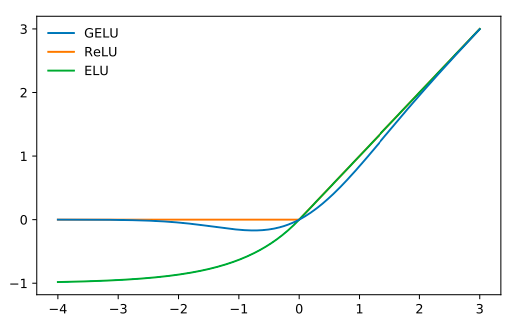

[activation function의 비교 (출처 : https://arxiv.org/abs/1606.08415)]

## 2. BERT의 학습
---
BERT는 양방향(Bi-direction)을 강조한 모델입니다. BERT는 그럼 어떻게 학습을 하는 것일까요? 두 가지 핵심 아이디어를 들여다보죠.

**1) Masked LM(MLM)**

다음 단어를 예측해야만 하는 일반적인 LM은 그 task의 특성상 한 방향(uni-direction)일 수밖에 없습니다. 이와 달리, BERT는 마스크 된 토큰(`[MASK`)만 맞추면 되는 masked LM(MLM)을 제안했습니다. 즉, input sequence의 순서에 상관없이 전체 문장을 모두 볼 수 있게 되는 거죠.

(word2vec의 CBOW와 비슷한 아이디어처럼 보이죠?)

MLM을 위해서 BERT는 학습 데이터의 전체에서 15% 를 `[MASK]` 토큰으로 랜덤하게 바꿉니다. 여기서 재미있게도 15%에 해당하는 모든 토큰들을 마스크하는 것이 아니라 80%는 `[MASK]`토큰, 10%는 무작위로 랜덤한 토큰으로 바꿔줍니다. 나머지 10%는 원래의 토큰을 그대로 사용하구요.

그 이유는 바로 finetuning에 있는데요. pretrain을 끝낸 모델을 finetuning할 때에는 input에 `[MASK]`토큰이 등장하지 않기 때문입니다. 아무래도 finetuning시에 `[MASK]`토큰이 보이지 않는다면, 당연히 성능에 영향을 미치게 될 것이라고 생각한 거죠. 따라서, `[MASK]`토큰이 아닌 것들도 예측을 하도록 학습하여 문장 자체에 대한 전반적인 이해(문맥에 대한 이해)를 할 수 있도록 해주는 겁니다.

다시 정리하자면, 전체 학습 데이터의 토큰들 중 12%(15% 중에서 80%)는 `[MASK]`토큰으로, 1.5%(15% 중에서 10%)는 무작위로 랜덤한 토큰으로 대체하고, 1.5%((15% 중에서 10%)는 변경하지 않고 원래의 토큰을 사용하는 겁니다.

**2) Next Sentence Prediction (NSP)**

BERT는 마스크 된 토큰을 맞추는 것과 동시에 또 다른 task를 함께 학습합니다. 바로 Next Sentence Prediction (NSP), 다음 문장인지 확인하기 입니다.

예시를 한 번 들어볼까요?

>여름의 마지막 해수욕 누가 제일 늦게 바다에서 나왔나

>그 사람이 바다의 뚜껑 닫지 않고 돌아가

>그때부터 바다의 뚜껑 열린 채 그대로 있네

>-하라 마스미 「바다의 뚜껑」 중

제가 좋아하는 시인데요. 한 행을 하나의 sentence라고 가정해 봅시다.

그렇다면 '여름의 마지막 해수욕 누가 제일 늦게 바다에서 나왔나' 다음의 sentence는 '그 사람이 바다의 뚜껑 닫지 않고 돌아가'가 될 것입니다.

BERT는 이처럼 두 sentence가 연속해서 오는지의 여부를 학습하게 됩니다. 바로 아래와 같이 말이죠.

`[CLS]`여름의 마지막 해수욕 누가 제일 늦게 바다에서 나왔나 `[SEP]` 그 사람이 바다의 뚜껑 닫지 않고 돌아가`[SEP]` → TRUE(IsNext)

`[CLS]`여름의 마지막 해수욕 누가 제일 늦게 바다에서 나왔나 `[SEP]` 한강에서 자전거 타며 아이스 아메리카노를 마시고 싶다`[SEP]` → FALSE(NotNext)

NSP를 위해서 BERT의 학습 데이터는 1건당 두 개의 문장으로 구성합니다. 50%의 확률로 TRUE와 FALSE를 부여하도록 만들죠.

또한, task가 너무 쉬워지는 것을 방지하기 위해 max_num_tokens라는 것을 정의합니다. 데이터의 90%는 max_num_tokens가 max_sequence_length가 같도록 만들고, 나머지 10%의 데이터는 max_num_tokens가 max_sequence_length보다 짧게 되도록 랜덤으로 정합니다.

이후, 두 개의 sentence의 단어 총수가 max_num_tokens보다 작아질 때까지 두 sentence 중 단어 수가 많은 쪽의 문장 맨 앞 또는 맨 뒤 단어를 하나씩 제거합니다. 이때 문장 맨 앞의 단어를 선택할지 맨 뒤의 단어의 선택할지는 50%의 확률로 정합니다.

이렇게 NSP를 학습하게 되면, 문장과 문장 사이의 관계를 학습할 수 있게 됩니다. 문장의 길이를 임의적으로 조정하면서, 짧은 문장에 대해서도 성능이 크게 떨어지지 않게 되며, 문장의 단어들을 랜덤하게 삭제하는 과정에서 문장에서 일부 단어들이 없어져도 그 영향을 크게 받지 않게 됩니다.

지금까지 보신 MLM과 NSP는 따로 학습되는 것이 아니라 동시에 이뤄집니다. 따라서 실제 BERT의 학습 데이터셋은 아래와 같은 구조일 것입니다.(편의상 토큰을 띄어쓰기 단위로 나누겠습니다)

`[CLS]`여름의 마지막 `[MASK]` 누가 제일 늦게 `[MASK]` 나왔나 `[SEP]` 그 사람이 바다의 `[MASK]` 닫지 않고 돌아가`[SEP]` → Label : TRUE(IsNext)

`[CLS]`여름의 `[MASK]` 해수욕 누가 제일 늦게 바다에서 나왔나 `[SEP]` 한강에서 `[MASK]` 아이스 아메리카노를 마시고 싶다`[SEP]` → Label : FALSE(NotNext)

## 3. Fine-tuning Task
---
BERT의 finetuning은 그럼 어떻게 진행할까요?

BERT 또한 한 모델이 다양한 task들을 수행하기 때문에 input transformation을 이용합니다.

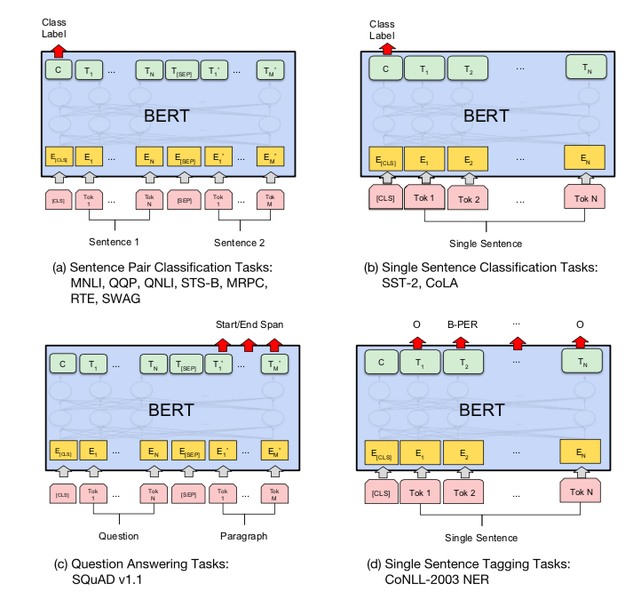

[BERT의 finetuning (출처 : https://arxiv.org/pdf/1810.04805.pdf)]

classification 같은 경우는 `[CLS]`토큰을, QA와 같이 문장이나 단어들이 나와야 하는 경우에는 토큰들의 벡터를 output layer에 넣어 output을 산출해냅니다.

## 4. BERT의 모델 코드
---
Transformer, GPT와 다른 부분을 유심히 보면서 모델을 훑어본다면 더욱 도움이 될 거예요! 메인 모델 구조인 `TFBertEncoder` 안에 반복적으로 사용되고 있는 `TFBertLayer` 레이어 구성을 자세히 살펴주세요. 전체 구조를 한눈에 보기에는 복잡하게 느껴지시더라도, 다음 노드에서 단계별로 차례차례 구현해 보면서 좀 더 명확하게 이해하실 수 있으실 겁니다.


# <details>
<summary>코드보기</summary>
<div markdown="1">



```
class TFBertPreTrainingLoss:
    """
    BERT의 경우 Pretraining으로 NSP + MLM 두 가지를 함께 학습하게 됨. 그것을 위한 loss
		-100으로 label(logit)이 되어있는 경우 loss 계산 시 제외
    """

    def compute_loss(self, labels, logits):
        loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(
            from_logits=True, reduction=tf.keras.losses.Reduction.NONE
        )

        masked_lm_active_loss = tf.not_equal(tf.reshape(labels["labels"], (-1,)), -100)
        masked_lm_reduced_logits = tf.boolean_mask(
            tf.reshape(logits[0], (-1, shape_list(logits[0])[2])),
            masked_lm_active_loss,
        )
        masked_lm_labels = tf.boolean_mask(tf.reshape(labels["labels"], (-1,)), masked_lm_active_loss)
        next_sentence_active_loss = tf.not_equal(tf.reshape(labels["next_sentence_label"], (-1,)), -100)
        next_sentence_reduced_logits = tf.boolean_mask(tf.reshape(logits[1], (-1, 2)), next_sentence_active_loss)
        next_sentence_label = tf.boolean_mask(
            tf.reshape(labels["next_sentence_label"], (-1,)), mask=next_sentence_active_loss
        )
        masked_lm_loss = loss_fn(masked_lm_labels, masked_lm_reduced_logits)
        next_sentence_loss = loss_fn(next_sentence_label, next_sentence_reduced_logits)
        masked_lm_loss = tf.reshape(masked_lm_loss, (-1, shape_list(next_sentence_loss)[0]))
        masked_lm_loss = tf.reduce_mean(masked_lm_loss, 0)

        return masked_lm_loss + next_sentence_loss


class TFBertEmbeddings(tf.keras.layers.Layer):
    """
		1-1)에 해당하는 부분으로 3가지 embedding을 만들고 그 embedding을 모두 합산하여 layer normalize와 dropout을 적용
		"""


    def __init__(self, config, **kwargs):
        super().__init__(**kwargs)

        self.vocab_size = config.vocab_size
        self.hidden_size = config.hidden_size
        self.initializer_range = config.initializer_range
        self.position_embeddings = tf.keras.layers.Embedding(
            config.max_position_embeddings,
            config.hidden_size,
            embeddings_initializer=get_initializer(self.initializer_range),
            name="position_embeddings",
        )
        self.token_type_embeddings = tf.keras.layers.Embedding(
            config.type_vocab_size,
            config.hidden_size,
            embeddings_initializer=get_initializer(self.initializer_range),
            name="token_type_embeddings",
        )

        self.LayerNorm = tf.keras.layers.LayerNormalization(epsilon=config.layer_norm_eps, name="LayerNorm")
        self.dropout = tf.keras.layers.Dropout(config.hidden_dropout_prob)

    def build(self, input_shape):
        """shared word embedding layer """
        with tf.name_scope("word_embeddings"):
            # Create and initialize weights. The random normal initializer was chosen
            # arbitrarily, and works well.
            self.word_embeddings = self.add_weight(
                "weight",
                shape=[self.vocab_size, self.hidden_size],
                initializer=get_initializer(self.initializer_range),
            )

        super().build(input_shape)

    def call(
        self,
        input_ids=None,
        position_ids=None,
        token_type_ids=None,
        inputs_embeds=None,
        mode="embedding",
        training=False,
    ):
        """
        input의 token embeddings
        Args:
            inputs: int64 tensors (shape [batch_size, length]) 3개를 담은 리스트: (input_ids, position_ids, token_type_ids)
            mode: "embedding" | "linear"
        Returns:
            outputs: mode == "embedding"; output embedding tensor(float32, shape [batch_size, length, embedding_size])
										 mode == "linear", output linear tensor(float32, shape [batch_size, length, vocab_size])
        Raises:
            ValueError: if mode is not valid.
				"""

        if mode == "embedding":
            return self._embedding(input_ids, position_ids, token_type_ids, inputs_embeds, training=training)
        elif mode == "linear":
            return self._linear(input_ids)
        else:
            raise ValueError("mode {} is not valid.".format(mode))

    def _embedding(self, input_ids, position_ids, token_type_ids, inputs_embeds, training=False):
        """input tensor에 기반하여 임베딩 적용"""
        assert not (input_ids is None and inputs_embeds is None)

        if input_ids is not None:
            input_shape = shape_list(input_ids)
        else:
            input_shape = shape_list(inputs_embeds)[:-1]

        seq_length = input_shape[1]

        if position_ids is None:
            position_ids = tf.range(seq_length, dtype=tf.int32)[tf.newaxis, :]

        if token_type_ids is None:
            token_type_ids = tf.fill(input_shape, 0)

        if inputs_embeds is None:
            inputs_embeds = tf.gather(self.word_embeddings, input_ids)

        position_embeddings = tf.cast(self.position_embeddings(position_ids), inputs_embeds.dtype)
        token_type_embeddings = tf.cast(self.token_type_embeddings(token_type_ids), inputs_embeds.dtype)
        embeddings = inputs_embeds + position_embeddings + token_type_embeddings
        embeddings = self.LayerNorm(embeddings)
        embeddings = self.dropout(embeddings, training=training)

        return embeddings

    def _linear(self, inputs):
        """
 			  linear layer를 통해서 input의 logit을 계산
        Args:
            inputs: float32 tensor (shape [batch_size, length, hidden_size])
        Returns:
            float32 tensor (shape [batch_size, length, vocab_size])
        """
        batch_size = shape_list(inputs)[0]
        length = shape_list(inputs)[1]
        x = tf.reshape(inputs, [-1, self.hidden_size])
        logits = tf.matmul(x, self.word_embeddings, transpose_b=True)

        return tf.reshape(logits, [batch_size, length, self.vocab_size])


class TFBertSelfAttention(tf.keras.layers.Layer):
    def __init__(self, config, **kwargs):
        super().__init__(**kwargs)

        if config.hidden_size % config.num_attention_heads != 0:
            raise ValueError(
                "The hidden size (%d) is not a multiple of the number of attention "
                "heads (%d)" % (config.hidden_size, config.num_attention_heads)
            )

        self.num_attention_heads = config.num_attention_heads
        assert config.hidden_size % config.num_attention_heads == 0
        self.attention_head_size = int(config.hidden_size / config.num_attention_heads)
        self.all_head_size = self.num_attention_heads * self.attention_head_size
        self.query = tf.keras.layers.Dense(
            self.all_head_size, kernel_initializer=get_initializer(config.initializer_range), name="query"
        )
        self.key = tf.keras.layers.Dense(
            self.all_head_size, kernel_initializer=get_initializer(config.initializer_range), name="key"
        )
        self.value = tf.keras.layers.Dense(
            self.all_head_size, kernel_initializer=get_initializer(config.initializer_range), name="value"
        )
        self.dropout = tf.keras.layers.Dropout(config.attention_probs_dropout_prob)

    def transpose_for_scores(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_attention_heads, self.attention_head_size))

        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, hidden_states, attention_mask, head_mask, output_attentions, training=False):
        batch_size = shape_list(hidden_states)[0]
        mixed_query_layer = self.query(hidden_states)
        mixed_key_layer = self.key(hidden_states)
        mixed_value_layer = self.value(hidden_states)
        query_layer = self.transpose_for_scores(mixed_query_layer, batch_size)
        key_layer = self.transpose_for_scores(mixed_key_layer, batch_size)
        value_layer = self.transpose_for_scores(mixed_value_layer, batch_size)

        # "query"와 "key"의 dot product : raw attention scores
        attention_scores = tf.matmul(
            query_layer, key_layer, transpose_b=True
        )  # (batch size, num_heads, seq_len_q, seq_len_k)
        dk = tf.cast(shape_list(key_layer)[-1], attention_scores.dtype)  # scale attention_scores
        attention_scores = attention_scores / tf.math.sqrt(dk)

        if attention_mask is not None:
            attention_scores = attention_scores + attention_mask

        # Normalize the attention scores to probabilities.
        attention_probs = tf.nn.softmax(attention_scores, axis=-1)

        attention_probs = self.dropout(attention_probs, training=training)

        if head_mask is not None:
            attention_probs = attention_probs * head_mask

        context_layer = tf.matmul(attention_probs, value_layer)
        context_layer = tf.transpose(context_layer, perm=[0, 2, 1, 3])
        context_layer = tf.reshape(
            context_layer, (batch_size, -1, self.all_head_size)
        )  # (batch_size, seq_len_q, all_head_size)
        outputs = (context_layer, attention_probs) if output_attentions else (context_layer,)

        return outputs


class TFBertSelfOutput(tf.keras.layers.Layer):
    def __init__(self, config, **kwargs):
        super().__init__(**kwargs)

        self.dense = tf.keras.layers.Dense(
            config.hidden_size, kernel_initializer=get_initializer(config.initializer_range), name="dense"
        )
        self.LayerNorm = tf.keras.layers.LayerNormalization(epsilon=config.layer_norm_eps, name="LayerNorm")
        self.dropout = tf.keras.layers.Dropout(config.hidden_dropout_prob)

    def call(self, hidden_states, input_tensor, training=False):
        hidden_states = self.dense(hidden_states)
        hidden_states = self.dropout(hidden_states, training=training)
        hidden_states = self.LayerNorm(hidden_states + input_tensor)

        return hidden_states


class TFBertAttention(tf.keras.layers.Layer):
    def __init__(self, config, **kwargs):
        super().__init__(**kwargs)

        self.self_attention = TFBertSelfAttention(config, name="self")
        self.dense_output = TFBertSelfOutput(config, name="output")

    def prune_heads(self, heads):
        raise NotImplementedError

    def call(self, input_tensor, attention_mask, head_mask, output_attentions, training=False):
        self_outputs = self.self_attention(
            input_tensor, attention_mask, head_mask, output_attentions, training=training
        )
        attention_output = self.dense_output(self_outputs[0], input_tensor, training=training)
        outputs = (attention_output,) + self_outputs[1:]  # add attentions if we output them

        return outputs


class TFBertIntermediate(tf.keras.layers.Layer):
"""
Transformer Block에서의 feedforward
"""
    def __init__(self, config, **kwargs):
        super().__init__(**kwargs)

        self.dense = tf.keras.layers.Dense(
            config.intermediate_size, kernel_initializer=get_initializer(config.initializer_range), name="dense"
        )

        if isinstance(config.hidden_act, str):
            self.intermediate_act_fn = get_tf_activation(config.hidden_act)
        else:
            self.intermediate_act_fn = config.hidden_act

    def call(self, hidden_states):
        hidden_states = self.dense(hidden_states)
        hidden_states = self.intermediate_act_fn(hidden_states)

        return hidden_states


class TFBertOutput(tf.keras.layers.Layer):
    def __init__(self, config, **kwargs):
        super().__init__(**kwargs)

        self.dense = tf.keras.layers.Dense(
            config.hidden_size, kernel_initializer=get_initializer(config.initializer_range), name="dense"
        )
        self.LayerNorm = tf.keras.layers.LayerNormalization(epsilon=config.layer_norm_eps, name="LayerNorm")
        self.dropout = tf.keras.layers.Dropout(config.hidden_dropout_prob)

    def call(self, hidden_states, input_tensor, training=False):
        hidden_states = self.dense(hidden_states)
        hidden_states = self.dropout(hidden_states, training=training)
        hidden_states = self.LayerNorm(hidden_states + input_tensor)

        return hidden_states


class TFBertLayer(tf.keras.layers.Layer):
"""
Transformer Encoder Block과 동일한 구조 : Attention,Feedforward,dropout,layer nomalization
"""
    def __init__(self, config, **kwargs):
        super().__init__(**kwargs)

        self.attention = TFBertAttention(config, name="attention")
        self.intermediate = TFBertIntermediate(config, name="intermediate")
        self.bert_output = TFBertOutput(config, name="output")

    def call(self, hidden_states, attention_mask, head_mask, output_attentions, training=False):
        attention_outputs = self.attention(
            hidden_states, attention_mask, head_mask, output_attentions, training=training
        )
        attention_output = attention_outputs[0]
        intermediate_output = self.intermediate(attention_output)
        layer_output = self.bert_output(intermediate_output, attention_output, training=training)
        outputs = (layer_output,) + attention_outputs[1:]  # add attentions if we output them

        return outputs


class TFBertEncoder(tf.keras.layers.Layer):
"""
Transformer Encoder Block(코드 상에서 TFBertLayer)를 n_layer만큼 여러개 쌓은 구조
"""
    def __init__(self, config, **kwargs):
        super().__init__(**kwargs)

        self.layer = [TFBertLayer(config, name="layer_._{}".format(i)) for i in range(config.num_hidden_layers)]

    def call(
        self,
        hidden_states,
        attention_mask,
        head_mask,
        output_attentions,
        output_hidden_states,
        return_dict,
        training=False,
    ):
        all_hidden_states = () if output_hidden_states else None
        all_attentions = () if output_attentions else None

        for i, layer_module in enumerate(self.layer):
            if output_hidden_states:
                all_hidden_states = all_hidden_states + (hidden_states,)

            layer_outputs = layer_module(
                hidden_states, attention_mask, head_mask[i], output_attentions, training=training
            )
            hidden_states = layer_outputs[0]

            if output_attentions:
                all_attentions = all_attentions + (layer_outputs[1],)

        # Add last layer
        if output_hidden_states:
            all_hidden_states = all_hidden_states + (hidden_states,)

        if not return_dict:
            return tuple(v for v in [hidden_states, all_hidden_states, all_attentions] if v is not None)

        return TFBaseModelOutput(
            last_hidden_state=hidden_states, hidden_states=all_hidden_states, attentions=all_attentions
        )


class TFBertPooler(tf.keras.layers.Layer):
    def __init__(self, config, **kwargs):
        super().__init__(**kwargs)

        self.dense = tf.keras.layers.Dense(
            config.hidden_size,
            kernel_initializer=get_initializer(config.initializer_range),
            activation="tanh",
            name="dense",
        )

    def call(self, hidden_states):
        # 첫 번째 토큰의 hidden state를 얻기 위해 pool
        first_token_tensor = hidden_states[:, 0]
        pooled_output = self.dense(first_token_tensor)

        return pooled_output


class TFBertPredictionHeadTransform(tf.keras.layers.Layer):
    def __init__(self, config, **kwargs):
        super().__init__(**kwargs)

        self.dense = tf.keras.layers.Dense(
            config.hidden_size, kernel_initializer=get_initializer(config.initializer_range), name="dense"
        )

        if isinstance(config.hidden_act, str):
            self.transform_act_fn = get_tf_activation(config.hidden_act)
        else:
            self.transform_act_fn = config.hidden_act

        self.LayerNorm = tf.keras.layers.LayerNormalization(epsilon=config.layer_norm_eps, name="LayerNorm")

    def call(self, hidden_states):
        hidden_states = self.dense(hidden_states)
        hidden_states = self.transform_act_fn(hidden_states)
        hidden_states = self.LayerNorm(hidden_states)

        return hidden_states


class TFBertLMPredictionHead(tf.keras.layers.Layer):
    def __init__(self, config, input_embeddings, **kwargs):
        super().__init__(**kwargs)

        self.vocab_size = config.vocab_size
        self.transform = TFBertPredictionHeadTransform(config, name="transform")

        # input embeddings과 동일한 weight를 가지고 있지만 각각의 token에 대하여 output만 바이어스를 가지고 있음
        self.input_embeddings = input_embeddings

    def build(self, input_shape):
        self.bias = self.add_weight(shape=(self.vocab_size,), initializer="zeros", trainable=True, name="bias")

        super().build(input_shape)

    def call(self, hidden_states):
        hidden_states = self.transform(hidden_states)
        hidden_states = self.input_embeddings(hidden_states, mode="linear")
        hidden_states = hidden_states + self.bias

        return hidden_states


class TFBertMLMHead(tf.keras.layers.Layer):
"""
2-1)Masked LM을 위한 class
"""
    def __init__(self, config, input_embeddings, **kwargs):
        super().__init__(**kwargs)

        self.predictions = TFBertLMPredictionHead(config, input_embeddings, name="predictions")

    def call(self, sequence_output):
        prediction_scores = self.predictions(sequence_output)

        return prediction_scores


class TFBertNSPHead(tf.keras.layers.Layer):
"""
2-2)NSP를 위한 class
"""
    def __init__(self, config, **kwargs):
        super().__init__(**kwargs)

        self.seq_relationship = tf.keras.layers.Dense(
            2, kernel_initializer=get_initializer(config.initializer_range), name="seq_relationship"
        )

    def call(self, pooled_output):
        seq_relationship_score = self.seq_relationship(pooled_output)

        return seq_relationship_score


@keras_serializable
class TFBertMainLayer(tf.keras.layers.Layer):
"""
모델의 전체 구조
"""
    config_class = BertConfig

    def __init__(self, config, **kwargs):
        super().__init__(**kwargs)

        self.num_hidden_layers = config.num_hidden_layers
        self.initializer_range = config.initializer_range
        self.output_attentions = config.output_attentions
        self.output_hidden_states = config.output_hidden_states
        self.return_dict = config.use_return_dict
        self.embeddings = TFBertEmbeddings(config, name="embeddings")
        self.encoder = TFBertEncoder(config, name="encoder")
        self.pooler = TFBertPooler(config, name="pooler")

    def get_input_embeddings(self):
        return self.embeddings

    def set_input_embeddings(self, value):
        self.embeddings.word_embeddings = value
        self.embeddings.vocab_size = value.shape[0]

    def _prune_heads(self, heads_to_prune):
        """
        heads_to_prune: dict of {layer_num: list of heads to prune in this layer}
        """
        raise NotImplementedError

    def call(
        self,
        inputs,
        attention_mask=None,
        token_type_ids=None,
        position_ids=None,
        head_mask=None,
        inputs_embeds=None,
        output_attentions=None,
        output_hidden_states=None,
        return_dict=None,
        training=False,
    ):
        if isinstance(inputs, (tuple, list)):
            input_ids = inputs[0]
            attention_mask = inputs[1] if len(inputs) > 1 else attention_mask
            token_type_ids = inputs[2] if len(inputs) > 2 else token_type_ids
            position_ids = inputs[3] if len(inputs) > 3 else position_ids
            head_mask = inputs[4] if len(inputs) > 4 else head_mask
            inputs_embeds = inputs[5] if len(inputs) > 5 else inputs_embeds
            output_attentions = inputs[6] if len(inputs) > 6 else output_attentions
            output_hidden_states = inputs[7] if len(inputs) > 7 else output_hidden_states
            return_dict = inputs[8] if len(inputs) > 8 else return_dict
            assert len(inputs) <= 9, "Too many inputs."
        elif isinstance(inputs, (dict, BatchEncoding)):
            input_ids = inputs.get("input_ids")
            attention_mask = inputs.get("attention_mask", attention_mask)
            token_type_ids = inputs.get("token_type_ids", token_type_ids)
            position_ids = inputs.get("position_ids", position_ids)
            head_mask = inputs.get("head_mask", head_mask)
            inputs_embeds = inputs.get("inputs_embeds", inputs_embeds)
            output_attentions = inputs.get("output_attentions", output_attentions)
            output_hidden_states = inputs.get("output_hidden_states", output_hidden_states)
            return_dict = inputs.get("return_dict", return_dict)
            assert len(inputs) <= 9, "Too many inputs."
        else:
            input_ids = inputs

        output_attentions = output_attentions if output_attentions is not None else self.output_attentions
        output_hidden_states = output_hidden_states if output_hidden_states is not None else self.output_hidden_states
        return_dict = return_dict if return_dict is not None else self.return_dict

        if input_ids is not None and inputs_embeds is not None:
            raise ValueError("You cannot specify both input_ids and inputs_embeds at the same time")
        elif input_ids is not None:
            input_shape = shape_list(input_ids)
        elif inputs_embeds is not None:
            input_shape = shape_list(inputs_embeds)[:-1]
        else:
            raise ValueError("You have to specify either input_ids or inputs_embeds")

        if attention_mask is None:
            attention_mask = tf.fill(input_shape, 1)

        if token_type_ids is None:
            token_type_ids = tf.fill(input_shape, 0)

        embedding_output = self.embeddings(input_ids, position_ids, token_type_ids, inputs_embeds, training=training)

				# 3D attention mask 만들기
        # Sizes : [batch_size, 1, 1, to_seq_length]
        # 3D attention mask를 [batch_size, num_heads, from_seq_length, to_seq_length]로 브로드캐스팅

        extended_attention_mask = attention_mask[:, tf.newaxis, tf.newaxis, :]

				# attention_mask가 1.0이면 포함, 0.0이면 미포함 하여 attention 계산
        extended_attention_mask = tf.cast(extended_attention_mask, embedding_output.dtype)
        extended_attention_mask = (1.0 - extended_attention_mask) * -10000.0

        # head_mask가 1.0이면, head를 유지
        # attention_probs : shape bsz x n_heads x N x N
        # input head_mask : shape [num_heads] 또는 [num_hidden_layers x num_heads]
        # head_mask : shape [num_hidden_layers x batch x num_heads x seq_length x seq_length
        if head_mask is not None:
            raise NotImplementedError
        else:
            head_mask = [None] * self.num_hidden_layers
            # head_mask = tf.constant([0] * self.num_hidden_layers)

        encoder_outputs = self.encoder(
            embedding_output,
            extended_attention_mask,
            head_mask,
            output_attentions,
            output_hidden_states,
            return_dict,
            training=training,
        )

        sequence_output = encoder_outputs[0]
        pooled_output = self.pooler(sequence_output)

        if not return_dict:
            return (
                sequence_output,
                pooled_output,
            ) + encoder_outputs[1:]

        return TFBaseModelOutputWithPooling(
            last_hidden_state=sequence_output,
            pooler_output=pooled_output,
            hidden_states=encoder_outputs.hidden_states,
            attentions=encoder_outputs.attentions,
        )
```



</div>
</details>

더 자세히 알아보고 싶다면 BERT의 논문을 직접 읽어보세요!

  - [BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding](https://arxiv.org/abs/1810.04805)
---
ELMo, GPT, BERT까지 멀고도 험한 길을 함께 잘 달려오셨습니다. 잠시 기지개도 펴고, 바람도 쐬며 머리를 환기시키는 시간을 가지고 오세요... 아직도 갈 길이 남았으니깐 조금만 더 으쌰으쌰 해봅시다.

이후의 볼 모델들은 트랜스포머가 베이스인 모델의 한계점을 어떻게 극복해나가는가에 초점이 있습니다. 성능이 잘 나오긴 하지만 사실 GPT, BERT와 같은 모델들은 어마어마한 학습 시간과 컴퓨팅 파워가 있어야 가능한 모델들이랍니다.

# Transformer-XL(Transformer Extra Long)

transformer-XL은 기존의 언어 모델과 트랜스포머가 가지고 있던 한계점을 개선한 모델입니다. 트랜스포머 이전의 LM에서도 늘 한계점으로 꼽히던 **context를 반영하기**가 트랜스포머에서도 문제로 떠오릅니다.
비교적 짧은 문장에서의 context는 잘 학습했는데, sequence가 길어질수록 그 상관관계(long-term dependency)가 점점 떨어진다는 것이 문제였죠. 주제에 대해서 잘 말하다가 갑자기 다른 이야기를 한다던가 하는 문제 말이에요.

transformer-XL은 직관적인 그 이름에서도 드러나듯이 좀 더 긴 context를 어떻게 담을 것인가에 대해 고민한 모델입니다.

어떻게 해서 transformer-XL은 context를 이어나갈까요?

## transformer-XL의 구조
---
transformer-XL을 알아보기에 앞서 트랜스포머를 좀 더 자세히 보죠.

이번에 조금 다른 측면에서 접근해 보겠습니다. context를 중점적으로 볼 거예요.

**1. Vanilla Transformer LMs**

트랜스포머는 max_seq_length가 정해져 있습니다. 즉, 모델이 감당할 수 있을 만큼 텍스트를 잘라서 학습하고, 학습한 이후부터 다시 일정 길이만큼 잘라서 학습을 하게 되죠. 이때, 이전 segment에서 학습했던 context는 무시되고, 지금 학습을 하고 있는 segment 안에서만 context를 고려하게 됩니다. 다시 말해서 segment1과 segment2는 전혀 공유하는 context가 없이 단절되었다(context fragmentation)는 말입니다. 분명 사람이 볼 때는 이어지는 흐름인데 말이죠.

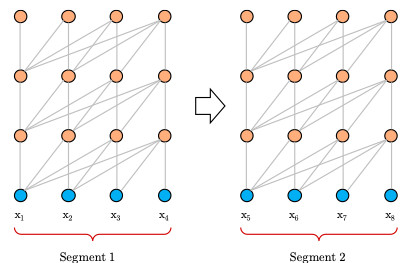

[vanilla transformer LM의 학습 단계 (출처 : https://arxiv.org/pdf/1901.02860.pdf)]

테스트 시 또 다른 문제가 등장하게 되죠. 바로 슬라이딩을 하면서 생기는 문제입니다. 모델은 일정 길이의 context를 보고 한 단어를 예측합니다. 그다음에 딱 한 개만큼만 슬라이딩하여 새로운 context를 만들고 다시 연산하여 하나의 단어를 예측합니다.

이렇게 하면 이전 context를 조금씩이나마 유지할 수 있을지 모르지만 연산에 드는 비용이 엄청나겠죠?

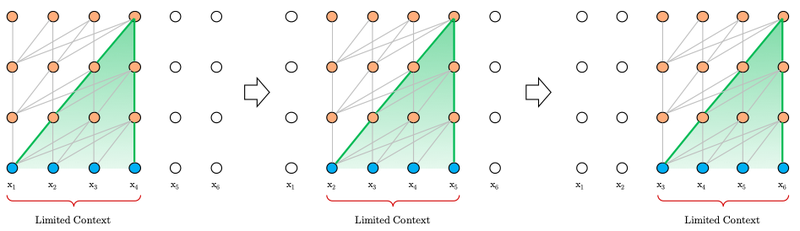

[vanilla transformer LM의 테스트 단계 (출처 : https://arxiv.org/pdf/1901.02860.pdf)]


**2. Segment-level recurrence with state reuse**

이러한 문제들을 해결하기 위해 저자들은 recurrence 메커니즘을 도입합니다. 학습 시에 이전 segment에서 계산했었던 hidden state를 사용하는 것이죠. 이를 통해 context fragmentation을 해결하고 long-term dependency를 유지할 수 있게 됩니다.

RNN의 원리를 떠올리면 쉽게 와닿으실 겁니다. 그러나 RNN과는 달리, transformer-XL은 다음 layer에서 이전 layer의 hidden state를 재사용하게 됩니다.

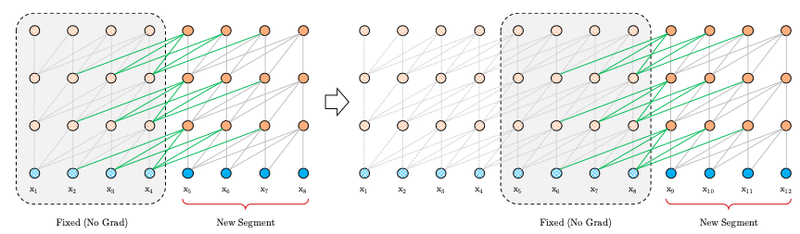

[recurrence를 도입한 구조의 학습 단계 (출처 : https://arxiv.org/pdf/1901.02860.pdf)]

**Q. Transformer은 파라미터 수가 압도적으로 많은데, 이전 layer의 hidden state를 재사용할 경우 메모리 부하는 어떻게 감당하나요?**

A. [이전 segment들의 정보를 가진 hidden state들의 gradient는 더 이상 변하지 않도록 고정을 시킵니다! ]

<details>
<summary>💡예시답안 확인하기💡</summary>

좋은 질문입니다! 이때 이전 segment들의 정보를 가진 hidden state들의 gradient는 더 이상 변하지 않도록 고정을 시킵니다(메모리에 있던 값을 불러온다고 하여 cache라고 부르기도 합니다).

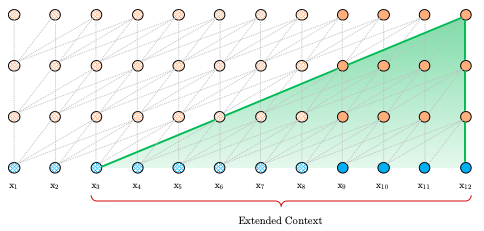

[recurrence를 도입한 구조의 테스트 단계 (출처 : https://arxiv.org/pdf/1901.02860.pdf)]

트랜스포머 구조의 LM이 테스트 시 가지고 있던 문제도 recurrence 메커니즘을 이용하면 쉽게 해결할 수 있습니다. 이미 계산한 hidden state의 정보를 메모리에 가지고 있다가 cache를 하기 때문에 계속해서 반복하여 똑같은 연산을 할 필요가 없어집니다. 이 덕분에 속도도 더욱 빨라질 수 있습니다.

**3. Relative Positional Encodings**

트랜스포머에 segment-level의 recurrence 메커니즘을 적용하면 한 가지 문제가 발생합니다. 바로 포지션 정보를 어떻게 추가할 것인가에 대한 문제이죠.

기존 트랜스포머의 포지션 인코딩은 각 segment 내에서의 절대적인 위치 정보를 인코딩하게 됩니다.

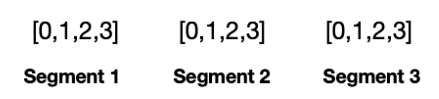

그러나 recurrence 메커니즘을 사용하게 되면 segment들 사이에서의 상대적인 위치 정보가 필요합니다.

이를 위해 저자들은 상대적인 포지션 인코딩(Relative Positional Encodings) 방법을 제안합니다.

수식 때문에 조금 복잡해 보일 수도 있지만, 기억하실 것은 **상대적인 정보**를 임베딩 레이어가 아닌 **attention 연산 시에 주입**한다는 것입니다.

**1) 트랜스포머의 attention 연산**

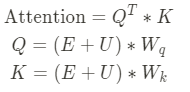

트랜스포머의 attention 연산을 수식으로 나타내면 위와 같습니다. 여기서 $E$는 토큰 임베딩, $U$는 포지션 인코딩을 의미하죠. attention 연산에 $Q$와 $K$를 대입하면 아래와 같은 식이 나타납니다.

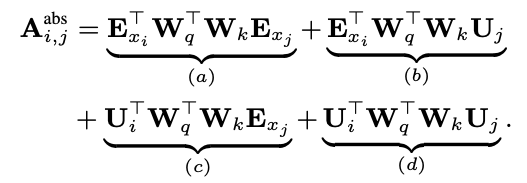

[트랜스포머의 attention 연산 (출처 : https://arxiv.org/pdf/1901.02860.pdf)]

$U$에 인코딩된 i,j번째 포지션의 정보를 가지고 연산을 하는 모양새입니다.

그러나 위에서 언급했듯이 이제는 상대적인 위치 정보가 필요합니다. i=1,j=2이든 i=7,j=8이든 상관없이 j가 i보다 1뒤에 있다만 알면 되는 것이죠.

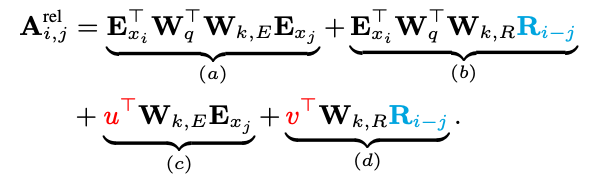

[relative position encoding을 이용한 attention 연산 (출처 : https://arxiv.org/pdf/1901.02860.pdf)]

이를 위해 $U$ 대신 $R$을 사용합니다. $R$은 상대적인 포지션 정보를 encoding한 매트릭스입니다. $R$의 i번째 행은 i와 다른 단어들 간의 상대적인 포지션을 알려주죠. 따라서, 아래 첨자 i−j에서 보이듯이, i와 j의 상대적인 거리를 이용하고 있습니다. 여기서 $R$은 기존의 트랜스포머와 마찬가지로 학습되는 것이 아닌 sinusoid encoding matrix를 사용합니다.

또한, 학습 가능한 파라미터로 벡터 u와 v가 추가되었습니다. 기존 트랜스포머는 query의 위치에 따라 그 query vector가 영향을 받았습니다. 그러나 절대적인 포지션이 아닌 상대적인 포지션 정보를 이용하게 되면서 query는 그 위치에 상관없이 똑같은 query vector를 사용하게 됩니다. 따라서 포지션에 상관없이 같은 값인 벡터 u와 v로 대신하게 되었습니다.

마지막으로, content-based key vectors와 location-based key vectors를 독립적으로 만들기 위해 $W_{k, E}$와 $W_{k, R}$를 분리했습니다.

이렇게 recurrence 메커니즘과 relative position encoding을 통해 transformer-XL은 auxiliary losses 없이도 뛰어난 성능을 낼 수 있었다고 말합니다.


**4. 그렇다면 Transformer-XL의 모델 부분을 코드로 한 번 확인해 볼까요?**

위에서 읽었던 내용들을 상기시키면서 코드를 확인해 봅시다! `TFTransfoXLMainLayer`이라는 메인 클래스 안에서 Transformer-XL의 주요 특징인 State Reuse를 위한 메모리 관리가 구현된 `_update_mems()` 메소드, 그리고 `TFRelPartialLearnableMultiHeadAttn` 레이어에 구현된 Relative attention이 `TFRelPartialLearnableDecoderLayer` 안에서 어떻게 recurrent하게 사용되는지를 눈여겨 봐주세요.

<details>
<summary>코드보기</summary>
<div markdown="1">



```
class TFPositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, demb, **kwargs):
        super().__init__(**kwargs)

        self.inv_freq = 1 / (10000 ** (tf.range(0, demb, 2.0) / demb))

    def call(self, pos_seq, bsz=None):
        sinusoid_inp = tf.einsum("i,j->ij", pos_seq, self.inv_freq)
        pos_emb = tf.concat([tf.sin(sinusoid_inp), tf.cos(sinusoid_inp)], -1)

        if bsz is not None:
            return tf.tile(pos_emb[:, None, :], [1, bsz, 1])
        else:
            return pos_emb[:, None, :]


class TFPositionwiseFF(tf.keras.layers.Layer):
    def __init__(self, d_model, d_inner, dropout, pre_lnorm=False, layer_norm_epsilon=1e-5, init_std=0.02, **kwargs):
        super().__init__(**kwargs)

        self.d_model = d_model
        self.d_inner = d_inner
        self.dropout = dropout

        self.layer_1 = tf.keras.layers.Dense(
            d_inner, kernel_initializer=get_initializer(init_std), activation=tf.nn.relu, name="CoreNet_._0"
        )
        self.drop_1 = tf.keras.layers.Dropout(dropout)
        self.layer_2 = tf.keras.layers.Dense(d_model, kernel_initializer=get_initializer(init_std), name="CoreNet_._3")
        self.drop_2 = tf.keras.layers.Dropout(dropout)

        self.layer_norm = tf.keras.layers.LayerNormalization(epsilon=layer_norm_epsilon, name="layer_norm")

        self.pre_lnorm = pre_lnorm

    def call(self, inp, training=False):
        if self.pre_lnorm:
            # layer normalization + positionwise feed-forward
            core_out = self.layer_norm(inp)
            core_out = self.layer_1(core_out)
            core_out = self.drop_1(core_out, training=training)
            core_out = self.layer_2(core_out)
            core_out = self.drop_2(core_out, training=training)

            # residual connection
            output = core_out + inp
        else:
            # positionwise feed-forward
            core_out = self.layer_1(inp)
            core_out = self.drop_1(core_out, training=training)
            core_out = self.layer_2(core_out)
            core_out = self.drop_2(core_out, training=training)

            # residual connection + layer normalization
            output = self.layer_norm(inp + core_out)

        return output


class TFRelPartialLearnableMultiHeadAttn(tf.keras.layers.Layer):
    def __init__(
        self,
        n_head,
        d_model,
        d_head,
        dropout,
        dropatt=0.0,
        pre_lnorm=False,
        r_r_bias=None,
        r_w_bias=None,
        layer_norm_epsilon=1e-5,
        init_std=0.02,
        output_attentions=False,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.n_head = n_head
        self.d_model = d_model
        self.d_head = d_head
        self.dropout = dropout
        self.output_attentions = output_attentions

        self.qkv_net = tf.keras.layers.Dense(
            3 * n_head * d_head, kernel_initializer=get_initializer(init_std), use_bias=False, name="qkv_net"
        )

        self.drop = tf.keras.layers.Dropout(dropout)
        self.dropatt = tf.keras.layers.Dropout(dropatt)
        self.o_net = tf.keras.layers.Dense(
            d_model, kernel_initializer=get_initializer(init_std), use_bias=False, name="o_net"
        )

        self.layer_norm = tf.keras.layers.LayerNormalization(epsilon=layer_norm_epsilon, name="layer_norm")

        self.scale = 1 / (d_head ** 0.5)

        self.pre_lnorm = pre_lnorm

        if r_r_bias is not None and r_w_bias is not None:  # Biases are shared
            self.r_r_bias = r_r_bias
            self.r_w_bias = r_w_bias
        else:
            self.r_r_bias = None
            self.r_w_bias = None

        self.r_net = tf.keras.layers.Dense(
            self.n_head * self.d_head, kernel_initializer=get_initializer(init_std), use_bias=False, name="r_net"
        )

    def build(self, input_shape):
        if self.r_r_bias is None or self.r_w_bias is None:  # Biases are not shared
            self.r_r_bias = self.add_weight(
                shape=(self.n_head, self.d_head), initializer="zeros", trainable=True, name="r_r_bias"
            )
            self.r_w_bias = self.add_weight(
                shape=(self.n_head, self.d_head), initializer="zeros", trainable=True, name="r_w_bias"
            )
        super().build(input_shape)

    def _rel_shift(self, x):
		"""
		relative attention을 수행하기 위한 masking
		"""

        x_size = shape_list(x)

        x = tf.pad(x, [[0, 0], [1, 0], [0, 0], [0, 0]])
        x = tf.reshape(x, [x_size[1] + 1, x_size[0], x_size[2], x_size[3]])
        x = tf.slice(x, [1, 0, 0, 0], [-1, -1, -1, -1])
        x = tf.reshape(x, x_size)

        return x

    def call(self, w, r, attn_mask, mems, head_mask, output_attentions, training=False):
        """
				w는 embedding, r은 postional embedding
				"""

				qlen, rlen, bsz = shape_list(w)[0], shape_list(r)[0], shape_list(w)[1]

        if mems is not None:
            cat = tf.concat([mems, w], 0)
            if self.pre_lnorm:
                w_heads = self.qkv_net(self.layer_norm(cat))
            else:
                w_heads = self.qkv_net(cat)
            r_head_k = self.r_net(r)

            w_head_q, w_head_k, w_head_v = tf.split(w_heads, 3, axis=-1)
            w_head_q = w_head_q[-qlen:]
        else:
            if self.pre_lnorm:
                w_heads = self.qkv_net(self.layer_norm(w))
            else:
                w_heads = self.qkv_net(w)
            r_head_k = self.r_net(r)

            w_head_q, w_head_k, w_head_v = tf.split(w_heads, 3, axis=-1)

        klen = shape_list(w_head_k)[0]

        w_head_q = tf.reshape(w_head_q, (qlen, bsz, self.n_head, self.d_head))  # qlen x bsz x n_head x d_head
        w_head_k = tf.reshape(w_head_k, (klen, bsz, self.n_head, self.d_head))  # qlen x bsz x n_head x d_head
        w_head_v = tf.reshape(w_head_v, (klen, bsz, self.n_head, self.d_head))  # qlen x bsz x n_head x d_head

        r_head_k = tf.reshape(r_head_k, (rlen, self.n_head, self.d_head))  # qlen x n_head x d_head

        # compute attention score
        rw_head_q = w_head_q + self.r_w_bias  # qlen x bsz x n_head x d_head
        AC = tf.einsum("ibnd,jbnd->ijbn", rw_head_q, w_head_k)  # qlen x klen x bsz x n_head

        rr_head_q = w_head_q + self.r_r_bias
        BD = tf.einsum("ibnd,jnd->ijbn", rr_head_q, r_head_k)  # qlen x klen x bsz x n_head
        BD = self._rel_shift(BD)

        # [qlen x klen x bsz x n_head]
        attn_score = AC + BD
        attn_score = attn_score * self.scale

        # compute attention probability
        if attn_mask is not None:
            attn_mask_t = attn_mask[:, :, None, None]
            attn_score = attn_score * (1 - attn_mask_t) - 1e30 * attn_mask_t

        # [qlen x klen x bsz x n_head]
        attn_prob = tf.nn.softmax(attn_score, axis=1)
        attn_prob = self.dropatt(attn_prob, training=training)

        if head_mask is not None:
            attn_prob = attn_prob * head_mask

        # compute attention vector
        attn_vec = tf.einsum("ijbn,jbnd->ibnd", attn_prob, w_head_v)

        # [qlen x bsz x n_head x d_head]
        attn_vec_sizes = shape_list(attn_vec)
        attn_vec = tf.reshape(attn_vec, (attn_vec_sizes[0], attn_vec_sizes[1], self.n_head * self.d_head))

        # linear projection
        attn_out = self.o_net(attn_vec)
        attn_out = self.drop(attn_out, training=training)

        if self.pre_lnorm:
            # residual connection
            outputs = [w + attn_out]
        else:
            # residual connection + layer normalization
            outputs = [self.layer_norm(w + attn_out)]

        if output_attentions:
            outputs.append(attn_prob)

        return outputs


class TFRelPartialLearnableDecoderLayer(tf.keras.layers.Layer):
    def __init__(
        self,
        n_head,
        d_model,
        d_head,
        d_inner,
        dropout,
        dropatt=0.0,
        pre_lnorm=False,
        r_w_bias=None,
        r_r_bias=None,
        layer_norm_epsilon=1e-5,
        init_std=0.02,
        output_attentions=False,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.dec_attn = TFRelPartialLearnableMultiHeadAttn(
            n_head,
            d_model,
            d_head,
            dropout,
            dropatt=dropatt,
            pre_lnorm=pre_lnorm,
            r_w_bias=r_w_bias,
            r_r_bias=r_r_bias,
            init_std=init_std,
            layer_norm_epsilon=layer_norm_epsilon,
            output_attentions=output_attentions,
            name="dec_attn",
        )
        self.pos_ff = TFPositionwiseFF(
            d_model,
            d_inner,
            dropout,
            pre_lnorm=pre_lnorm,
            init_std=init_std,
            layer_norm_epsilon=layer_norm_epsilon,
            name="pos_ff",
        )

    def call(self, dec_inp, r, dec_attn_mask, mems, head_mask, output_attentions, training=False):
        attn_outputs = self.dec_attn(dec_inp, r, dec_attn_mask, mems, head_mask, output_attentions, training=training)
        ff_output = self.pos_ff(attn_outputs[0], training=training)

        outputs = [ff_output] + attn_outputs[1:]

        return outputs


class TFAdaptiveEmbedding(tf.keras.layers.Layer):
"""
n개의 token을 한 번에 임베딩하는 것이 아니라 먼저 cutoff를 통해 n개의 tokens을 나누고 mask_i = (inp_flat >= l_idx) & (inp_flat < r_idx) 을 만족하는 토큰들만을 임베딩하는 방식
"""

    def __init__(self, n_token, d_embed, d_proj, cutoffs, div_val=1, init_std=0.02, sample_softmax=False, **kwargs):
        super().__init__(**kwargs)

        self.n_token = n_token
        self.d_embed = d_embed
        self.init_std = init_std

        self.cutoffs = cutoffs + [n_token]
        self.div_val = div_val
        self.d_proj = d_proj

        self.emb_scale = d_proj ** 0.5

        self.cutoff_ends = [0] + self.cutoffs

        self.emb_layers = []
        self.emb_projs = []
        if div_val == 1:
            raise NotImplementedError  # Removed these to avoid maintaining dead code - They are not used in our pretrained checkpoint
        else:
            for i in range(len(self.cutoffs)):
                l_idx, r_idx = self.cutoff_ends[i], self.cutoff_ends[i + 1]
                d_emb_i = d_embed // (div_val ** i)
                self.emb_layers.append(
                    tf.keras.layers.Embedding(
                        r_idx - l_idx,
                        d_emb_i,
                        embeddings_initializer=get_initializer(init_std),
                        name="emb_layers_._{}".format(i),
                    )
                )

    def build(self, input_shape):
        for i in range(len(self.cutoffs)):
            d_emb_i = self.d_embed // (self.div_val ** i)
            self.emb_projs.append(
                self.add_weight(
                    shape=(d_emb_i, self.d_proj),
                    initializer=get_initializer(self.init_std),
                    trainable=True,
                    name="emb_projs_._{}".format(i),
                )
            )
        super().build(input_shape)

    def call(self, inp):
        if self.div_val == 1:
            raise NotImplementedError  # Removed these to avoid maintaining dead code - They are not used in our pretrained checkpoint
        else:
            inp_flat = tf.reshape(inp, (-1,))
            emb_flat = tf.zeros([shape_list(inp_flat)[0], self.d_proj])
            for i in range(len(self.cutoffs)):
                l_idx, r_idx = self.cutoff_ends[i], self.cutoff_ends[i + 1]

                mask_i = (inp_flat >= l_idx) & (inp_flat < r_idx)

                inp_i = tf.boolean_mask(inp_flat, mask_i) - l_idx
                emb_i = self.emb_layers[i](inp_i)
                emb_i = tf.einsum("id,de->ie", emb_i, self.emb_projs[i])

                mask_idx = tf.cast(tf.where(mask_i), dtype=tf.int64)
                emb_flat += tf.scatter_nd(mask_idx, emb_i, tf.cast(shape_list(emb_flat), dtype=tf.int64))

            embed_shape = shape_list(inp) + [self.d_proj]
            embed = tf.reshape(emb_flat, embed_shape)

        embed *= self.emb_scale

        return embed


@keras_serializable
class TFTransfoXLMainLayer(tf.keras.layers.Layer):
    config_class = TransfoXLConfig

    def __init__(self, config, **kwargs):
        super().__init__(**kwargs)
        self.output_hidden_states = config.output_hidden_states
        self.output_attentions = config.output_attentions
        self.return_dict = config.use_return_dict

        self.n_token = config.vocab_size

        self.d_embed = config.d_embed
        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = config.d_head
        self.untie_r = config.untie_r

        self.word_emb = TFAdaptiveEmbedding(
            config.vocab_size,
            config.d_embed,
            config.d_model,
            config.cutoffs,
            div_val=config.div_val,
            init_std=config.init_std,
            name="word_emb",
        )

        self.drop = tf.keras.layers.Dropout(config.dropout)

        self.n_layer = config.n_layer
        self.mem_len = config.mem_len
        self.attn_type = config.attn_type

        self.layers = []
        if config.attn_type == 0:  # the default attention
            for i in range(config.n_layer):
                self.layers.append(
                    TFRelPartialLearnableDecoderLayer(
                        config.n_head,
                        config.d_model,
                        config.d_head,
                        config.d_inner,
                        config.dropout,
                        dropatt=config.dropatt,
                        pre_lnorm=config.pre_lnorm,
                        r_w_bias=None if self.untie_r else self.r_w_bias,
                        r_r_bias=None if self.untie_r else self.r_r_bias,
                        layer_norm_epsilon=config.layer_norm_epsilon,
                        init_std=config.init_std,
                        output_attentions=self.output_attentions,
                        name="layers_._{}".format(i),
                    )
                )
        else:  # learnable embeddings and absolute embeddings
            raise NotImplementedError  # Removed these to avoid maintaining dead code - They are not used in our pretrained checkpoint

        self.same_length = config.same_length
        self.clamp_len = config.clamp_len

        if self.attn_type == 0:  # default attention
            self.pos_emb = TFPositionalEmbedding(self.d_model, name="pos_emb")
        else:  # learnable embeddings and absolute embeddings
            raise NotImplementedError  # Removed these to avoid maintaining dead code - They are not used in our pretrained checkpoint

    def build(self, input_shape):
        if not self.untie_r:
            self.r_w_bias = self.add_weight(
                shape=(self.n_head, self.d_head), initializer="zeros", trainable=True, name="r_w_bias"
            )
            self.r_r_bias = self.add_weight(
                shape=(self.n_head, self.d_head), initializer="zeros", trainable=True, name="r_r_bias"
            )
        super().build(input_shape)

    def get_input_embeddings(self):
        return self.word_emb

    def set_input_embeddings(self, value):
        raise NotImplementedError

    def _resize_token_embeddings(self, new_num_tokens):
        return self.word_emb

    def backward_compatible(self):
        self.sample_softmax = -1

    def reset_memory_length(self, mem_len):
        self.mem_len = mem_len

    def _prune_heads(self, heads):
        raise NotImplementedError

    def init_mems(self, bsz):
        if self.mem_len > 0:
            mems = []
            for i in range(self.n_layer):
                empty = tf.zeros([self.mem_len, bsz, self.d_model])
                mems.append(empty)

            return mems
        else:
            return None

    def _update_mems(self, hids, mems, mlen, qlen):
		"""
		한 칸씩 슬라이딩하며, memory에 새로운 segment를 추가합니다. 이때, tf.stop_gradient를 통해 이전부터 보았던 segment는 gradient가 더 이상 흐르지 않도록 tf.stop_gradient를 사용
		"""
        if mems is None:
            return None

        # mems is not None
        assert len(hids) == len(mems), "len(hids) != len(mems)"

        # `mlen + qlen` steps
        new_mems = []
        end_idx = mlen + max(0, qlen)
        beg_idx = max(0, end_idx - self.mem_len)
        for i in range(len(hids)):

            cat = tf.concat([mems[i], hids[i]], axis=0)
            tf.stop_gradient(cat)
            new_mems.append(cat[beg_idx:end_idx])

        return new_mems

    def call(
        self,
        inputs,
        mems=None,
        head_mask=None,
        inputs_embeds=None,
        output_attentions=None,
        output_hidden_states=None,
        return_dict=None,
        training=False,
    ):
        if isinstance(inputs, (tuple, list)):
            input_ids = inputs[0]
            mems = inputs[1] if len(inputs) > 1 else mems
            head_mask = inputs[2] if len(inputs) > 2 else head_mask
            inputs_embeds = inputs[3] if len(inputs) > 3 else inputs_embeds
            output_attentions = inputs[4] if len(inputs) > 4 else output_attentions
            output_hidden_states = inputs[5] if len(inputs) > 5 else output_hidden_states
            return_dict = inputs[6] if len(inputs) > 6 else return_dict
            assert len(inputs) <= 7, "Too many inputs."
        elif isinstance(inputs, (dict, BatchEncoding)):
            input_ids = inputs.get("input_ids")
            mems = inputs.get("mems", mems)
            head_mask = inputs.get("head_mask", head_mask)
            inputs_embeds = inputs.get("inputs_embeds", inputs_embeds)
            output_attentions = inputs.get("output_attentions", output_attentions)
            output_hidden_states = inputs.get("output_hidden_states", output_hidden_states)
            return_dict = inputs.get("return_dict", return_dict)
            assert len(inputs) <= 7, "Too many inputs."
        else:
            input_ids = inputs

        output_attentions = output_attentions if output_attentions is not None else self.output_attentions
        output_hidden_states = output_hidden_states if output_hidden_states is not None else self.output_hidden_states
        return_dict = return_dict if return_dict is not None else self.return_dict

        # the original code for Transformer-XL used shapes [len, bsz] but we want a unified interface in the library
        # so we transpose here from shape [bsz, len] to shape [len, bsz]
        if input_ids is not None and inputs_embeds is not None:
            raise ValueError("You cannot specify both input_ids and inputs_embeds at the same time")
        elif input_ids is not None:
            input_ids = tf.transpose(input_ids, perm=(1, 0))
            qlen, bsz = shape_list(input_ids)
        elif inputs_embeds is not None:
            inputs_embeds = tf.transpose(inputs_embeds, perm=(1, 0, 2))
            qlen, bsz = shape_list(inputs_embeds)[:2]
        else:
            raise ValueError("You have to specify either input_ids or inputs_embeds")

        if mems is None:
            mems = self.init_mems(bsz)

        # Prepare head mask if needed
        # 1.0 in head_mask indicate we keep the head
        # attention_probs has shape bsz x n_heads x N x N
        # input head_mask has shape [num_heads] or [num_hidden_layers x num_heads] (a head_mask for each layer)
        # and head_mask is converted to shape [num_hidden_layers x qlen x klen x bsz x n_head]
        if head_mask is not None:
            raise NotImplementedError
        else:
            head_mask = [None] * self.n_layer

        if inputs_embeds is not None:
            word_emb = inputs_embeds
        else:
            word_emb = self.word_emb(input_ids)

        mlen = shape_list(mems[0])[0] if mems is not None else 0
        klen = mlen + qlen

        attn_mask = tf.ones([qlen, qlen])
        mask_u = tf.linalg.band_part(attn_mask, 0, -1)
        mask_dia = tf.linalg.band_part(attn_mask, 0, 0)
        attn_mask_pad = tf.zeros([qlen, mlen])
        dec_attn_mask = tf.concat([attn_mask_pad, mask_u - mask_dia], 1)
        if self.same_length:
            mask_l = tf.linalg.band_part(attn_mask, -1, 0)
            dec_attn_mask = tf.concat([dec_attn_mask[:, :qlen] + mask_l - mask_dia, dec_attn_mask[:, qlen:]], 1)
        # ::: PyTorch masking code for reference :::
        # if self.same_length:
        #     all_ones = word_emb.new_ones((qlen, klen), dtype=torch.uint8)
        #     mask_len = klen - self.mem_len
        #     if mask_len > 0:
        #         mask_shift_len = qlen - mask_len
        #     else:
        #         mask_shift_len = qlen
        #     dec_attn_mask = (torch.triu(all_ones, 1+mlen)
        #             + torch.tril(all_ones, -mask_shift_len))[:, :, None] # -1
        # else:
        #     dec_attn_mask = torch.triu(
        #         word_emb.new_ones((qlen, klen), dtype=torch.uint8), diagonal=1+mlen)[:,:,None]

        hids = []
        attentions = [] if output_attentions else None
        if self.attn_type == 0:  # default
            pos_seq = tf.range(klen - 1, -1, -1.0)
            if self.clamp_len > 0:
                pos_seq = tf.minimum(pos_seq, self.clamp_len)
            pos_emb = self.pos_emb(pos_seq)

            core_out = self.drop(word_emb, training=training)
            pos_emb = self.drop(pos_emb, training=training)

            for i, layer in enumerate(self.layers):
                hids.append(core_out)
                mems_i = None if mems is None else mems[i]
                layer_outputs = layer(
                    core_out,
                    pos_emb,
                    dec_attn_mask,
                    mems_i,
                    head_mask[i],
                    output_attentions,
                    training=training,
                )
                core_out = layer_outputs[0]
                if output_attentions:
                    attentions.append(layer_outputs[1])
        else:  # learnable embeddings and absolute embeddings
            raise NotImplementedError

        core_out = self.drop(core_out, training=training)

        new_mems = self._update_mems(hids, mems, mlen, qlen)

        # [bsz, len, hidden_dim]
        core_out = tf.transpose(core_out, perm=(1, 0, 2))

        if output_hidden_states:
            # last layer를 추가하고 다시 library standard shape [bsz, len, hidden_dim]으로 transpose
            hids.append(core_out)
            hids = tuple(tf.transpose(t, perm=(1, 0, 2)) for t in hids)
        else:
            hids = None
        if output_attentions:
            # Transpose to library standard shape [bsz, n_heads, query_seq_len, key_seq_len]
            attentions = tuple(tf.transpose(t, perm=(2, 3, 0, 1)) for t in attentions)

        if not return_dict:
            return tuple(v for v in [core_out, new_mems, hids, attentions] if v is not None)

        return TFTransfoXLModelOutput(
            last_hidden_state=core_out,
            mems=new_mems,
            hidden_states=hids,
            attentions=attentions,
        )

class TFAdaptiveSoftmaxMask(tf.keras.layers.Layer):
    def __init__(self, vocab_size, d_embed, d_proj, cutoffs, div_val=1, keep_order=False, **kwargs):
        super().__init__(**kwargs)

        self.vocab_size = vocab_size
        self.d_embed = d_embed
        self.d_proj = d_proj

        self.cutoffs = cutoffs + [vocab_size]
        self.cutoff_ends = [0] + self.cutoffs
        self.div_val = div_val

        self.shortlist_size = self.cutoffs[0]
        self.n_clusters = len(self.cutoffs) - 1
        self.head_size = self.shortlist_size + self.n_clusters
        self.keep_order = keep_order

        self.out_layers = []
        self.out_projs = []

    def build(self, input_shape):
        if self.n_clusters > 0:
            self.cluster_weight = self.add_weight(
                shape=(self.n_clusters, self.d_embed), initializer="zeros", trainable=True, name="cluster_weight"
            )
            self.cluster_bias = self.add_weight(
                shape=(self.n_clusters,), initializer="zeros", trainable=True, name="cluster_bias"
            )

        if self.div_val == 1:
            for i in range(len(self.cutoffs)):
                if self.d_proj != self.d_embed:
                    weight = self.add_weight(
                        shape=(self.d_embed, self.d_proj),
                        initializer="zeros",
                        trainable=True,
                        name="out_projs_._{}".format(i),
                    )
                    self.out_projs.append(weight)
                else:
                    self.out_projs.append(None)
                weight = self.add_weight(
                    shape=(
                        self.vocab_size,
                        self.d_embed,
                    ),
                    initializer="zeros",
                    trainable=True,
                    name="out_layers_._{}_._weight".format(i),
                )
                bias = self.add_weight(
                    shape=(self.vocab_size,),
                    initializer="zeros",
                    trainable=True,
                    name="out_layers_._{}_._bias".format(i),
                )
                self.out_layers.append((weight, bias))
        else:
            for i in range(len(self.cutoffs)):
                l_idx, r_idx = self.cutoff_ends[i], self.cutoff_ends[i + 1]
                d_emb_i = self.d_embed // (self.div_val ** i)

                weight = self.add_weight(
                    shape=(d_emb_i, self.d_proj), initializer="zeros", trainable=True, name="out_projs_._{}".format(i)
                )
                self.out_projs.append(weight)
                weight = self.add_weight(
                    shape=(
                        r_idx - l_idx,
                        d_emb_i,
                    ),
                    initializer="zeros",
                    trainable=True,
                    name="out_layers_._{}_._weight".format(i),
                )
                bias = self.add_weight(
                    shape=(r_idx - l_idx,),
                    initializer="zeros",
                    trainable=True,
                    name="out_layers_._{}_._bias".format(i),
                )
                self.out_layers.append((weight, bias))
        super().build(input_shape)

    @staticmethod
    def _logit(x, W, b, proj=None):
        y = x
        if proj is not None:
            y = tf.einsum("ibd,ed->ibe", y, proj)
        return tf.einsum("ibd,nd->ibn", y, W) + b

    @staticmethod
    def _gather_logprob(logprob, target):
        lp_size = shape_list(logprob)
        r = tf.range(lp_size[0])
        idx = tf.stack([r, target], 1)
        return tf.gather_nd(logprob, idx)

    def call(self, hidden, target, return_mean=True, training=False):
        head_logprob = 0
        if self.n_clusters == 0:
            output = self._logit(hidden, self.out_layers[0][0], self.out_layers[0][1], self.out_projs[0])
            if target is not None:
                loss = tf.nn.sparse_softmax_cross_entropy_with_logits(labels=target, logits=output)
            out = tf.nn.log_softmax(output, axis=-1)
        else:
            hidden_sizes = shape_list(hidden)
            out = []
            loss = tf.zeros(hidden_sizes[:2], dtype=tf.float32)
            for i in range(len(self.cutoffs)):
                l_idx, r_idx = self.cutoff_ends[i], self.cutoff_ends[i + 1]
                if target is not None:
                    mask = (target >= l_idx) & (target < r_idx)
                    mask_idx = tf.where(mask)
                    cur_target = tf.boolean_mask(target, mask) - l_idx

                if self.div_val == 1:
                    cur_W = self.out_layers[0][0][l_idx:r_idx]
                    cur_b = self.out_layers[0][1][l_idx:r_idx]
                else:
                    cur_W = self.out_layers[i][0]
                    cur_b = self.out_layers[i][1]

                if i == 0:
                    cur_W = tf.concat([cur_W, self.cluster_weight], 0)
                    cur_b = tf.concat([cur_b, self.cluster_bias], 0)

                    head_logit = self._logit(hidden, cur_W, cur_b, self.out_projs[0])
                    head_logprob = tf.nn.log_softmax(head_logit)
                    out.append(head_logprob[..., : self.cutoffs[0]])
                    if target is not None:
                        cur_head_logprob = tf.boolean_mask(head_logprob, mask)
                        cur_logprob = self._gather_logprob(cur_head_logprob, cur_target)
                else:
                    tail_logit = self._logit(hidden, cur_W, cur_b, self.out_projs[i])
                    tail_logprob = tf.nn.log_softmax(tail_logit)
                    cluster_prob_idx = self.cutoffs[0] + i - 1  # No probability for the head cluster
                    logprob_i = head_logprob[..., cluster_prob_idx, None] + tail_logprob
                    out.append(logprob_i)
                    if target is not None:
                        cur_head_logprob = tf.boolean_mask(head_logprob, mask)
                        cur_tail_logprob = tf.boolean_mask(tail_logprob, mask)
                        cur_logprob = self._gather_logprob(cur_tail_logprob, cur_target)
                        cur_logprob += cur_head_logprob[:, self.cutoff_ends[1] + i - 1]
                if target is not None:
                    loss += tf.scatter_nd(mask_idx, -cur_logprob, tf.cast(shape_list(loss), dtype=tf.int64))
            out = tf.concat(out, axis=-1)

        if target is not None:
            if return_mean:
                loss = tf.reduce_mean(loss)
            # `self.add_loss()`를 통해 training시의 loss 추가
            self.add_loss(loss)

            # Log the loss as a metric
            self.add_metric(loss, name=self.name, aggregation="mean" if return_mean else "")

        return out
```



</div>
</details>

더 자세히 알아보고 싶다면 transformer-XL의 논문을 직접 읽어보세요!

  - [Transformer-XL: Attentive Language Models](https://arxiv.org/pdf/1901.02860)

# XLNet, BART

## XLNet
---
XLNET은 구글 연구팀에서 발표한 논문으로 이전 스텝에 다루었던 transformer-XL을 이용한 아키텍처입니다. 참고로 XLNet에서 XL이란 'eXtra-Long'에서 나왔으며, 트랜스포머보다 더 넓은 범위의 문맥을 볼 수 있다는 것을 강조하게 위해서 XLNet이라는 이름이 붙었다고 합니다.

논문 XLNet: [Generalized Autoregressive Pretraining for Language Understanding](https://arxiv.org/abs/1906.08237)에서는 GPT의 AR(AutoRegressive) 언어 모델과 BERT의 AE(AutoEncoding) 언어 모델과는 다른 퍼뮤테이션(Permutation) 언어 모델을 통해 더욱 정교한 언어 모델 성능을 선보이고 있습니다.

퍼뮤테이션(Permutation) 언어 모델
---
임베딩 모델의 최근 흐름은 AR 모델과 AE 모델로 나눠집니다. 각각의 모델은 아래와 같이 정리할 수 있습니다.

  - AR(AutoRegressive) 모델: 이전 문맥을 바탕으로 다음 단어를 예측한다.
  - AE(AutoEncoding) 모델: 앞뒤 문맥을 모두 살펴 [MASK] 단어를 예측한다.

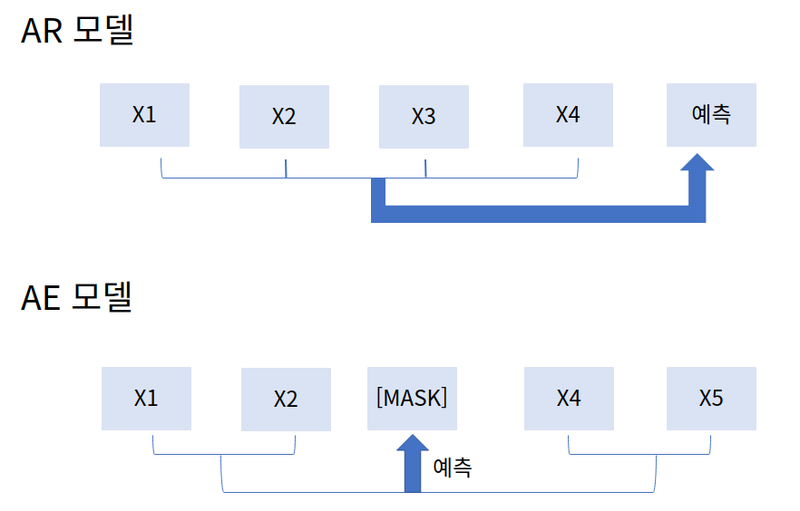

[AR모델과 AE 모델]

하지만 AR 모델과 AE 모델에는 각각 치명적인 단점이 있었습니다. AR 모델은 문맥을 양방향으로 볼 수 없었고, AE 모델은 마스킹 처리한 토큰이 독립적으로 예측되므로 토큰 사이의 의존 관계를 학습할 수 없는데다가 fine-tuning과 evaluation 시 [MASK] 토큰이 보이지 않아 불일치가 발생했습니다.

이런 단점을 해결하기 위해 XLNet은 permutation LM을 사용하였죠. XLNet은 AR과 AE의 장점만을 취하여 AE처럼 양방향 context를 모두 볼 수 있는 동시에, AR처럼 예측해야 할 토큰들 간의 dependency를 놓치지 않고 학습할 수 있었습니다.

아래 그림에서와 같이 토큰 4개의 문장을 랜덤을 뒤섞은 결과가 [3, 2, 4, 1]일 경우 $x_3$을 예측하려고 합니다. 이 경우에는 3번 토큰 정보를 넣으면 문제가 너무 쉬우므로 3번 토큰 정보를 주어서는 안 되고, 2, 4, 1번 토큰 역시 3번 토큰 이후에 등장하므로 입력에서 제외해야 합니다. 따라서 입력값은 세그먼트의 메모리 정보입니다.

또다시 토큰을 랜덤으로 섞은 결과가 [2, 4, 3, 1]이고 3번 토큰을 예측해야 한다면 3번 토큰의 이전 문맥인 2번, 4번 토큰과 메모리가 입력됩니다.

토큰을 다시 섞은 후의 시퀀스가 [1, 4, 2, 3]이고 3번 토큰을 예측할 경우의 입력 벡터는 1번, 4번, 2번 토큰과 메모리입니다. 문장 시퀀스가 [4, 3, 1, 2]이고 3번 토큰을 예측할 경우는 4번 토큰과 메모리를 입력으로 넣어 줍니다. 이를 표현한 것이 아래의 그림입니다.



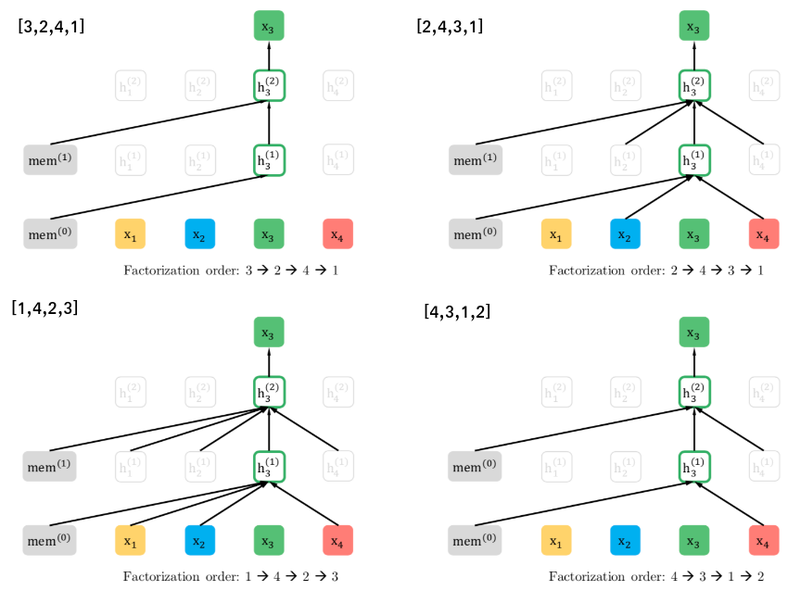

[permutation LM]

 https://ratsgo.github.io/natural%20language%20processing/2019/09/11/xlnet/

설명은 토큰을 섞는다고 하였지만 실제 구현은 어텐션 마스크로 구현되었습니다. 그 이유는 XLNet의 기반이 트랜스포머 네트워크이고, 핵심이 쿼리(query)와 키(key) 벡터간 셀프 어텐션 기법이기 때문입니다.

permutation 언어 모델에도 단점이 있었습니다. 만약 셔플된 토큰 시퀀스가 [3, 2, 4, 1]과 [3, 2, 1, 4]일 경우 모델은 동일한 입력을 받아 다른 단어를 예측해야 하죠. 이런 경우는 어떻게 해결해야 할까요?

Two-Stream Self-Attention
---
위와 같은 문제를 해결하기 위해 XLNet은 **Target-Aware Representation for Transformer**라는 것을 제안했습니다. 아래의 식에서 $p_θ$는 다음에 나올 토큰의 분포입니다. 기존의 Transformer과 달리 타겟 포지션 $z_t$를 식에 추가함으로써 동일한 representation으로 다른 타깃을 맞출 수 있었습니다.


$$p_0(X_u = x | x_{c,u}) = \frac{\exp(e(x) \cdot g_0(x_{c,u}, z_t))}{\sum_{x'} \exp(e(x') \cdot g_0(x_{c,u}, z_t))}$$

아래 그림과 같이 T 시점에서 타깃 토큰을 예측하기 위해 $g(X_{z<t}, z_t)$는 T 시점 이전의 콘텍스트와 타깃 포지션을 사용해야 하고, T 시점 이후의 토큰을 예측하려면 $g(X_{z<t}, z_t)$는 T 시점의 콘텍스트도 가지고 있어야 합니다. 즉 T 시점과 T 시점 이후를 모두 고려하기 위해 2가지 hidden representation을 사용해야 하고, 이 두 가지를 모두 사용할 수 있는 transformer 구조가 **Two-Steam Self-Attention**입니다.

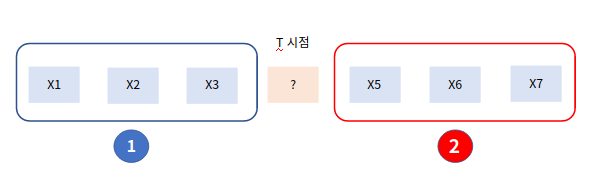

[Two-Stream Self-Attention]

Two-Stream self-attention은 쿼리 스트림(query stream)과 컨텐트 스트림(content stream)을 혼합한 것으로, 쿼리 스트림은 T 시점 이전의 토큰 정보와 T 시점의 위치 정보를 나타내고, 컨텐트 스트림은 기존의 self-attention과 같이 T 시점과 T 시점 이전의 토큰 정보를 사용합니다.

아래의 그림에서 (a)는 콘텐트 스트림을 나타내고, (b)는 쿼리 스트림입니다. (c)는 두 개의 스트림 어텐션을 사용한 permutation 언어 모델을 나타낸 것입니다.

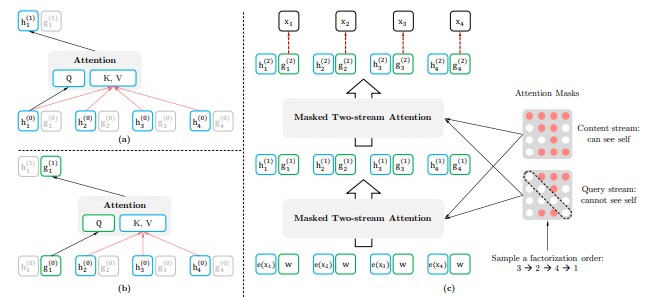

[Two-Stream Self-Attention for Target-Aware Representations]  
https://arxiv.org/pdf/1906.08237.pdf

XLNet에 대해 자세히 알고 싶다면 논문과 코드를 살펴보세요!

<details>
<summary>코드보기</summary>
<div markdown="1">



```
class TFXLNetRelativeAttention(tf.keras.layers.Layer):
    def __init__(self, config, **kwargs):
        super().__init__(**kwargs)

        if config.d_model % config.n_head != 0:
            raise ValueError(
                "The hidden size (%d) is not a multiple of the number of attention "
                "heads (%d)" % (config.d_model, config.n_head)
            )

        self.n_head = config.n_head
        self.d_head = config.d_head
        self.d_model = config.d_model
        self.scale = 1 / (config.d_head ** 0.5)
        self.initializer_range = config.initializer_range
        self.output_attentions = config.output_attentions

        self.layer_norm = tf.keras.layers.LayerNormalization(epsilon=config.layer_norm_eps, name="layer_norm")
        self.dropout = tf.keras.layers.Dropout(config.dropout)

    def build(self, input_shape):
        initializer = get_initializer(self.initializer_range)
        self.q = self.add_weight(
            shape=(self.d_model, self.n_head, self.d_head), initializer=initializer, trainable=True, name="q"
        )
        self.k = self.add_weight(
            shape=(self.d_model, self.n_head, self.d_head), initializer=initializer, trainable=True, name="k"
        )
        self.v = self.add_weight(
            shape=(self.d_model, self.n_head, self.d_head), initializer=initializer, trainable=True, name="v"
        )
        self.o = self.add_weight(
            shape=(self.d_model, self.n_head, self.d_head), initializer=initializer, trainable=True, name="o"
        )
        self.r = self.add_weight(
            shape=(self.d_model, self.n_head, self.d_head), initializer=initializer, trainable=True, name="r"
        )
        self.r_r_bias = self.add_weight(
            shape=(self.n_head, self.d_head), initializer="zeros", trainable=True, name="r_r_bias"
        )
        self.r_s_bias = self.add_weight(
            shape=(self.n_head, self.d_head), initializer="zeros", trainable=True, name="r_s_bias"
        )
        self.r_w_bias = self.add_weight(
            shape=(self.n_head, self.d_head), initializer="zeros", trainable=True, name="r_w_bias"
        )
        self.seg_embed = self.add_weight(
            shape=(2, self.n_head, self.d_head), initializer=initializer, trainable=True, name="seg_embed"
        )
        super().build(input_shape)

    def prune_heads(self, heads):
        raise NotImplementedError

    def rel_shift(self, x, klen=-1):
        """perform relative shift to form the relative attention score."""
        x_size = shape_list(x)

        x = tf.reshape(x, (x_size[1], x_size[0], x_size[2], x_size[3]))
        x = x[1:, ...]
        x = tf.reshape(x, (x_size[0], x_size[1] - 1, x_size[2], x_size[3]))
        x = x[:, 0:klen, :, :]
        # x = torch.index_select(x, 1, torch.arange(klen, device=x.device, dtype=torch.long))

        return x

    def rel_attn_core(
        self, q_head, k_head_h, v_head_h, k_head_r, seg_mat, attn_mask, head_mask, output_attentions, training=False
    ):
        """Core relative positional attention operations."""
        # content based attention score
        ac = tf.einsum("ibnd,jbnd->ijbn", q_head + self.r_w_bias, k_head_h)

        # position based attention score
        bd = tf.einsum("ibnd,jbnd->ijbn", q_head + self.r_r_bias, k_head_r)
        bd = self.rel_shift(bd, klen=shape_list(ac)[1])

        # segment based attention score
        if seg_mat is None:
            ef = 0
        else:
            ef = tf.einsum("ibnd,snd->ibns", q_head + self.r_s_bias, self.seg_embed)
            ef = tf.einsum("ijbs,ibns->ijbn", seg_mat, ef)

        # merge attention scores and perform masking
        attn_score = (ac + bd + ef) * self.scale
        if attn_mask is not None:
            # attn_score = attn_score * (1 - attn_mask) - 1e30 * attn_mask
            if attn_mask.dtype == tf.float16:
                attn_score = attn_score - 65500 * attn_mask
            else:
                attn_score = attn_score - 1e30 * attn_mask

        # attention probability
        attn_prob = tf.nn.softmax(attn_score, axis=1)

        attn_prob = self.dropout(attn_prob, training=training)

        # Mask heads if we want to
        if head_mask is not None:
            attn_prob = attn_prob * head_mask

        # attention output
        attn_vec = tf.einsum("ijbn,jbnd->ibnd", attn_prob, v_head_h)

        if output_attentions:
            return attn_vec, attn_prob

        return attn_vec

    def post_attention(self, h, attn_vec, residual=True, training=False):
        """Post-attention processing."""
        # post-attention projection (back to `d_model`)
        attn_out = tf.einsum("ibnd,hnd->ibh", attn_vec, self.o)

        attn_out = self.dropout(attn_out, training=training)

        if residual:
            attn_out = attn_out + h
        output = self.layer_norm(attn_out)

        return output

    def call(
        self,
        h,
        g,
        attn_mask_h,
        attn_mask_g,
        r,
        seg_mat,
        mems,
        target_mapping,
        head_mask,
        output_attentions,
        training=False,
    ):
        if g is not None:
            # Two-stream attention with relative positional encoding.
            # content based attention score
            if mems is not None and len(shape_list(mems)) > 1:
                cat = tf.concat([mems, h], axis=0)
            else:
                cat = h

            # content-based key head
            k_head_h = tf.einsum("ibh,hnd->ibnd", cat, self.k)

            # content-based value head
            v_head_h = tf.einsum("ibh,hnd->ibnd", cat, self.v)

            # position-based key head
            k_head_r = tf.einsum("ibh,hnd->ibnd", r, self.r)

            # h-stream
            # content-stream query head
            q_head_h = tf.einsum("ibh,hnd->ibnd", h, self.q)

            # core attention ops
            attn_vec_h = self.rel_attn_core(
                q_head_h,
                k_head_h,
                v_head_h,
                k_head_r,
                seg_mat,
                attn_mask_h,
                head_mask,
                output_attentions,
                training=training,
            )

            if output_attentions:
                attn_vec_h, attn_prob_h = attn_vec_h

            # post processing
            output_h = self.post_attention(h, attn_vec_h, training=training)

            # g-stream
            # query-stream query head
            q_head_g = tf.einsum("ibh,hnd->ibnd", g, self.q)

            # core attention ops
            if target_mapping is not None:
                q_head_g = tf.einsum("mbnd,mlb->lbnd", q_head_g, target_mapping)
                attn_vec_g = self.rel_attn_core(
                    q_head_g,
                    k_head_h,
                    v_head_h,
                    k_head_r,
                    seg_mat,
                    attn_mask_g,
                    head_mask,
                    output_attentions,
                    training=training,
                )

                if output_attentions:
                    attn_vec_g, attn_prob_g = attn_vec_g

                attn_vec_g = tf.einsum("lbnd,mlb->mbnd", attn_vec_g, target_mapping)
            else:
                attn_vec_g = self.rel_attn_core(
                    q_head_g,
                    k_head_h,
                    v_head_h,
                    k_head_r,
                    seg_mat,
                    attn_mask_g,
                    head_mask,
                    output_attentions,
                    training=training,
                )

                if output_attentions:
                    attn_vec_g, attn_prob_g = attn_vec_g

            # post processing
            output_g = self.post_attention(g, attn_vec_g, training=training)

            if output_attentions:
                attn_prob = attn_prob_h, attn_prob_g

        else:
            # Multi-head attention with relative positional encoding
            if mems is not None and len(shape_list(mems)) > 1:
                cat = tf.concat([mems, h], axis=0)
            else:
                cat = h

            # content heads
            q_head_h = tf.einsum("ibh,hnd->ibnd", h, self.q)
            k_head_h = tf.einsum("ibh,hnd->ibnd", cat, self.k)
            v_head_h = tf.einsum("ibh,hnd->ibnd", cat, self.v)

            # positional heads
            k_head_r = tf.einsum("ibh,hnd->ibnd", r, self.r)

            # core attention ops
            attn_vec = self.rel_attn_core(
                q_head_h,
                k_head_h,
                v_head_h,
                k_head_r,
                seg_mat,
                attn_mask_h,
                head_mask,
                output_attentions,
                training=training,
            )

            if output_attentions:
                attn_vec, attn_prob = attn_vec

            # post processing
            output_h = self.post_attention(h, attn_vec, training=training)
            output_g = None

        outputs = (output_h, output_g)
        if output_attentions:
            outputs = outputs + (attn_prob,)
        return outputs


class TFXLNetFeedForward(tf.keras.layers.Layer):
    def __init__(self, config, **kwargs):
        super().__init__(**kwargs)
        self.layer_norm = tf.keras.layers.LayerNormalization(epsilon=config.layer_norm_eps, name="layer_norm")
        self.layer_1 = tf.keras.layers.Dense(
            config.d_inner, kernel_initializer=get_initializer(config.initializer_range), name="layer_1"
        )
        self.layer_2 = tf.keras.layers.Dense(
            config.d_model, kernel_initializer=get_initializer(config.initializer_range), name="layer_2"
        )
        self.dropout = tf.keras.layers.Dropout(config.dropout)
        if isinstance(config.ff_activation, str):
            self.activation_function = get_tf_activation(config.ff_activation)
        else:
            self.activation_function = config.ff_activation

    def call(self, inp, training=False):
        output = inp
        output = self.layer_1(output)
        output = self.activation_function(output)
        output = self.dropout(output, training=training)
        output = self.layer_2(output)
        output = self.dropout(output, training=training)
        output = self.layer_norm(output + inp)
        return output


class TFXLNetLayer(tf.keras.layers.Layer):
    def __init__(self, config, **kwargs):
        super().__init__(**kwargs)
        self.rel_attn = TFXLNetRelativeAttention(config, name="rel_attn")
        self.ff = TFXLNetFeedForward(config, name="ff")
        self.dropout = tf.keras.layers.Dropout(config.dropout)

    def call(
        self,
        output_h,
        output_g,
        non_tgt_mask,
        attn_mask,
        pos_emb,
        seg_mat,
        mems,
        target_mapping,
        head_mask,
        output_attentions,
        training=False,
    ):
        outputs = self.rel_attn(
            output_h,
            output_g,
            non_tgt_mask,
            attn_mask,
            pos_emb,
            seg_mat,
            mems,
            target_mapping,
            head_mask,
            output_attentions,
            training=training,
        )
        output_h, output_g = outputs[:2]

        if output_g is not None:
            output_g = self.ff(output_g, training=training)
        output_h = self.ff(output_h, training=training)

        outputs = (output_h, output_g) + outputs[2:]  # Add again attentions if there are there
        return outputs


class TFXLNetLMHead(tf.keras.layers.Layer):
    def __init__(self, config, input_embeddings, **kwargs):
        super().__init__(**kwargs)
        self.vocab_size = config.vocab_size
        # The output weights are the same as the input embeddings, but there is
        # an output-only bias for each token.
        self.input_embeddings = input_embeddings

    def build(self, input_shape):
        self.bias = self.add_weight(shape=(self.vocab_size,), initializer="zeros", trainable=True, name="bias")
        super().build(input_shape)

    def call(self, hidden_states):
        hidden_states = self.input_embeddings(hidden_states, mode="linear")
        hidden_states = hidden_states + self.bias
        return hidden_states


@keras_serializable
class TFXLNetMainLayer(tf.keras.layers.Layer):
    config_class = XLNetConfig

    def __init__(self, config, **kwargs):
        super().__init__(**kwargs)

        self.config = config
        self.output_hidden_states = config.output_hidden_states
        self.output_attentions = config.output_attentions
        self.return_dict = config.return_dict

        self.mem_len = config.mem_len
        self.reuse_len = config.reuse_len
        self.d_model = config.d_model
        self.same_length = config.same_length
        self.attn_type = config.attn_type
        self.bi_data = config.bi_data
        self.clamp_len = config.clamp_len
        self.n_layer = config.n_layer
        self.use_bfloat16 = config.use_bfloat16
        self.initializer_range = config.initializer_range

        self.word_embedding = TFSharedEmbeddings(
            config.vocab_size, config.d_model, initializer_range=config.initializer_range, name="word_embedding"
        )
        self.layer = [TFXLNetLayer(config, name="layer_._{}".format(i)) for i in range(config.n_layer)]
        self.dropout = tf.keras.layers.Dropout(config.dropout)

        self.use_mems_eval = config.use_mems_eval
        self.use_mems_train = config.use_mems_train

    def get_input_embeddings(self):
        return self.word_embedding

    def set_input_embeddings(self, value):
        self.word_embedding.weight = value
        self.word_embedding.vocab_size = value.shape[0]

    def build(self, input_shape):
        initializer = get_initializer(self.initializer_range)
        self.mask_emb = self.add_weight(
            shape=(1, 1, self.d_model), initializer=initializer, trainable=True, name="mask_emb"
        )

    def _resize_token_embeddings(self, new_num_tokens):
        raise NotImplementedError

    def _prune_heads(self, heads_to_prune):
        raise NotImplementedError

    def create_mask(self, qlen, mlen, dtype=tf.float32):
        """
        Creates causal attention mask. Float mask where 1.0 indicates masked, 0.0 indicates not-masked.

        Args:
            qlen: TODO Lysandre didn't fill
            mlen: TODO Lysandre didn't fill

        ::

                  same_length=False:      same_length=True:
                   <  qlen >        <  qlen >
               ^ [0 0 0 0 0 1 1 1 1]     [0 0 0 0 0 1 1 1 1]
                 [0 0 0 0 0 0 1 1 1]     [1 0 0 0 0 0 1 1 1]
            qlen [0 0 0 0 0 0 0 1 1]     [1 1 0 0 0 0 0 1 1]
                 [0 0 0 0 0 0 0 0 1]     [1 1 1 0 0 0 0 0 1]
               v [0 0 0 0 0 0 0 0 0]     [1 1 1 1 0 0 0 0 0]

        """
        attn_mask = tf.ones([qlen, qlen], dtype=dtype)
        mask_u = tf.matrix_band_part(attn_mask, 0, -1)
        mask_dia = tf.matrix_band_part(attn_mask, 0, 0)
        attn_mask_pad = tf.zeros([qlen, mlen], dtype=dtype)
        ret = tf.concat([attn_mask_pad, mask_u - mask_dia], 1)
        if self.same_length:
            mask_l = tf.matrix_band_part(attn_mask, -1, 0)
            ret = tf.concat([ret[:, :qlen] + mask_l - mask_dia, ret[:, qlen:]], 1)
        return ret

    def cache_mem(self, curr_out, prev_mem):
        # cache hidden states into memory.
        if self.reuse_len is not None and self.reuse_len > 0:
            curr_out = curr_out[: self.reuse_len]

        if self.mem_len is None or self.mem_len == 0:
            # If :obj:`use_mems` is active but no `mem_len` is defined, the model behaves like GPT-2 at inference time
            # and returns all of the past and current hidden states.
            cutoff = 0
        else:
            # If :obj:`use_mems` is active and `mem_len` is defined, the model returns the last `mem_len` hidden
            # states. This is the preferred setting for training and long-form generation.
            cutoff = -self.mem_len
        if prev_mem is None:
            # if :obj:`use_mems` is active and `mem_len` is defined, the model
            new_mem = curr_out[cutoff:]
        else:
            new_mem = tf.concat([prev_mem, curr_out], 0)[cutoff:]

        return tf.stop_gradient(new_mem)

    @staticmethod
    def positional_embedding(pos_seq, inv_freq, bsz=None):
        sinusoid_inp = tf.einsum("i,d->id", pos_seq, inv_freq)
        pos_emb = tf.concat([tf.sin(sinusoid_inp), tf.cos(sinusoid_inp)], axis=-1)
        pos_emb = pos_emb[:, None, :]

        if bsz is not None:
            pos_emb = tf.tile(pos_emb, [1, bsz, 1])

        return pos_emb

    def relative_positional_encoding(self, qlen, klen, bsz=None, dtype=None):
        """create relative positional encoding."""
        freq_seq = tf.range(0, self.d_model, 2.0)
        if dtype is not None and dtype != tf.float32:
            freq_seq = tf.cast(freq_seq, dtype=dtype)
        inv_freq = 1 / (10000 ** (freq_seq / self.d_model))

        if self.attn_type == "bi":
            # beg, end = klen - 1, -qlen
            beg, end = klen, -qlen
        elif self.attn_type == "uni":
            # beg, end = klen - 1, -1
            beg, end = klen, -1
        else:
            raise ValueError("Unknown `attn_type` {}.".format(self.attn_type))

        if self.bi_data:
            fwd_pos_seq = tf.range(beg, end, -1.0)
            bwd_pos_seq = tf.range(-beg, -end, 1.0)

            if dtype is not None and dtype != tf.float32:
                fwd_pos_seq = tf.cast(fwd_pos_seq, dtype=dtype)
                bwd_pos_seq = tf.cast(bwd_pos_seq, dtype=dtype)

            if self.clamp_len > 0:
                fwd_pos_seq = tf.clip_by_value(fwd_pos_seq, -self.clamp_len, self.clamp_len)
                bwd_pos_seq = tf.clip_by_value(bwd_pos_seq, -self.clamp_len, self.clamp_len)

            if bsz is not None:
                assert bsz % 2 == 0, f"With bi_data, the batch size {bsz} should be divisible by 2"
                fwd_pos_emb = self.positional_embedding(fwd_pos_seq, inv_freq, bsz // 2)
                bwd_pos_emb = self.positional_embedding(bwd_pos_seq, inv_freq, bsz // 2)
            else:
                fwd_pos_emb = self.positional_embedding(fwd_pos_seq, inv_freq)
                bwd_pos_emb = self.positional_embedding(bwd_pos_seq, inv_freq)

            pos_emb = tf.concat([fwd_pos_emb, bwd_pos_emb], axis=1)
        else:
            fwd_pos_seq = tf.range(beg, end, -1.0)
            if dtype is not None and dtype != tf.float32:
                fwd_pos_seq = tf.cast(fwd_pos_seq, dtype=dtype)
            if self.clamp_len > 0:
                fwd_pos_seq = tf.clip_by_value(fwd_pos_seq, -self.clamp_len, self.clamp_len)
            pos_emb = self.positional_embedding(fwd_pos_seq, inv_freq, bsz)

        return pos_emb

    def call(
        self,
        input_ids=None,
        attention_mask=None,
        mems=None,
        perm_mask=None,
        target_mapping=None,
        token_type_ids=None,
        input_mask=None,
        head_mask=None,
        inputs_embeds=None,
        use_mems=None,
        output_attentions=None,
        output_hidden_states=None,
        return_dict=None,
        training=False,
        **kwargs,
    ):
        inputs = input_processing(
            func=self.call,
            config=self.config,
            input_ids=input_ids,
            attention_mask=attention_mask,
            mems=mems,
            perm_mask=perm_mask,
            target_mapping=target_mapping,
            token_type_ids=token_type_ids,
            input_mask=input_mask,
            head_mask=head_mask,
            inputs_embeds=inputs_embeds,
            use_mems=use_mems,
            output_attentions=output_attentions,
            output_hidden_states=output_hidden_states,
            return_dict=return_dict,
            training=training,
            kwargs_call=kwargs,
        )

        if training and inputs["use_mems"] is None:
            inputs["use_mems"] = self.use_mems_train
        else:
            inputs["use_mems"] = self.use_mems_eval

        # the original code for XLNet uses shapes [len, bsz] with the batch dimension at the end
        # but we want a unified interface in the library with the batch size on the first dimension
        # so we move here the first dimension (batch) to the end

        if inputs["input_ids"] is not None and inputs["inputs_embeds"] is not None:
            raise ValueError("You cannot specify both input_ids and inputs_embeds at the same time")
        elif inputs["input_ids"] is not None:
            inputs["input_ids"] = tf.transpose(inputs["input_ids"], perm=(1, 0))
            qlen, bsz = shape_list(inputs["input_ids"])[:2]
        elif inputs["inputs_embeds"] is not None:
            inputs["inputs_embeds"] = tf.transpose(inputs["inputs_embeds"], perm=(1, 0, 2))
            qlen, bsz = shape_list(inputs["inputs_embeds"])[:2]
        else:
            raise ValueError("You have to specify either input_ids or inputs_embeds")

        inputs["token_type_ids"] = (
            tf.transpose(inputs["token_type_ids"], perm=(1, 0)) if inputs["token_type_ids"] is not None else None
        )
        inputs["input_mask"] = (
            tf.transpose(inputs["input_mask"], perm=(1, 0)) if inputs["input_mask"] is not None else None
        )
        inputs["attention_mask"] = (
            tf.transpose(inputs["attention_mask"], perm=(1, 0)) if inputs["attention_mask"] is not None else None
        )
        inputs["perm_mask"] = (
            tf.transpose(inputs["perm_mask"], perm=(1, 2, 0)) if inputs["perm_mask"] is not None else None
        )
        inputs["target_mapping"] = (
            tf.transpose(inputs["target_mapping"], perm=(1, 2, 0)) if inputs["target_mapping"] is not None else None
        )

        mlen = shape_list(inputs["mems"][0])[0] if inputs["mems"] is not None and inputs["mems"][0] is not None else 0
        klen = mlen + qlen

        dtype_float = tf.bfloat16 if self.use_bfloat16 else tf.float32

        # Attention mask
        # causal attention mask
        if self.attn_type == "uni":
            attn_mask = self.create_mask(qlen, mlen)
            attn_mask = attn_mask[:, :, None, None]
        elif self.attn_type == "bi":
            attn_mask = None
        else:
            raise ValueError("Unsupported attention type: {}".format(self.attn_type))

        # data mask: input mask & perm mask
        assert inputs["input_mask"] is None or inputs["attention_mask"] is None, (
            "You can only use one of input_mask (uses 1 for padding) "
            "or attention_mask (uses 0 for padding, added for compatibility with BERT). Please choose one."
        )
        if inputs["input_mask"] is None and inputs["attention_mask"] is not None:
            inputs["input_mask"] = 1.0 - tf.cast(inputs["attention_mask"], dtype=dtype_float)
        if inputs["input_mask"] is not None and inputs["perm_mask"] is not None:
            data_mask = inputs["input_mask"][None] + inputs["perm_mask"]
        elif inputs["input_mask"] is not None and inputs["perm_mask"] is None:
            data_mask = inputs["input_mask"][None]
        elif inputs["input_mask"] is None and inputs["perm_mask"] is not None:
            data_mask = inputs["perm_mask"]
        else:
            data_mask = None

        if data_mask is not None:
            # all mems can be attended to
            if mlen > 0:
                mems_mask = tf.zeros([shape_list(data_mask)[0], mlen, bsz], dtype=dtype_float)
                data_mask = tf.concat([mems_mask, data_mask], axis=1)
            if attn_mask is None:
                attn_mask = data_mask[:, :, :, None]
            else:
                attn_mask += data_mask[:, :, :, None]

        if attn_mask is not None:
            attn_mask = tf.cast(attn_mask > 0, dtype=dtype_float)

        if attn_mask is not None:
            non_tgt_mask = -tf.eye(qlen, dtype=dtype_float)
            if mlen > 0:
                non_tgt_mask = tf.concat([tf.zeros([qlen, mlen], dtype=dtype_float), non_tgt_mask], axis=-1)
            non_tgt_mask = tf.cast((attn_mask + non_tgt_mask[:, :, None, None]) > 0, dtype=dtype_float)
        else:
            non_tgt_mask = None

        # Word embeddings and prepare h & g hidden states
        if inputs["inputs_embeds"] is not None:
            word_emb_k = inputs["inputs_embeds"]
        else:
            word_emb_k = self.word_embedding(inputs["input_ids"])
        output_h = self.dropout(word_emb_k, training=inputs["training"])
        if inputs["target_mapping"] is not None:
            word_emb_q = tf.tile(self.mask_emb, [shape_list(inputs["target_mapping"])[0], bsz, 1])
            # else:  # We removed the inp_q input which was same as target mapping
            #     inp_q_ext = inp_q[:, :, None]
            #     word_emb_q = inp_q_ext * self.mask_emb + (1 - inp_q_ext) * word_emb_k
            output_g = self.dropout(word_emb_q, training=inputs["training"])
        else:
            output_g = None

        # Segment embedding
        if inputs["token_type_ids"] is not None:
            # Convert `token_type_ids` to one-hot `seg_mat`
            if mlen > 0:
                mem_pad = tf.zeros([mlen, bsz], dtype=tf.int32)
                cat_ids = tf.concat([mem_pad, inputs["token_type_ids"]], 0)
            else:
                cat_ids = inputs["token_type_ids"]

            # `1` indicates not in the same segment [qlen x klen x bsz]
            seg_mat = tf.cast(tf.logical_not(tf.equal(inputs["token_type_ids"][:, None], cat_ids[None, :])), tf.int32)
            seg_mat = tf.one_hot(seg_mat, 2, dtype=dtype_float)
        else:
            seg_mat = None

        # Positional encoding
        pos_emb = self.relative_positional_encoding(qlen, klen, bsz=bsz, dtype=dtype_float)
        pos_emb = self.dropout(pos_emb, training=inputs["training"])

        # Prepare head mask if needed
        # 1.0 in head_mask indicate we keep the head
        # attention_probs has shape bsz x n_heads x N x N
        # input head_mask has shape [num_heads] or [num_hidden_layers x num_heads] (a head_mask for each layer)
        # and head_mask is converted to shape [num_hidden_layers x qlen x klen x bsz x n_head]
        if inputs["head_mask"] is not None:
            raise NotImplementedError
        else:
            inputs["head_mask"] = [None] * self.n_layer

        new_mems = ()
        if inputs["mems"] is None:
            inputs["mems"] = [None] * len(self.layer)

        attentions = [] if inputs["output_attentions"] else None
        hidden_states = [] if inputs["output_hidden_states"] else None
        for i, layer_module in enumerate(self.layer):
            # cache new mems
            if inputs["use_mems"]:
                new_mems = new_mems + (self.cache_mem(output_h, inputs["mems"][i]),)
            if inputs["output_hidden_states"]:
                hidden_states.append((output_h, output_g) if output_g is not None else output_h)

            outputs = layer_module(
                output_h,
                output_g,
                non_tgt_mask,
                attn_mask,
                pos_emb,
                seg_mat,
                inputs["mems"][i],
                inputs["target_mapping"],
                inputs["head_mask"][i],
                inputs["output_attentions"],
                training=inputs["training"],
            )
            output_h, output_g = outputs[:2]
            if inputs["output_attentions"]:
                attentions.append(outputs[2])

        # Add last hidden state
        if inputs["output_hidden_states"]:
            hidden_states.append((output_h, output_g) if output_g is not None else output_h)

        output = self.dropout(output_g if output_g is not None else output_h, training=inputs["training"])

        # Prepare outputs, we transpose back here to shape [bsz, len, hidden_dim] (cf. beginning of forward() method)
        output = tf.transpose(output, perm=(1, 0, 2))

        if not inputs["use_mems"]:
            new_mems = None
        if inputs["output_hidden_states"]:
            if output_g is not None:
                hidden_states = tuple(tf.transpose(h, perm=(1, 0, 2)) for hs in hidden_states for h in hs)
            else:
                hidden_states = tuple(tf.transpose(hs, perm=(1, 0, 2)) for hs in hidden_states)
        if inputs["output_attentions"]:
            attentions = tuple(tf.transpose(t, perm=(2, 3, 0, 1)) for t in attentions)

        if not inputs["return_dict"]:
            return tuple(v for v in [output, new_mems, hidden_states, attentions] if v is not None)

        return TFXLNetModelOutput(
            last_hidden_state=output, mems=new_mems, hidden_states=hidden_states, attentions=attentions
        )
```



</div>
</details>

## BART
---
BART는 특정 task가 아닌 다양한 task에 적용할 수 있도록 seq2seq 구조로 만들어진 denoising auto-encoder입니다. BART의 경우도 XLNet과 같이 AR 모델과 AE 모델의 장점을 사용한 모델이라고 보시면 됩니다. 아래의 그림과 같이 Encoder에서는 BERT와 같은 구조를, Decoder에서는 GPT와 같은 구조를 가지고 있죠.

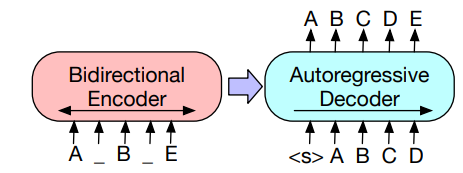

[BART의 구조]  
https://arxiv.org/pdf/1910.13461.pdf

즉 손상된 text를 입력받아 bidirectional 모델로 인코딩하고, 정답 text에 대한 likelihood를 Autoregressive decoder로 계산합니다. fine-tuning할 때는 손상되지 않은 문서가 encoder와 decoder 모두에 들어가고, decoder의 최종 hidden state로부터의 representations를 사용하게 됩니다.

이런 설정은 noising이 자유롭다는 장점이 있기 때문에 BART에서는 아래와 같은 5가지 noising 방식을 사용하였습니다.

  - Token Masking: 임의의 토큰을 마스킹하고 복구하는 방식
  - Token Deletion: 임의의 토큰을 삭제하고 그 토큰의 위치를 찾는 방식
  - Text Infilling: 포아송 분포를 따르는 길이의 text span을 생성해 하나의 마스크 토큰으로 마스킹하고, 그 토큰에 몇 개의 토큰이 존재하는지 예측
  - Sentence Permutaion: 문장의 순서를 랜덤으로 섞는 방식
  - Document Rotation: 토큰 하나를 정해 그 토큰을 시작점으로 하여 회전시킨 후, 문서의 시작점을 찾도록 학습

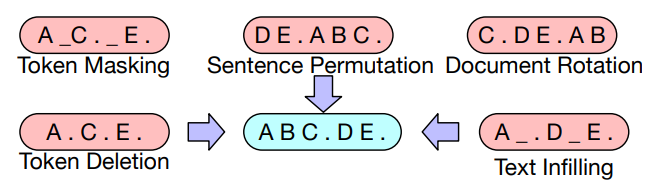

[BART에 사용된 5가지 noising 방법]

 https://arxiv.org/pdf/1910.13461.pdf

**Q. XLNET은 permutation LM을 사용하여 학습합니다. 이를 통해 얻을 수 있는 효과에 대해 이야기해봅시다.**

A. [ AR과 AE의 장점을 동시에 가질 수 있습니다. 즉, AE처럼 양방향 context를 모두 볼 수 있는 동시에, AR처럼 예측해야 할 토큰들 간의 dependency를 놓치지 않고 학습 ]

<details>
<summary>💡예시답안 확인하기💡</summary>

permutation LM을 사용함으로써 XLNET은 AR과 AE의 장점을 동시에 가질 수 있습니다. 즉, AE처럼 양방향 context를 모두 볼 수 있는 동시에, AR처럼 예측해야 할 토큰들 간의 dependency를 놓치지 않고 학습할 수 있게 됩니다.

BART에 대해 더 자세히 알아보고 싶다면 논문을 직접 읽어보고, 코드도 살펴보세요!

  - [BART: Denoising Sequence-to-Sequence Pre-training for NaturalLanguage Generation, Translation, and Comprehension](https://arxiv.org/abs/1910.13461)

<details>
<summary>코드보기</summary>
<div markdown="1">



```
class TFBartLearnedPositionalEmbedding(TFSharedEmbeddings):
    """
    This module learns positional embeddings up to a fixed maximum size. Padding ids are ignored by either offsetting
    based on padding_idx or by setting padding_idx to None and ensuring that the appropriate position ids are passed to
    the forward function.
    """

    def __init__(self, num_embeddings: int, embedding_dim: int, padding_idx: int, offset, **kwargs):
        # Bart is set up so that if padding_idx is specified then offset the embedding ids by 2
        # and adjust num_embeddings appropriately. Other models dont have this hack
        self.offset = offset
        assert padding_idx is not None, "padding_idx cannot be None"
        num_embeddings += offset
        super().__init__(num_embeddings, embedding_dim, **kwargs)

    def call(self, input_shape: tf.TensorShape, past_key_values_length: int = 0):
        """Input is expected to be of size [bsz x seqlen]."""
        bsz, seq_len = input_shape[:2]

        positions = tf.range(
            past_key_values_length, seq_len + past_key_values_length, delta=1, dtype=tf.int32, name="range"
        )
        return super().call(positions + self.offset)  # super object is not callable for some reason


class TFBartSinusoidalPositionalEmbedding(tf.keras.layers.Embedding):
    """This module produces sinusoidal positional embeddings of any length."""

    def __init__(self, num_positions: int, embedding_dim: int, **kwargs):

        if embedding_dim % 2 != 0:
            raise NotImplementedError(f"odd embedding_dim {embedding_dim} not supported")
        super().__init__(
            num_positions,
            embedding_dim,
            **kwargs,
        )

    def build(self, input_shape: tf.TensorShape):
        """
        Build shared token embedding layer Shared weights logic adapted from
        https://github.com/tensorflow/models/blob/a009f4fb9d2fc4949e32192a944688925ef78659/official/transformer/v2/embedding_layer.py#L24
        """
        super().build(input_shape)  # Instantiates self.weight so it can be loaded
        weight: np.ndarray = self._init_weight(self.input_dim, self.output_dim)
        self.set_weights([weight])  # overwrite self.weight to correct value

    @staticmethod
    def _init_weight(n_pos: int, dim: int):
        """
        Identical to the XLM create_sinusoidal_embeddings except features are not interleaved. The cos features are in
        the 2nd half of the vector. [dim // 2:]
        """
        position_enc = np.array(
            [[pos / np.power(10000, 2 * (j // 2) / dim) for j in range(dim)] for pos in range(n_pos)]
        )
        # index 0 is all zero
        position_enc[:, 0 : dim // 2] = np.sin(position_enc[:, 0::2])
        position_enc[:, dim // 2 :] = np.cos(position_enc[:, 1::2])
        # convert to tensor
        table = tf.convert_to_tensor(position_enc, dtype=tf.float32)
        tf.stop_gradient(table)
        return table

    def call(self, input_shape: tf.TensorShape, past_key_values_length: int = 0):
        """Input is expected to be of size [bsz x seqlen]."""
        bsz, seq_len = input_shape[:2]

        positions = tf.range(
            past_key_values_length, seq_len + past_key_values_length, delta=1, dtype=tf.int32, name="range"
        )
        return super().call(positions)


class TFBartAttention(tf.keras.layers.Layer):
    """Multi-headed attention from "Attention Is All You Need"""

    def __init__(
        self,
        embed_dim: int,
        num_heads: int,
        dropout: float = 0.0,
        is_decoder: bool = False,
        bias: bool = True,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim

        self.num_heads = num_heads
        self.dropout = tf.keras.layers.Dropout(dropout)
        self.head_dim = embed_dim // num_heads
        assert self.head_dim * num_heads == self.embed_dim, "embed_dim must be divisible by num_heads"
        self.scaling = self.head_dim ** -0.5
        self.is_decoder = is_decoder

        self.k_proj = tf.keras.layers.Dense(embed_dim, use_bias=bias, name="k_proj")
        self.q_proj = tf.keras.layers.Dense(embed_dim, use_bias=bias, name="q_proj")
        self.v_proj = tf.keras.layers.Dense(embed_dim, use_bias=bias, name="v_proj")
        self.out_proj = tf.keras.layers.Dense(embed_dim, use_bias=bias, name="out_proj")

    def _shape(self, tensor: tf.Tensor, seq_len: int, bsz: int):
        return tf.transpose(tf.reshape(tensor, (bsz, seq_len, self.num_heads, self.head_dim)), (0, 2, 1, 3))

    def call(
        self,
        hidden_states: tf.Tensor,
        key_value_states: Optional[tf.Tensor] = None,
        past_key_value: Optional[Tuple[Tuple[tf.Tensor]]] = None,
        attention_mask: Optional[tf.Tensor] = None,
        training=False,
    ) -> Tuple[tf.Tensor, Optional[tf.Tensor]]:
        """Input shape: Batch x Time x Channel"""

        # if key_value_states are provided this layer is used as a cross-attention layer
        # for the decoder
        is_cross_attention = key_value_states is not None
        bsz, tgt_len, embed_dim = shape_list(hidden_states)

        # get query proj
        query_states = self.q_proj(hidden_states) * self.scaling
        # get key, value proj
        if is_cross_attention and past_key_value is not None:
            # reuse k,v, cross_attentions
            key_states = past_key_value[0]
            value_states = past_key_value[1]
        elif is_cross_attention:
            # cross_attentions
            key_states = self._shape(self.k_proj(key_value_states), -1, bsz)
            value_states = self._shape(self.v_proj(key_value_states), -1, bsz)
        elif past_key_value is not None:
            # reuse k, v, self_attention
            key_states = self._shape(self.k_proj(hidden_states), -1, bsz)
            value_states = self._shape(self.v_proj(hidden_states), -1, bsz)
            key_states = tf.concat([past_key_value[0], key_states], axis=2)
            value_states = tf.concat([past_key_value[1], value_states], axis=2)
        else:
            # self_attention
            key_states = self._shape(self.k_proj(hidden_states), -1, bsz)
            value_states = self._shape(self.v_proj(hidden_states), -1, bsz)

        if self.is_decoder:
            # if cross_attention save Tuple(tf.Tensor, tf.Tensor) of all cross attention key/value_states.
            # Further calls to cross_attention layer can then reuse all cross-attention
            # key/value_states (first "if" case)
            # if uni-directional self-attention (decoder) save Tuple(tf.Tensor, tf.Tensor) of
            # all previous decoder key/value_states. Further calls to uni-directional self-attention
            # can concat previous decoder key/value_states to current projected key/value_states (third "elif" case)
            # if encoder bi-directional self-attention `past_key_value` is always `None`
            past_key_value = (key_states, value_states)

        proj_shape = (bsz * self.num_heads, -1, self.head_dim)
        query_states = tf.reshape(self._shape(query_states, tgt_len, bsz), proj_shape)
        key_states = tf.reshape(key_states, proj_shape)
        value_states = tf.reshape(value_states, proj_shape)

        src_len = shape_list(key_states)[1]
        attn_weights = tf.matmul(query_states, key_states, transpose_b=True)

        tf.debugging.assert_equal(
            shape_list(attn_weights),
            [bsz * self.num_heads, tgt_len, src_len],
            message=f"Attention weights should be of size {(bsz * self.num_heads, tgt_len, src_len)}, but is {shape_list(attn_weights)}",
        )

        if attention_mask is not None:
            tf.debugging.assert_equal(
                shape_list(attention_mask),
                [bsz, 1, tgt_len, src_len],
                message=f"Attention mask should be of size {(bsz, 1, tgt_len, src_len)}, but is {shape_list(attention_mask)}",
            )
            attn_weights = tf.reshape(attn_weights, (bsz, self.num_heads, tgt_len, src_len)) + attention_mask
            attn_weights = tf.reshape(attn_weights, (bsz * self.num_heads, tgt_len, src_len))

        attn_weights = tf.nn.softmax(attn_weights, axis=-1)

        attn_probs = self.dropout(attn_weights, training=training)

        attn_output = tf.matmul(attn_probs, value_states)

        tf.debugging.assert_equal(
            shape_list(attn_output),
            [bsz * self.num_heads, tgt_len, self.head_dim],
            message=f"`attn_output` should be of size {(bsz, self.num_heads, tgt_len, self.head_dim)}, but is {shape_list(attn_output)}",
        )

        attn_output = tf.transpose(
            tf.reshape(attn_output, (bsz, self.num_heads, tgt_len, self.head_dim)), (0, 2, 1, 3)
        )
        attn_output = tf.reshape(attn_output, (bsz, tgt_len, embed_dim))

        attn_output = self.out_proj(attn_output)
        attn_weights: tf.Tensor = tf.reshape(attn_weights, (bsz, self.num_heads, tgt_len, src_len))

        return attn_output, attn_weights, past_key_value


class TFBartEncoderLayer(tf.keras.layers.Layer):
    def __init__(self, config: BartConfig, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = config.d_model
        self.self_attn = TFBartAttention(
            self.embed_dim, config.encoder_attention_heads, dropout=config.attention_dropout, name="self_attn"
        )
        self.normalize_before = config.normalize_before
        self.self_attn_layer_norm = tf.keras.layers.LayerNormalization(epsilon=1e-5, name="self_attn_layer_norm")
        self.dropout = tf.keras.layers.Dropout(config.dropout)
        self.activation_fn = ACT2FN[config.activation_function]
        self.activation_dropout = tf.keras.layers.Dropout(config.activation_dropout)
        self.fc1 = tf.keras.layers.Dense(config.encoder_ffn_dim, name="fc1")
        self.fc2 = tf.keras.layers.Dense(self.embed_dim, name="fc2")
        self.final_layer_norm = tf.keras.layers.LayerNormalization(epsilon=1e-5, name="final_layer_norm")

    def call(self, hidden_states: tf.Tensor, attention_mask: tf.Tensor, training=False):
        """
        Args:
            hidden_states (:obj:`tf.Tensor`): input to the layer of shape `(seq_len, batch, embed_dim)`
            attention_mask (:obj:`tf.Tensor`): attention mask of size
                `(batch, 1, tgt_len, src_len)` where padding elements are indicated by very large negative values.
        """
        residual = hidden_states
        if self.normalize_before:
            hidden_states = self.self_attn_layer_norm(hidden_states)
        hidden_states, self_attn_weights, _ = self.self_attn(
            hidden_states=hidden_states, attention_mask=attention_mask
        )
        tf.debugging.assert_equal(
            shape_list(hidden_states),
            shape_list(residual),
            message=f"Self attn modified the shape of query {shape_list(residual)} to {shape_list(hidden_states)}",
        )
        hidden_states = self.dropout(hidden_states, training=training)
        hidden_states = residual + hidden_states
        if not self.normalize_before:
            hidden_states = self.self_attn_layer_norm(hidden_states)

        residual = hidden_states
        if self.normalize_before:
            hidden_states = self.final_layer_norm(hidden_states)
        hidden_states = self.activation_fn(self.fc1(hidden_states))
        hidden_states = self.activation_dropout(hidden_states, training=training)
        hidden_states = self.fc2(hidden_states)
        hidden_states = self.dropout(hidden_states, training=training)
        hidden_states = residual + hidden_states
        if not self.normalize_before:
            hidden_states = self.final_layer_norm(hidden_states)

        return hidden_states, self_attn_weights


class TFBartDecoderLayer(tf.keras.layers.Layer):
    def __init__(self, config: BartConfig, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = config.d_model
        self.self_attn = TFBartAttention(
            embed_dim=self.embed_dim,
            num_heads=config.decoder_attention_heads,
            dropout=config.attention_dropout,
            name="self_attn",
            is_decoder=True,
        )
        self.dropout = tf.keras.layers.Dropout(config.dropout)
        self.activation_fn = ACT2FN[config.activation_function]
        self.activation_dropout = tf.keras.layers.Dropout(config.activation_dropout)
        self.normalize_before = config.normalize_before

        self.self_attn_layer_norm = tf.keras.layers.LayerNormalization(epsilon=1e-5, name="self_attn_layer_norm")
        self.encoder_attn = TFBartAttention(
            self.embed_dim,
            config.decoder_attention_heads,
            dropout=config.attention_dropout,
            name="encoder_attn",
            is_decoder=True,
        )
        self.encoder_attn_layer_norm = tf.keras.layers.LayerNormalization(epsilon=1e-5, name="encoder_attn_layer_norm")
        self.fc1 = tf.keras.layers.Dense(config.decoder_ffn_dim, name="fc1")
        self.fc2 = tf.keras.layers.Dense(self.embed_dim, name="fc2")
        self.final_layer_norm = tf.keras.layers.LayerNormalization(epsilon=1e-5, name="final_layer_norm")

    def call(
        self,
        hidden_states,
        attention_mask: Optional[tf.Tensor] = None,
        encoder_hidden_states: Optional[tf.Tensor] = None,
        encoder_attention_mask: Optional[tf.Tensor] = None,
        past_key_value: Optional[Tuple[tf.Tensor]] = None,
        training=False,
    ) -> Tuple[tf.Tensor, tf.Tensor, Tuple[Tuple[tf.Tensor]]]:
        """
        Args:
            hidden_states (:obj:`tf.Tensor`): input to the layer of shape `(seq_len, batch, embed_dim)`
            attention_mask (:obj:`tf.Tensor`): attention mask of size
                `(batch, 1, tgt_len, src_len)` where padding elements are indicated by very large negative values.
            encoder_hidden_states (:obj:`tf.Tensor`): cross attention input to the layer of shape `(seq_len, batch, embed_dim)`
            encoder_attention_mask (:obj:`tf.Tensor`): encoder attention mask of size
                `(batch, 1, tgt_len, src_len)` where padding elements are indicated by very large negative values.
            past_key_value (:obj:`Tuple(tf.Tensor)`): cached past key and value projection states
        """
        residual = hidden_states
        if self.normalize_before:
            hidden_states = self.self_attn_layer_norm(hidden_states)

        # Self Attention
        # decoder uni-directional self-attention cached key/values tuple is at positions 1,2
        self_attn_past_key_value = past_key_value[:2] if past_key_value is not None else None
        # add present self-attn cache to positions 1,2 of present_key_value tuple
        hidden_states, self_attn_weights, present_key_value = self.self_attn(
            hidden_states=hidden_states,
            past_key_value=self_attn_past_key_value,
            attention_mask=attention_mask,
        )
        hidden_states = self.dropout(hidden_states, training=training)
        hidden_states = residual + hidden_states
        if not self.normalize_before:
            hidden_states = self.self_attn_layer_norm(hidden_states)

        # Cross-Attention Block
        cross_attn_present_key_value = None
        if encoder_hidden_states is not None:
            residual = hidden_states
            if self.normalize_before:
                hidden_states = self.encoder_attn_layer_norm(hidden_states)

            # cross_attn cached key/values tuple is at positions 3,4 of present_key_value tuple
            cross_attn_past_key_value = past_key_value[-2:] if past_key_value is not None else None
            hidden_states, _, cross_attn_present_key_value = self.encoder_attn(
                hidden_states=hidden_states,
                key_value_states=encoder_hidden_states,
                attention_mask=encoder_attention_mask,
                past_key_value=cross_attn_past_key_value,
            )
            hidden_states = self.dropout(hidden_states, training=training)
            hidden_states = residual + hidden_states
            if not self.normalize_before:
                hidden_states = self.encoder_attn_layer_norm(hidden_states)

            # add cross-attn to positions 3,4 of present_key_value tuple
            present_key_value = present_key_value + cross_attn_present_key_value

        # Fully Connected
        residual = hidden_states
        if self.normalize_before:
            hidden_states = self.final_layer_norm(hidden_states)
        hidden_states = self.activation_fn(self.fc1(hidden_states))
        hidden_states = self.activation_dropout(hidden_states, training=training)
        hidden_states = self.fc2(hidden_states)
        hidden_states = self.dropout(hidden_states, training=training)
        hidden_states = residual + hidden_states

        if not self.normalize_before:
            hidden_states = self.final_layer_norm(hidden_states)

        return (
            hidden_states,
            self_attn_weights,
            present_key_value,
        )
@keras_serializable
class TFBartEncoder(tf.keras.layers.Layer):
    config_class = BartConfig
    """
    Transformer encoder consisting of *config.encoder_layers* self attention layers. Each layer is a
    :class:`TFBartEncoderLayer`.

    Args:
        config: BartConfig
    """

    def __init__(self, config: BartConfig, embed_tokens: Optional[TFSharedEmbeddings] = None, **kwargs):
        super().__init__(**kwargs)
        self.config = config
        self.dropout = tf.keras.layers.Dropout(config.dropout)
        self.layerdrop = config.encoder_layerdrop
        self.embed_scale = math.sqrt(config.d_model) if config.scale_embedding else 1.0
        self.padding_idx = config.pad_token_id
        self.max_source_positions = config.max_position_embeddings

        self.embed_tokens = embed_tokens
        if config.static_position_embeddings:
            self.embed_positions = TFBartSinusoidalPositionalEmbedding(
                config.max_position_embeddings,
                config.d_model,
                name="embed_positions",
            )
        else:
            self.embed_positions = TFBartLearnedPositionalEmbedding(
                config.max_position_embeddings,
                config.d_model,
                self.padding_idx,
                config.extra_pos_embeddings,
                name="embed_positions",
            )
        self.layers = [TFBartEncoderLayer(config, name=f"layers.{i}") for i in range(config.encoder_layers)]
        self.layernorm_embedding = (
            tf.keras.layers.LayerNormalization(epsilon=1e-5, name="layernorm_embedding")
            if config.normalize_embedding
            else tf.keras.layers.Layer()
        )
        self.layer_norm = (
            tf.keras.layers.LayerNormalization(epsilon=1e-5, name="layer_norm")
            if config.add_final_layer_norm
            else None
        )

    def call(
        self,
        input_ids=None,
        inputs_embeds=None,
        attention_mask=None,
        output_attentions=None,
        output_hidden_states=None,
        return_dict=None,
        training=False,
        **kwargs,
    ):
        """
        Args:
            input_ids (:obj:`tf.Tensor` of shape :obj:`(batch_size, sequence_length)`):
                Indices of input sequence tokens in the vocabulary. Padding will be ignored by default should you
                provide it.

                Indices can be obtained using :class:`~transformers.BartTokenizer`. See
                :meth:`transformers.PreTrainedTokenizer.encode` and :meth:`transformers.PreTrainedTokenizer.__call__`
                for details.

                `What are input IDs? <../glossary.html#input-ids>`__
            attention_mask (:obj:`tf.Tensor` of shape :obj:`(batch_size, sequence_length)`, `optional`):
                Mask to avoid performing attention on padding token indices. Mask values selected in ``[0, 1]``:

                - 1 for tokens that are **not masked**,
                - 0 for tokens that are **masked**.

                `What are attention masks? <../glossary.html#attention-mask>`__
            inputs_embeds (:obj:`tf.Tensor` of shape :obj:`(batch_size, sequence_length, hidden_size)`, `optional`):
                Optionally, instead of passing :obj:`input_ids` you can choose to directly pass an embedded
                representation. This is useful if you want more control over how to convert :obj:`input_ids` indices
                into associated vectors than the model's internal embedding lookup matrix.
            output_attentions (:obj:`bool`, `optional`):
                Whether or not to return the attentions tensors of all attention layers. See ``attentions`` under
                returned tensors for more detail.
            output_hidden_states (:obj:`bool`, `optional`):
                Whether or not to return the hidden states of all layers. See ``hidden_states`` under returned tensors
                for more detail.
            return_dict (:obj:`bool`, `optional`):
                Whether or not to return a :class:`~transformers.file_utils.ModelOutput` instead of a plain tuple.
        """
        inputs = input_processing(
            func=self.call,
            config=self.config,
            input_ids=input_ids,
            attention_mask=attention_mask,
            inputs_embeds=inputs_embeds,
            output_attentions=output_attentions,
            output_hidden_states=output_hidden_states,
            return_dict=return_dict,
            training=training,
            kwargs_call=kwargs,
        )

        if inputs["input_ids"] is not None and inputs["inputs_embeds"] is not None:
            raise ValueError("You cannot specify both input_ids and inputs_embeds at the same time")
        elif inputs["input_ids"] is not None:
            input_shape = shape_list(inputs["input_ids"])
        elif inputs["inputs_embeds"] is not None:
            input_shape = shape_list(inputs["inputs_embeds"])[:-1]
        else:
            raise ValueError("You have to specify either input_ids or inputs_embeds")

        if inputs["inputs_embeds"] is None:
            inputs_embeds = self.embed_tokens(inputs["input_ids"])
        else:
            inputs_embeds = inputs["inputs_embeds"]

        inputs_embeds = inputs_embeds * self.embed_scale

        embed_pos = self.embed_positions(input_shape)
        hidden_states = inputs_embeds + embed_pos
        hidden_states = self.layernorm_embedding(hidden_states)
        hidden_states = self.dropout(hidden_states, training=inputs["training"])

        # check attention mask and invert
        if inputs["attention_mask"] is not None:
            # [bsz, seq_len] -> [bsz, 1, tgt_seq_len, src_seq_len]
            attention_mask = _expand_mask(inputs["attention_mask"])
        else:
            attention_mask = None

        encoder_states = () if inputs["output_hidden_states"] else None
        all_attentions = () if inputs["output_attentions"] else None

        # encoder layers
        for encoder_layer in self.layers:

            if inputs["output_hidden_states"]:
                encoder_states = encoder_states + (hidden_states,)
            # add LayerDrop (see https://arxiv.org/abs/1909.11556 for description)
            dropout_probability = random.uniform(0, 1)
            if inputs["training"] and (dropout_probability < self.layerdrop):  # skip the layer
                continue

            hidden_states, attn = encoder_layer(hidden_states, attention_mask)

            if inputs["output_attentions"]:
                all_attentions += (attn,)
        if self.layer_norm:
            hidden_states = self.layer_norm(hidden_states)
        if inputs["output_hidden_states"]:
            encoder_states = encoder_states + (hidden_states,)

        if not inputs["return_dict"]:
            return tuple(v for v in [hidden_states, encoder_states, all_attentions] if v is not None)
        return TFBaseModelOutput(
            last_hidden_state=hidden_states, hidden_states=encoder_states, attentions=all_attentions
        )


@keras_serializable
class TFBartDecoder(tf.keras.layers.Layer):
    config_class = BartConfig
    """
    Transformer decoder consisting of *config.decoder_layers* layers. Each layer is a :class:`TFBartDecoderLayer`

    Args:
        config: BartConfig
        embed_tokens: output embedding
    """

    def __init__(self, config: BartConfig, embed_tokens: Optional[TFSharedEmbeddings] = None, **kwargs):
        super().__init__(**kwargs)
        self.config = config
        self.padding_idx = config.pad_token_id
        self.embed_tokens = embed_tokens
        self.embed_scale = math.sqrt(config.d_model) if config.scale_embedding else 1.0
        self.layerdrop = config.decoder_layerdrop
        if config.static_position_embeddings:
            self.embed_positions = TFBartSinusoidalPositionalEmbedding(
                config.max_position_embeddings,
                config.d_model,
                name="embed_positions",
            )
        else:
            self.embed_positions = TFBartLearnedPositionalEmbedding(
                config.max_position_embeddings,
                config.d_model,
                self.padding_idx,
                config.extra_pos_embeddings,
                name="embed_positions",
            )
        self.layers = [TFBartDecoderLayer(config, name=f"layers.{i}") for i in range(config.decoder_layers)]
        self.layernorm_embedding = (
            tf.keras.layers.LayerNormalization(epsilon=1e-5, name="layernorm_embedding")
            if config.normalize_embedding
            else tf.keras.layers.Layer()
        )
        self.layer_norm = (
            tf.keras.layers.LayerNormalization(epsilon=1e-5, name="layer_norm")
            if config.add_final_layer_norm
            else None
        )

        self.dropout = tf.keras.layers.Dropout(config.dropout)
        self.do_blenderbot_90_layernorm = config.do_blenderbot_90_layernorm

    def call(
        self,
        input_ids=None,
        inputs_embeds=None,
        attention_mask=None,
        encoder_hidden_states=None,
        encoder_attention_mask=None,
        past_key_values=None,
        use_cache=None,
        output_attentions=None,
        output_hidden_states=None,
        return_dict=None,
        training=False,
        **kwargs,
    ):
        r"""
        Args:
            input_ids (:obj:`tf.Tensor` of shape :obj:`(batch_size, sequence_length)`):
                Indices of input sequence tokens in the vocabulary. Padding will be ignored by default should you
                provide it.

                Indices can be obtained using :class:`~transformers.BartTokenizer`. See
                :meth:`transformers.PreTrainedTokenizer.encode` and :meth:`transformers.PreTrainedTokenizer.__call__`
                for details.

                `What are input IDs? <../glossary.html#input-ids>`__
            attention_mask (:obj:`tf.Tensor` of shape :obj:`(batch_size, sequence_length)`, `optional`):
                Mask to avoid performing attention on padding token indices. Mask values selected in ``[0, 1]``:

                - 1 for tokens that are **not masked**,
                - 0 for tokens that are **masked**.

                `What are attention masks? <../glossary.html#attention-mask>`__
            encoder_hidden_states (:obj:`tf.Tensor` of shape :obj:`(batch_size, encoder_sequence_length, hidden_size)`, `optional`):
                Sequence of hidden-states at the output of the last layer of the encoder. Used in the cross-attention
                of the decoder.
            encoder_attention_mask (:obj:`tf.Tensor` of shape :obj:`(batch_size, encoder_sequence_length)`, `optional`):
                Mask to avoid performing cross-attention on padding tokens indices of encoder input_ids. Mask values
                selected in ``[0, 1]``:

                - 1 for tokens that are **not masked**,
                - 0 for tokens that are **masked**.

                `What are attention masks? <../glossary.html#attention-mask>`__
            past_key_values (:obj:`Tuple[Tuple[tf.Tensor]]` of length :obj:`config.n_layers` with each tuple having 2 tuples each of which has 2 tensors of shape :obj:`(batch_size, num_heads, sequence_length - 1, embed_size_per_head)`):
                Contains precomputed key and value hidden-states of the attention blocks. Can be used to speed up
                decoding.

                If :obj:`past_key_values` are used, the user can optionally input only the last
                :obj:`decoder_input_ids` (those that don't have their past key value states given to this model) of
                shape :obj:`(batch_size, 1)` instead of all :obj:`decoder_input_ids`` of shape :obj:`(batch_size,
                sequence_length)`.
            inputs_embeds (:obj:`tf.Tensor` of shape :obj:`(batch_size, sequence_length, hidden_size)`, `optional`):
                Optionally, instead of passing :obj:`input_ids` you can choose to directly pass an embedded
                representation. This is useful if you want more control over how to convert :obj:`input_ids` indices
                into associated vectors than the model's internal embedding lookup matrix.
            output_attentions (:obj:`bool`, `optional`):
                Whether or not to return the attentions tensors of all attention layers. See ``attentions`` under
                returned tensors for more detail.
            output_hidden_states (:obj:`bool`, `optional`):
                Whether or not to return the hidden states of all layers. See ``hidden_states`` under returned tensors
                for more detail.
            return_dict (:obj:`bool`, `optional`):
                Whether or not to return a :class:`~transformers.file_utils.ModelOutput` instead of a plain tuple.
        """
        inputs = input_processing(
            func=self.call,
            config=self.config,
            input_ids=input_ids,
            attention_mask=attention_mask,
            encoder_hidden_states=encoder_hidden_states,
            encoder_attention_mask=encoder_attention_mask,
            inputs_embeds=inputs_embeds,
            past_key_values=past_key_values,
            use_cache=use_cache,
            output_attentions=output_attentions,
            output_hidden_states=output_hidden_states,
            return_dict=return_dict,
            training=training,
            kwargs_call=kwargs,
        )

        if inputs["input_ids"] is not None and inputs["inputs_embeds"] is not None:
            raise ValueError("You cannot specify both decoder_input_ids and decoder_inputs_embeds at the same time")
        elif inputs["input_ids"] is not None:
            input_shape = shape_list(inputs["input_ids"])
        elif inputs["inputs_embeds"] is not None:
            input_shape = shape_list(inputs["inputs_embeds"])[:-1]
        else:
            raise ValueError("You have to specify either decoder_input_ids or decoder_inputs_embeds")

        past_key_values_length = (
            inputs["past_key_values"][0][0].shape[2] if inputs["past_key_values"] is not None else 0
        )

        # embed positions
        positions = self.embed_positions(input_shape, past_key_values_length)

        if inputs_embeds is None:
            inputs_embeds = self.embed_tokens(inputs["input_ids"])
        else:
            inputs_embeds = inputs["inputs_embeds"]

        hidden_states = inputs_embeds * self.embed_scale

        # [bsz, seq_len] -> [bsz, 1, tgt_seq_len, src_seq_len]
        combined_attention_mask = None
        if input_shape[-1] > 1:
            combined_attention_mask = _make_causal_mask(input_shape, past_key_values_length=past_key_values_length)

        if inputs["attention_mask"] is None and inputs["input_ids"] is not None and input_shape[-1] > 1:
            attention_mask = tf.cast(
                tf.math.not_equal(inputs["input_ids"], self.config.pad_token_id), inputs["input_ids"].dtype
            )
        else:
            attention_mask = tf.ones(input_shape, dtype=tf.int32)

        if attention_mask is not None and combined_attention_mask is not None:
            # [bsz, seq_len] -> [bsz, 1, tgt_seq_len, src_seq_len]
            combined_attention_mask = combined_attention_mask + _expand_mask(
                attention_mask, past_key_values_length=past_key_values_length
            )

        encoder_hidden_states = inputs["encoder_hidden_states"]
        if encoder_hidden_states is not None and inputs["encoder_attention_mask"] is not None:
            # [bsz, seq_len] -> [bsz, 1, tgt_seq_len, src_seq_len]
            encoder_attention_mask = _expand_mask(inputs["encoder_attention_mask"], tgt_len=input_shape[-1])

        if self.do_blenderbot_90_layernorm:
            hidden_states = self.layernorm_embedding(hidden_states) + positions
        else:
            hidden_states = self.layernorm_embedding(hidden_states + positions)
        hidden_states = self.dropout(hidden_states, training=inputs["training"])

        # decoder layers
        all_hidden_states = ()
        all_self_attns = ()
        present_key_values = ()
        for idx, decoder_layer in enumerate(self.layers):
            # add LayerDrop (see https://arxiv.org/abs/1909.11556 for description)
            if inputs["output_hidden_states"]:
                all_hidden_states += (hidden_states,)
            dropout_probability = random.uniform(0, 1)

            if inputs["training"] and (dropout_probability < self.layerdrop):
                continue

            past_key_value = inputs["past_key_values"][idx] if inputs["past_key_values"] is not None else None

            hidden_states, layer_self_attn, present_key_value = decoder_layer(
                hidden_states,
                attention_mask=combined_attention_mask,
                encoder_hidden_states=encoder_hidden_states,
                encoder_attention_mask=encoder_attention_mask,
                past_key_value=past_key_value,
            )

            if inputs["use_cache"]:
                present_key_values += (present_key_value,)

            if inputs["output_attentions"]:
                all_self_attns += (layer_self_attn,)

        if self.layer_norm is not None:  # same as if config.add_final_layer_norm
            hidden_states = self.layer_norm(hidden_states)

        # Convert to standard output format: (seq_len, BS, model_dim) -> (BS, seq_len, model_dim)
        if inputs["output_hidden_states"]:
            all_hidden_states += (hidden_states,)
        else:
            all_hidden_states = None

        all_self_attns = list(all_self_attns) if inputs["output_attentions"] else None

        present_key_values = (encoder_hidden_states, present_key_values) if inputs["use_cache"] else None

        if not inputs["return_dict"]:
            return hidden_states, present_key_values, all_hidden_states, all_self_attns
        else:
            return TFBaseModelOutputWithPast(
                last_hidden_state=hidden_states,
                past_key_values=present_key_values,
                hidden_states=all_hidden_states,
                attentions=all_self_attns,
            )


[DOCS]@add_start_docstrings(
    "The bare BART Model outputting raw hidden-states without any specific head on top.",
    BART_START_DOCSTRING,
)
@keras_serializable
class TFBartModel(TFBartPretrainedModel):
    base_model_prefix = "model"

    def __init__(self, config: BartConfig, *inputs, **kwargs):
        super().__init__(config, *inputs, **kwargs)
        self.shared = TFSharedEmbeddings(config.vocab_size, config.d_model, config.pad_token_id, name="model.shared")

        with tf.compat.v1.variable_scope("model.shared") as shared_abs_scope_name:
            pass

        # Wraps layer to avoid problems with weight restoring and ensuring we're in the correct TF scope.
        embed_tokens = TFWrappedEmbeddings(self.shared, abs_scope_name=shared_abs_scope_name)
        embed_tokens.vocab_size = self.shared.vocab_size
        embed_tokens.hidden_size = self.shared.hidden_size

        self.encoder = TFBartEncoder(config, embed_tokens, name="encoder")
        self.decoder = TFBartDecoder(config, embed_tokens, name="decoder")

    def get_decoder(self):
        return self.decoder

[DOCS]    @add_start_docstrings_to_model_forward(BART_INPUTS_DOCSTRING.format("batch_size, sequence_length"))
    @add_code_sample_docstrings(
        tokenizer_class=_TOKENIZER_FOR_DOC,
        checkpoint="facebook/bart-large",
        output_type=TFSeq2SeqModelOutput,
        config_class=_CONFIG_FOR_DOC,
    )
    def call(
        self,
        input_ids=None,
        attention_mask=None,
        decoder_input_ids=None,
        decoder_attention_mask=None,
        encoder_outputs: Optional[Union[Tuple, TFBaseModelOutput]] = None,
        past_key_values=None,
        inputs_embeds=None,
        decoder_inputs_embeds=None,
        use_cache=None,
        output_attentions=None,
        output_hidden_states=None,
        return_dict=None,
        training=False,
        **kwargs
    ):
        inputs = input_processing(
            func=self.call,
            config=self.config,
            input_ids=input_ids,
            attention_mask=attention_mask,
            decoder_input_ids=decoder_input_ids,
            decoder_attention_mask=decoder_attention_mask,
            encoder_outputs=encoder_outputs,
            past_key_values=past_key_values,
            inputs_embeds=inputs_embeds,
            decoder_inputs_embeds=decoder_inputs_embeds,
            use_cache=use_cache,
            output_attentions=output_attentions,
            output_hidden_states=output_hidden_states,
            return_dict=return_dict,
            training=training,
            kwargs_call=kwargs,
        )

        if inputs["decoder_input_ids"] is None and inputs["decoder_inputs_embeds"] is None:
            inputs["use_cache"] = False

        inputs["output_hidden_states"] = (
            inputs["output_hidden_states"]
            if inputs["output_hidden_states"] is not None
            else self.config.output_hidden_states
        )

        if inputs["decoder_input_ids"] is None and inputs["input_ids"] is not None:
            inputs["decoder_input_ids"] = shift_tokens_right(
                inputs["input_ids"], self.config.pad_token_id, self.config.eos_token_id
            )

        if inputs["encoder_outputs"] is None:
            inputs["encoder_outputs"] = self.encoder(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                inputs_embeds=inputs["inputs_embeds"],
                output_attentions=inputs["output_attentions"],
                output_hidden_states=inputs["output_hidden_states"],
                return_dict=inputs["return_dict"],
                training=inputs["training"],
            )
        # If the user passed a tuple for encoder_outputs, we wrap it in a TFBaseModelOutput when return_dict=True
        elif inputs["return_dict"] and not isinstance(inputs["encoder_outputs"], TFBaseModelOutput):
            inputs["encoder_outputs"] = TFBaseModelOutput(
                last_hidden_state=inputs["encoder_outputs"][0],
                hidden_states=inputs["encoder_outputs"][1] if len(inputs["encoder_outputs"]) > 1 else None,
                attentions=inputs["encoder_outputs"][2] if len(inputs["encoder_outputs"]) > 2 else None,
            )
        # If the user passed a TFBaseModelOutput for encoder_outputs, we wrap it in a tuple when return_dict=False
        elif not inputs["return_dict"] and not isinstance(inputs["encoder_outputs"], tuple):
            inputs["encoder_outputs"] = inputs["encoder_outputs"].to_tuple()

        decoder_outputs = self.decoder(
            inputs["decoder_input_ids"],
            attention_mask=decoder_attention_mask,
            encoder_hidden_states=inputs["encoder_outputs"][0],
            encoder_attention_mask=inputs["attention_mask"],
            past_key_values=inputs["past_key_values"],
            inputs_embeds=inputs["decoder_inputs_embeds"],
            use_cache=inputs["use_cache"],
            output_attentions=inputs["output_attentions"],
            output_hidden_states=inputs["output_hidden_states"],
            return_dict=inputs["return_dict"],
            training=inputs["training"],
        )

        if not inputs["return_dict"]:
            return decoder_outputs + inputs["encoder_outputs"]

        return TFSeq2SeqModelOutput(
            last_hidden_state=decoder_outputs.last_hidden_state,
            past_key_values=decoder_outputs.past_key_values,
            decoder_hidden_states=decoder_outputs.hidden_states,
            decoder_attentions=decoder_outputs.attentions,
            encoder_last_hidden_state=inputs["encoder_outputs"].last_hidden_state,
            encoder_hidden_states=inputs["encoder_outputs"].hidden_states,
            encoder_attentions=inputs["encoder_outputs"].attentions,
        )


    def get_input_embeddings(self):
        return self.shared

    def set_input_embeddings(self, value):
        self.shared = value

    def get_output_embeddings(self):
        return self.shared
```



</div>
</details>

# ALBERT(A Lite BERT for Self-supervised Learning of Language Representations)

BERT와 같은 pretrain 모델들이 이제 NLP의 대세라는 것은 잘 알았습니다. 그러나 이런 모델들은 개인의 장비에서 학습을 시키는 데에 조금 무리가 있습니다. TPU가 있다면 모를까요.

ALBERT는 '성능은 유지하면서 메모리는 적게 쓰는 좀 더 가벼운 BERT를 만들 수 없을까?'라는 질문에서부터 출발합니다.

## ALBERT의 구조
---
ALBERT의 기본 구조는 BERT를 따릅니다. 트랜스포머의 encoder를 기반으로 하며, activation function(활성화 함수)으로는 GELU를 사용하고 있죠.

더 가벼운 BERT를 만들기 위해 ALBERT는 아래의 세 가지 아이디어를 적용합니다.

**1. Factorized embedding parameterization**

BERT는 input의 token embedding(E)과 hidden layer(H)의 size가 같습니다.(E≡H) ALBERT는 E를 H보다 작게 만들어서 parameter의 수를 줄입니다.

그 이유가 무엇일까요? 왜 토큰 임베딩 사이즈(E)를 줄일까요?

저자는 BERT와 같은 모델들의 성공 요인 중 하나를 context를 반영한 임베딩에 있다고 이야기합니다. 이는 위에서 word2vec의 한계를 설명하면서 이야기했던 부분이죠.

모델의 입장에서 context를 반영하는 부분은 트랜스포머 layer(hidden layer)를 통과하는 부분들입니다. token embedding은 context와 무관한, 그저 token을 벡터화한 것에 불과하죠. 따라서, E와 H의 사이즈가 꼭 같을 필요는 없습니다. 오히려 H의 사이즈가 클수록 성능이 높아질 가능성이 있으며, E의 사이즈를 줄여도 성능과는 크게 연관이 없어 보입니다.

그러나, 무작정 E나 H의 사이즈를 변경할 수는 없습니다. BERT에서는 E와 H를 같도록(tying) 모델을 설계했기 때문이죠.

BERT에서의 임베딩 벡터는 V * H(혹은 E)의 매트릭스였습니다. 성능을 위해서라면 V도 너무 작아서는 안 됩니다. 따라서 V도, H(E)도 커지게 되면 엄청난 수의 parameter들을 가지게 됩니다. 이는 parameter를 줄이는 방법이 아니지요.

그렇다면 어떻게 효과적으로 적당한 V를 유지하면서, H는 키우고 E는 줄일 수 있을까요?

정답은 matrix factorization(행렬 분해) 에 있습니다.

V * H의 매트릭스를 V * E와 E * H의 매트릭스로 나누는 것입니다. 이런 기법은 추천 시스템 등 다양한 분야에서 널리 쓰이고 있는 기법이기도 합니다.

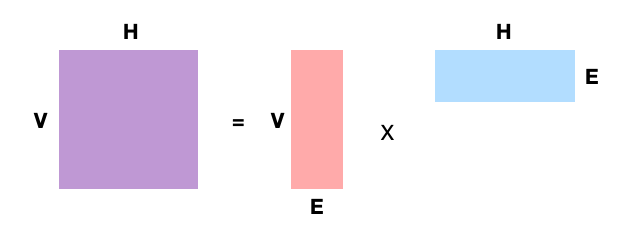

[임베딩 매트릭스의 행렬분해]

이렇게 행렬 분해를 통해 H의 사이즈는 유지한 채 E의 사이즈를 줄일 수 있습니다. 또한, parameter의 수도 줄일 수 있지요.

**2. Cross-layer parameter sharing**

parameter를 공유하는 방법은 parameter의 수를 줄이는 방법 중 하나입니다. ALBERT에서도 이 방식을 사용합니다. layer간의 모든 parameter들을 공유하는 것이죠.

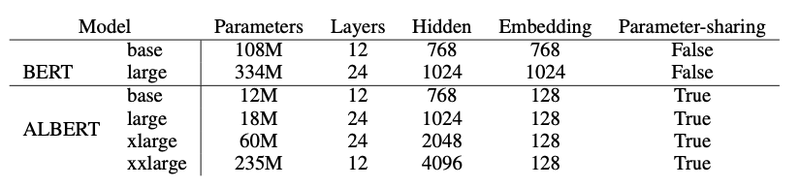

[parameter sharing의 여부에 따른 parameter의 수의 변화(출처 : https://arxiv.org/abs/1909.11942)]

그럼 어떤 layer를 어디까지 공유하는 걸까요?

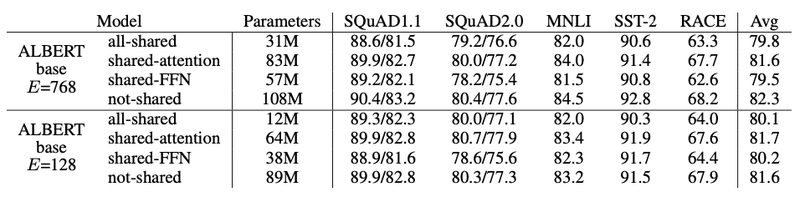

[parameter sharing의 범위에 따른 성능 변화(출처 : https://arxiv.org/abs/1909.11942)]

사실 모델이 parameter를 공유한다는 것은 일장일단(trade-off)이 있습니다. 더 많은 부분을 공유할수록 모델의 parameter의 수는 줄어들지만(경량화) 성능이 떨어질 우려가 있죠. 그럼에도 불구하고 ALBERT는 기본적으로 모든 parameter들을 공유하고 있습니다. 마치 RNN이 한 개의 hidden state를 계속 사용하는 것처럼 ALBERT는 transformer block 1개를 이용하여 재사용합니다.

**3. Inter-sentence coherence loss**

BERT는 Masked-LM(MLM) Next Sentence Prediction(NSP)을 이용하여 model을 pre-train시켰습니다.

NSP의 경우 실제 이어지는 두 문장(positive)과, 임의로 뽑은 두 문장(negative)을 구분하는 것을 학습하게 됩니다. 그러나 이렇게 임의로 뽑은 문장은 첫 번째 문장과 두 번째 문장의 topic이 매우 다를 가능성이 있습니다. 다시 말하면, NSP는 두 문장의 연관 관계 보다 두 문장의 topic 차이를 구별하는 것에 가까울 수 있다는 것입니다.

ALBERT는 이런 NSP를 과감하게 삭제하고 이를 Sentence Order Prediction(SOP)로 대체합니다. SOP는 임의로 문장을 샘플링하는 것이 아니라, 실제 두 문장의 순서를 바꾸어 학습 데이터를 만듭니다. 두 문장의 순서가 원래의 데이터의 순서와 일치한다면 positive, 순서가 원래 데이터와 반대로 되어있다면 negative이 되는 것이죠. 이러한 학습을 통해 모델은 기존의 NSP보다 훨씬 더 복잡한 언어적 사이의 연관성(논문에서는 discourse-level coherence properties라는 표현을 사용합니다)을 이해할 수 있게 되는 것입니다.

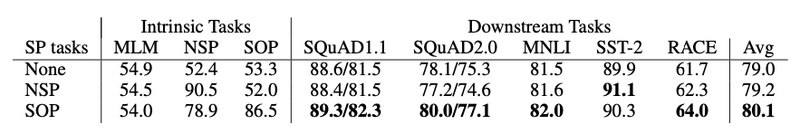

[NSP와 SOP의 성능 비교(출처 : https://arxiv.org/abs/1909.11942)]

이러한 구조들을 이용하여 ALBERT-xxlarge는 BERT-large의 약 70%의 parameter들을 가지고도 오히려 성능을 개선할 수 있게 해줍니다. 이 밖에도 논문에서는 '같은 시간은 학습한다면?' 등 다양한 실험들을 통해 여러 시사점을 주고 있습니다.

그렇다면 ALBERT의 모델 부분을 코드로 한 번 확인해 볼까요? 얼핏 BERT와 유사한 구조의 코드로 보이지만, `TFAlbertEmbeddings`의 임베딩 방식과 `TFAlbertTransformer` 안에서 group 단위로 파라미터가 재사용되는 부분을 유심히 살펴봐 주세요.

<details>
<summary>코드보기</summary>
<div markdown="1">



```

class TFAlbertEmbeddings(tf.keras.layers.Layer):
    """word, position and token_type embeddings"""

    def __init__(self, config, **kwargs):
        super().__init__(**kwargs)

        self.vocab_size = config.vocab_size
        self.embedding_size = config.embedding_size
        self.initializer_range = config.initializer_range
        self.max_position_embeddings = config.max_position_embeddings
        self.type_vocab_size = config.type_vocab_size
        self.layer_norm_eps = config.layer_norm_eps
        self.hidden_dropout_prob = config.hidden_dropout_prob

        ## Albert에서는 hidden_size가 아닌 embedding_size로 embedding을 함
        self.position_embeddings = tf.keras.layers.Embedding(
            self.max_position_embeddings,
            self.embedding_size,
            embeddings_initializer=get_initializer(self.initializer_range),
            name="position_embeddings",
        )
        self.token_type_embeddings = tf.keras.layers.Embedding(
            self.type_vocab_size,
            self.embedding_size,
            embeddings_initializer=get_initializer(self.initializer_range),
            name="token_type_embeddings",
        )

        self.LayerNorm = tf.keras.layers.LayerNormalization(epsilon=self.layer_norm_eps, name="LayerNorm")
        self.dropout = tf.keras.layers.Dropout(self.hidden_dropout_prob)

    def build(self, input_shape):
        """shared word embedding layer """
        with tf.name_scope("word_embeddings"):
            self.word_embeddings = self.add_weight(
                "weight",
                shape=[self.vocab_size, self.embedding_size],
                initializer=get_initializer(self.initializer_range),
            )
        super().build(input_shape)

    def call(
        self,
        input_ids=None,
        position_ids=None,
        token_type_ids=None,
        inputs_embeds=None,
        mode="embedding",
        training=False,
    ):
        """
        input의 token embeddings
        Args:
            inputs: int64 tensors (shape [batch_size, length]) 3개를 담은 리스트: (input_ids, position_ids, token_type_ids)
            mode: "embedding" | "linear"
        Returns:
            outputs: mode == "embedding"; output embedding tensor(float32, shape [batch_size, length, embedding_size])
										 mode == "linear", output linear tensor(float32, shape [batch_size, length, vocab_size])
        Raises:
            ValueError: if mode is not valid.
				"""

        if mode == "embedding":
            return self._embedding(input_ids, position_ids, token_type_ids, inputs_embeds, training=training)
        elif mode == "linear":
            return self._linear(input_ids)
        else:
            raise ValueError("mode {} is not valid.".format(mode))

    def _embedding(self, input_ids, position_ids, token_type_ids, inputs_embeds, training=False):
        """input tensor에 기반하여 임베딩 적용"""
        assert not (input_ids is None and inputs_embeds is None)

        if input_ids is not None:
            input_shape = shape_list(input_ids)
        else:
            input_shape = shape_list(inputs_embeds)[:-1]

        seq_length = input_shape[1]
        if position_ids is None:
            position_ids = tf.range(seq_length, dtype=tf.int32)[tf.newaxis, :]
        if token_type_ids is None:
            token_type_ids = tf.fill(input_shape, 0)

        if inputs_embeds is None:
            inputs_embeds = tf.gather(self.word_embeddings, input_ids)
        position_embeddings = self.position_embeddings(position_ids)
        token_type_embeddings = self.token_type_embeddings(token_type_ids)

        embeddings = inputs_embeds + position_embeddings + token_type_embeddings
        embeddings = self.LayerNorm(embeddings)
        embeddings = self.dropout(embeddings, training=training)
        return embeddings

    def _linear(self, inputs):
        """
 			  linear layer를 통해서 input의 logit을 계산
        Args:
            inputs: float32 tensor (shape [batch_size, length, embedding_size])
        Returns:
            float32 tensor (shape [batch_size, length, vocab_size])
        """
        batch_size = shape_list(inputs)[0]
        length = shape_list(inputs)[1]
        x = tf.reshape(inputs, [-1, self.embedding_size])
        logits = tf.matmul(x, self.word_embeddings, transpose_b=True)
        return tf.reshape(logits, [batch_size, length, self.vocab_size])


class TFAlbertSelfOutput(tf.keras.layers.Layer):
    def __init__(self, config, **kwargs):
        super().__init__(**kwargs)
        self.dense = tf.keras.layers.Dense(
            config.hidden_size, kernel_initializer=get_initializer(config.initializer_range), name="dense"
        )
        self.LayerNorm = tf.keras.layers.LayerNormalization(epsilon=config.layer_norm_eps, name="LayerNorm")
        self.dropout = tf.keras.layers.Dropout(config.hidden_dropout_prob)

    def call(self, hidden_states, input_tensor, training=False):
        hidden_states = self.dense(hidden_states)
        hidden_states = self.dropout(hidden_states, training=training)
        hidden_states = self.LayerNorm(hidden_states + input_tensor)
        return hidden_states


class TFAlbertAttention(tf.keras.layers.Layer):
    """ dropouts and layer norm을 포함한 attention layer """

    def __init__(self, config, **kwargs):
        super().__init__(**kwargs)

        self.hidden_size = config.hidden_size
        self.output_attentions = config.output_attentions
        self.num_attention_heads = config.num_attention_heads
        assert config.hidden_size % config.num_attention_heads == 0
        self.attention_head_size = int(config.hidden_size / config.num_attention_heads)
        self.all_head_size = self.num_attention_heads * self.attention_head_size
        self.query = tf.keras.layers.Dense(
            self.all_head_size, kernel_initializer=get_initializer(config.initializer_range), name="query"
        )
        self.key = tf.keras.layers.Dense(
            self.all_head_size, kernel_initializer=get_initializer(config.initializer_range), name="key"
        )
        self.value = tf.keras.layers.Dense(
            self.all_head_size, kernel_initializer=get_initializer(config.initializer_range), name="value"
        )
        self.dense = tf.keras.layers.Dense(
            config.hidden_size, kernel_initializer=get_initializer(config.initializer_range), name="dense"
        )
        self.LayerNorm = tf.keras.layers.LayerNormalization(epsilon=config.layer_norm_eps, name="LayerNorm")
        self.pruned_heads = set()
        # Two different dropout probabilities; see https://github.com/google-research/albert/blob/master/modeling.py#L971-L993
        self.attention_dropout = tf.keras.layers.Dropout(config.attention_probs_dropout_prob)
        self.output_dropout = tf.keras.layers.Dropout(config.hidden_dropout_prob)

    def transpose_for_scores(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_attention_heads, self.attention_head_size))

        return tf.transpose(x, perm=[0, 2, 1, 3])

    def prune_heads(self, heads):
        raise NotImplementedError

    def call(self, input_tensor, attention_mask, head_mask, output_attentions, training=False):
        batch_size = shape_list(input_tensor)[0]
        mixed_query_layer = self.query(input_tensor)
        mixed_key_layer = self.key(input_tensor)
        mixed_value_layer = self.value(input_tensor)

        query_layer = self.transpose_for_scores(mixed_query_layer, batch_size)
        key_layer = self.transpose_for_scores(mixed_key_layer, batch_size)
        value_layer = self.transpose_for_scores(mixed_value_layer, batch_size)

        # "query"와 "key"의 dot product : raw attention scores
        # (batch size, num_heads, seq_len_q, seq_len_k)
        attention_scores = tf.matmul(query_layer, key_layer, transpose_b=True)
        # scale attention_scores
        dk = tf.cast(shape_list(key_layer)[-1], tf.float32)
        attention_scores = attention_scores / tf.math.sqrt(dk)

        if attention_mask is not None:
            attention_scores = attention_scores + attention_mask

        # Normalize the attention scores to probabilities.
        attention_probs = tf.nn.softmax(attention_scores, axis=-1)

        attention_probs = self.attention_dropout(attention_probs, training=training)

        if head_mask is not None:
            attention_probs = attention_probs * head_mask

        context_layer = tf.matmul(attention_probs, value_layer)

        context_layer = tf.transpose(context_layer, perm=[0, 2, 1, 3])
        context_layer = tf.reshape(
            context_layer, (batch_size, -1, self.all_head_size)
        )  # (batch_size, seq_len_q, all_head_size)

        self_outputs = (context_layer, attention_probs) if output_attentions else (context_layer,)

        hidden_states = self_outputs[0]

        hidden_states = self.dense(hidden_states)
        hidden_states = self.output_dropout(hidden_states, training=training)
        attention_output = self.LayerNorm(hidden_states + input_tensor)

        outputs = (attention_output,) + self_outputs[1:]

        return outputs


class TFAlbertLayer(tf.keras.layers.Layer):
    def __init__(self, config, **kwargs):
        super().__init__(**kwargs)
        self.attention = TFAlbertAttention(config, name="attention")

        self.ffn = tf.keras.layers.Dense(
            config.intermediate_size, kernel_initializer=get_initializer(config.initializer_range), name="ffn"
        )

        if isinstance(config.hidden_act, str):
            self.activation = get_tf_activation(config.hidden_act)
        else:
            self.activation = config.hidden_act

        self.ffn_output = tf.keras.layers.Dense(
            config.hidden_size, kernel_initializer=get_initializer(config.initializer_range), name="ffn_output"
        )
        self.full_layer_layer_norm = tf.keras.layers.LayerNormalization(
            epsilon=config.layer_norm_eps, name="full_layer_layer_norm"
        )
        self.dropout = tf.keras.layers.Dropout(config.hidden_dropout_prob)

    def call(self, hidden_states, attention_mask, head_mask, output_attentions, training=False):
        attention_outputs = self.attention(
            hidden_states, attention_mask, head_mask, output_attentions, training=training
        )
        ffn_output = self.ffn(attention_outputs[0])
        ffn_output = self.activation(ffn_output)
        ffn_output = self.ffn_output(ffn_output)
        ffn_output = self.dropout(ffn_output, training=training)

        hidden_states = self.full_layer_layer_norm(ffn_output + attention_outputs[0])

        outputs = (hidden_states,) + attention_outputs[1:]
        return outputs


class TFAlbertLayerGroup(tf.keras.layers.Layer):
    def __init__(self, config, **kwargs):
        super().__init__(**kwargs)

        self.output_attentions = config.output_attentions
        self.output_hidden_states = config.output_hidden_states
        self.albert_layers = [
            TFAlbertLayer(config, name="albert_layers_._{}".format(i)) for i in range(config.inner_group_num)
        ]

    def call(self, hidden_states, attention_mask, head_mask, output_attentions, output_hidden_states, training=False):
        layer_hidden_states = ()
        layer_attentions = ()

        for layer_index, albert_layer in enumerate(self.albert_layers):
            layer_output = albert_layer(
                hidden_states, attention_mask, head_mask[layer_index], output_attentions, training=training
            )
            hidden_states = layer_output[0]

            if output_attentions:
                layer_attentions = layer_attentions + (layer_output[1],)

            if output_hidden_states:
                layer_hidden_states = layer_hidden_states + (hidden_states,)

        outputs = (hidden_states,)
        if output_hidden_states:
            outputs = outputs + (layer_hidden_states,)
        if output_attentions:
            outputs = outputs + (layer_attentions,)
        # last-layer hidden state, (layer hidden states), (layer attentions)
        return outputs


class TFAlbertTransformer(tf.keras.layers.Layer):
    def __init__(self, config, **kwargs):
        super().__init__(**kwargs)

        self.num_hidden_layers = config.num_hidden_layers
        self.num_hidden_groups = config.num_hidden_groups
        self.embedding_hidden_mapping_in = tf.keras.layers.Dense(
            config.hidden_size,
            kernel_initializer=get_initializer(config.initializer_range),
            name="embedding_hidden_mapping_in",
        )
        self.albert_layer_groups = [
            TFAlbertLayerGroup(config, name="albert_layer_groups_._{}".format(i))
            for i in range(config.num_hidden_groups)
        ]

    def call(
        self,
        hidden_states,
        attention_mask,
        head_mask,
        output_attentions,
        output_hidden_states,
        return_dict,
        training=False,
    ):
        hidden_states = self.embedding_hidden_mapping_in(hidden_states)
        all_attentions = () if output_attentions else None
        all_hidden_states = (hidden_states,) if output_hidden_states else None

        for i in range(self.num_hidden_layers):
            # Number of layers in a hidden group
            layers_per_group = int(self.num_hidden_layers / self.num_hidden_groups)

            # Index of the hidden group
            group_idx = int(i / (self.num_hidden_layers / self.num_hidden_groups))

            layer_group_output = self.albert_layer_groups[group_idx](
                hidden_states,
                attention_mask,
                head_mask[group_idx * layers_per_group : (group_idx + 1) * layers_per_group],
                output_attentions,
                output_hidden_states,
                training=training,
            )
            hidden_states = layer_group_output[0]

            if output_attentions:
                all_attentions = all_attentions + layer_group_output[-1]

            if output_hidden_states:
                all_hidden_states = all_hidden_states + (hidden_states,)

        if not return_dict:
            return tuple(v for v in [hidden_states, all_hidden_states, all_attentions] if v is not None)
        return TFBaseModelOutput(
            last_hidden_state=hidden_states, hidden_states=all_hidden_states, attentions=all_attentions
        )

@keras_serializable
class TFAlbertMainLayer(tf.keras.layers.Layer):
"""
모델의 전체구조
"""
    config_class = AlbertConfig

    def __init__(self, config, **kwargs):
        super().__init__(**kwargs)
        self.num_hidden_layers = config.num_hidden_layers
        self.output_attentions = config.output_attentions
        self.output_hidden_states = config.output_hidden_states
        self.return_dict = config.use_return_dict

        self.embeddings = TFAlbertEmbeddings(config, name="embeddings")
        self.encoder = TFAlbertTransformer(config, name="encoder")
        self.pooler = tf.keras.layers.Dense(
            config.hidden_size,
            kernel_initializer=get_initializer(config.initializer_range),
            activation="tanh",
            name="pooler",
        )

    def get_input_embeddings(self):
        return self.embeddings

    def set_input_embeddings(self, value):
        self.embeddings.word_embeddings = value
        self.embeddings.vocab_size = value.shape[0]

    def _resize_token_embeddings(self, new_num_tokens):
        raise NotImplementedError

    def _prune_heads(self, heads_to_prune):
        raise NotImplementedError

    def call(
        self,
        inputs,
        attention_mask=None,
        token_type_ids=None,
        position_ids=None,
        head_mask=None,
        inputs_embeds=None,
        output_attentions=None,
        output_hidden_states=None,
        return_dict=None,
        training=False,
    ):
        if isinstance(inputs, (tuple, list)):
            input_ids = inputs[0]
            attention_mask = inputs[1] if len(inputs) > 1 else attention_mask
            token_type_ids = inputs[2] if len(inputs) > 2 else token_type_ids
            position_ids = inputs[3] if len(inputs) > 3 else position_ids
            head_mask = inputs[4] if len(inputs) > 4 else head_mask
            inputs_embeds = inputs[5] if len(inputs) > 5 else inputs_embeds
            output_attentions = inputs[6] if len(inputs) > 6 else output_attentions
            output_hidden_states = inputs[7] if len(inputs) > 7 else output_hidden_states
            return_dict = inputs[8] if len(inputs) > 8 else return_dict
            assert len(inputs) <= 9, "Too many inputs."
        elif isinstance(inputs, (dict, BatchEncoding)):
            input_ids = inputs.get("input_ids")
            attention_mask = inputs.get("attention_mask", attention_mask)
            token_type_ids = inputs.get("token_type_ids", token_type_ids)
            position_ids = inputs.get("position_ids", position_ids)
            head_mask = inputs.get("head_mask", head_mask)
            inputs_embeds = inputs.get("inputs_embeds", inputs_embeds)
            output_attentions = inputs.get("output_attentions", output_attentions)
            output_hidden_states = inputs.get("output_hidden_states", output_hidden_states)
            return_dict = inputs.get("return_dict", return_dict)
            assert len(inputs) <= 9, "Too many inputs."
        else:
            input_ids = inputs

        output_attentions = output_attentions if output_attentions is not None else self.output_attentions
        output_hidden_states = output_hidden_states if output_hidden_states is not None else self.output_hidden_states
        return_dict = return_dict if return_dict is not None else self.return_dict

        if input_ids is not None and inputs_embeds is not None:
            raise ValueError("You cannot specify both input_ids and inputs_embeds at the same time")
        elif input_ids is not None:
            input_shape = shape_list(input_ids)
        elif inputs_embeds is not None:
            input_shape = shape_list(inputs_embeds)[:-1]
        else:
            raise ValueError("You have to specify either input_ids or inputs_embeds")

        if attention_mask is None:
            attention_mask = tf.fill(input_shape, 1)
        if token_type_ids is None:
            token_type_ids = tf.fill(input_shape, 0)

        # 3D attention mask 만들기
        # Sizes : [batch_size, 1, 1, to_seq_length]
        # 3D attention mask를 [batch_size, num_heads, from_seq_length, to_seq_length]로 브로드캐스팅

        extended_attention_mask = attention_mask[:, tf.newaxis, tf.newaxis, :]

				# attention_mask가 1.0이면 포함, 0.0이면 미포함 하여 attention 계산
        extended_attention_mask = tf.cast(extended_attention_mask, tf.float32)
        extended_attention_mask = (1.0 - extended_attention_mask) * -10000.0

        # head_mask가 1.0이면, head를 유지
        # attention_probs : shape bsz x n_heads x N x N
        # input head_mask : shape [num_heads] 또는 [num_hidden_layers x num_heads]
        # head_mask : shape [num_hidden_layers x batch x num_heads x seq_length x seq_length
        if head_mask is not None:
            raise NotImplementedError
        else:
            head_mask = [None] * self.num_hidden_layers
            # head_mask = tf.constant([0] * self.num_hidden_layers)

        embedding_output = self.embeddings(input_ids, position_ids, token_type_ids, inputs_embeds, training=training)
        encoder_outputs = self.encoder(
            embedding_output,
            extended_attention_mask,
            head_mask,
            output_attentions,
            output_hidden_states,
            return_dict,
            training=training,
        )

        sequence_output = encoder_outputs[0]
        pooled_output = self.pooler(sequence_output[:, 0])

        if not return_dict:
            return (
                sequence_output,
                pooled_output,
            ) + encoder_outputs[1:]

        return TFBaseModelOutputWithPooling(
            last_hidden_state=sequence_output,
            pooler_output=pooled_output,
            hidden_states=encoder_outputs.hidden_states,
            attentions=encoder_outputs.attentions,
        )
```


</div>
</details>

더 자세히 알아보고 싶다면 ALBERT의 논문을 직접 읽어보세요!

  - [ALBERT: A Lite BERT for Self-supervised Learning of Language Representations](https://arxiv.org/abs/1909.11942)

**Q. ALBERT에 사용된 방법 중, 연산가능한 파라미터의 수를 줄여준 것은 무엇이었나요?**

A. [ Factorized embedding parameterization을 통해 임베딩 벡터의 크기가 축소되고, parameter sharing은 서로 레이어들이 각자만의 파라미터를 갖지 않고 하나를 공유하게끔 하기 때문이죠. Sentence Order Prediction(SOP) task를 통한 inter-sentence coherence loss 기법은 파라미터를 줄이는 것이 아닌, 학습 방식을 바꾸는 것을! ]

<details>
<summary>💡예시답안 확인하기💡</summary>

ALBERT에 사용된 기법 세 가지 중 파라미터가 감소한 원인은 **factorized embedding parameterization**과 **cross-layer parameter sharing** 두 가지 입니다. Factorized embedding parameterization을 통해 임베딩 벡터의 크기가 축소되고, parameter sharing은 서로 레이어들이 각자만의 파라미터를 갖지 않고 하나를 공유하게끔 하기 때문이죠. Sentence Order Prediction(SOP) task를 통한 inter-sentence coherence loss 기법은 파라미터를 줄이는 것이 아닌, 학습 방식을 바꾸는 것을 의미합니다.

# T5(Text-to-Text Transfer Transformer)

2020년 2월 발표된 T5는 Text-to-Text Transfer Transformer의 약자입니다. T가 5개라서 T5라고 불린다고 하니 구글의 작명 실력을 알만하죠? 😆

T5는 Transformer를 기반으로 만들어진 아키텍처로 text-to-text 방법을 사용합니다. BERT와 차이점을 몇 개 볼 수 있는데요, 우선 causal decoder를 bidirectional architecture에 추가하였고, pre-training tasks를 fill-in-the-blank cloze task로 대체했다는 것입니다. 혹시 fill-in-the-blank cloze task가 무엇인지 궁금하신가요? 여러분도 이 문제를 영어 시간이나 국어 시간에 많이 접했을 것입니다. 바로 빈칸 채우기이죠. 아래와 같이 빈칸이 주어지면 그 빈칸을 채우는 문제입니다.



```
Lions are the ___________________ living animal in the world.
```
인간인 우리도 풀기 힘든 문제일 수도 있는데, T5는 이 문제를 정말 잘 풀었다고 합니다. 그럼 T5에 대해 본격적으로 알아볼까요?




C4
---
사실 T5를 소개한 논문 'Exploring the Limits of Transfer Learning with a Unified Text-to-Text Transformer'은 어떤 전이학습이 더 효과적인지 결정하기 위한 대규모의 서베이 논문입니다. 서베이에서 얻은 인사이트를 통해 T5라는 모델을 만들었죠. 이 논문에서는 모델만 소개한 것이 아니라 [Colossal Clean Crawled Corpus(C4)](https://www.tensorflow.org/datasets/catalog/c4?hl=ko)라 불리는 open-source pre-training dataset을 소개하기도 하였습니다. T5와 C4를 가지고 fine-tuning을 하면 다양한 downstream task에 적용할 수 있다고 하네요.

전이학습을 할 때 사용되는 데이터셋은 굉장히 중요합니다. 데이터셋에 따라 사전학습된 모델의 성능이 천차만별일 수도 있습니다. 그러나 기존의 데이터셋은 고품질, 다양성, 많은 양이라는 좋은 데이터셋의 조건을 만족하지 못했어요. 그래서 T5를 만든 저자들은 3가지 조건을 만족하는 데이터셋인 C4를 만들었습니다.

C4는 Wikipedia보다 2배 많은 양이고, 중복된 데이터, 불완전한 문장, 혐오 표현이나 의미 없는 내용은 제거하였습니다. 그래서 downstream task에서 좋은 결과를 얻을 수 있고, overfitting 없이 모델 사이즈를 증가시킬 수 있습니다.

Shared Text-To-Text Framework
---
T5에서는 모든 NLP task를 입력과 출력이 모두 text string인 text-to-text format으로 재구성하였습니다. 아래의 이미지는 text-to-text framework를 나타낸 것으로, text를 입력으로 하여 모델에 넣으면 결과가 text로 나오는 것을 보여줍니다. 참고로 녹색은 번역, 빨간색은 CoLA 태스크(문법 적합성), 노란색은 문장 유사성, 파란색은 문서 요약입니다.

이런 과정을 통해서 어떤 NLP task에서든 모델, 학습 과정, 디코딩 과정, 손실함수, 하이퍼파라미터를 동일하게 사용할 수 있죠.

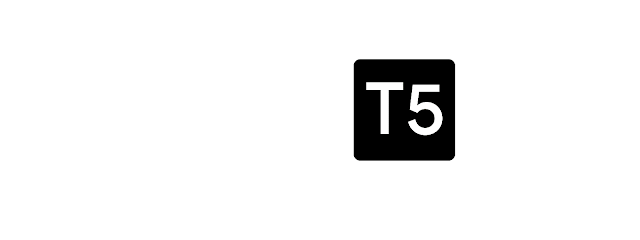

https://1.bp.blogspot.com/-o4oiOExxq1s/Xk26XPC3haI/AAAAAAAAFU8/NBlvOWB84L0PTYy9TzZBaLf6fwPGJTR0QCLcBGAsYHQ/s640/image3.gif

모두 동일한 것을 사용한다면 T5는 다른 NLP 문제를 어떻게 구분할 수 있을까요? 이에 대한 해답은 입력 형식에 있습니다.



```
예1 영-독 번역
입력 - “translate English to German: That is good.”
출력 - “Das ist gut.”

예2 MNLI benchmark
입력 - “mnli premise: I hate pigeons. hypothesis: My feelings towards pigeons are filled with animosity.”
출력 - “entailment”
```

위의 예에서와 같이 **task-specific(text) prefix**를 입력 시퀀스 앞에 추가해 모델에 넣어주는 겁니다.

Modified MLM
---
T5은 입력에 corrupted token을 넣어 더 좋은 성능을 낼 수 있도록 하였습니다. 이를 **denoising objectives**라고 하는데요, 이는 T5에서만 사용한 것이 아니라 BART 등 다른 모델에서도 흔히 사용하는 방법이었죠?

T5는 타겟을 랜덤으로 샘플링하고, 입력 시퀀스의 15%의 token을 single sentinel token($<X>, <Y>$)로 대체하였습니다. 각 sentinel token은 어떤 wordpiece에도 대응되지 않는 특별한 토큰으로, 시퀀스에 유일한 토큰 ID로 지정되어 voca에 추가됩니다. 또한 연속된 단어는 하나의 sentinel token로 여겨집니다.

타켓 토큰은 입력에서 사용된 sentinel token과 final sentinel token($<Z>$)입니다. 이를 시각화하면 아래와 같습니다.

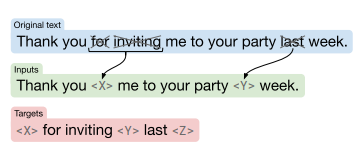

[denoising objectives]

 https://arxiv.org/pdf/1910.10683v3.pdf

모델 아키텍처
---
T5와 다른 트랜스포머 계열 모델과 다른 점 중 하나는 어텐션 매커니즘에 의해 사용되는 mask가 다르다는 것입니다. 아래 그림은 attention mask 패턴을 나타낸 것입니다.

가장 왼쪽 그림은 모든 출력 time step에서 모든 입력을 고려하는 self-attention 메커니즘으로, encoder-decoder Transformer나 BERT에서 사용하는 마스킹 방법이고, 가운데 그림은 i번째 출력 요소가 미래의 입력에 의존하지 못하도록 하는 마스킹 방법입니다. T5에서는 앞의 두 방법이 아니라 fully-visible 마스킹을 입력 시퀀스의 일부에 사용하는 causal masking with prefix라는 마스킹 방법을 사용합니다.

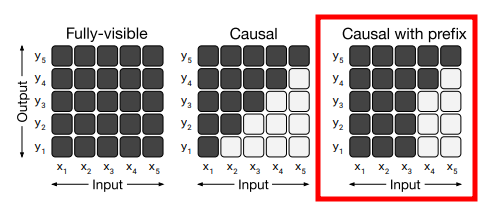

[causal masking with a prefix]

 https://arxiv.org/pdf/1910.10683v3.pdf

**Q. 위 그림의 "Causal with prefix"이 일반적인 causal 마스킹 방법과 다른 이유를 설명해봅시다.**

A. [ 답변을 적어볼까요! ]

<details>
<summary>💡예시답안 확인하기💡</summary>

일반 Causal 마스킹은 출력 값 yn을 만들기 위해 x1 부터 xn까지 활용하지만, 앞서 설명한 task-specific prefix를 사용할 경우 prefix의 일부가 가려지면 task에 전혀 맞지 않는 엉뚱한 내용을 출력하게 되겠죠. 가령 prefix가 `"translate English to German"`일 때 뒤의 일부 토큰이 가려지면 `"translate English to _"`와 같은 시퀀스를 모델이 받게 되고, 황당한 결과가 나오게 됩니다. 그러므로 prefix 손실을 막기 위해 오른쪽 그림과 같은 마스킹 방법을 사용하는 것이죠.

다른 모델과 T5의 또다른 차이점은 Transformer 아키텍처에요. 아래의 그림에서 block은 시퀀스이고, 선은 attention입니다. 진한 선은 fully-visible masking이고, 연한 선은 causal masking을 나타내죠. T5는 오른쪽과 같이 언어모델에 prefix를 추가해 입력에 fully-visible masking할 수 있도록 하였습니다. 즉 encoder에는 양방향 attention을, decoder(generation)에서는 단방향 attention을 사용하는 거죠.

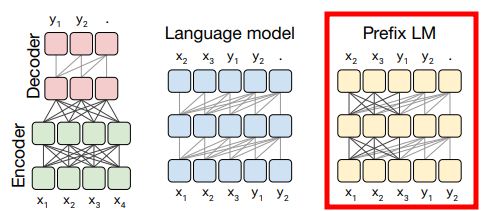

[prefix ML]  
https://arxiv.org/pdf/1910.10683v3.pdf

새로운 task
---
T5 모델은 2가지 새로운 task를 학습하였습니다. 그 중 하나는 **Closed-Book Question Answering**이라는 것인데요, 이는 어떤 외부 지식에도 접근하지 않고 사전 학습 중 얻은 파라미터에 저장된 정보만 사용해서 질문에 답하는 것입니다.

아래 그림에서 <M>이라는 부분을 T5가 내재된 지식에 의존해서 답을 하게 하였습니다. 그리고 그 결과는...??

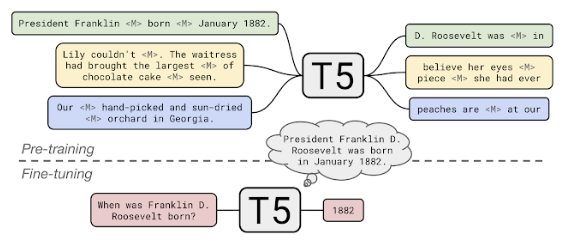

정말 놀랍게도 T5는 이 문제를 잘 해결했습니다. TriviaQA, WebQuestions, Natural Question에 각각 50.1%, 37.4%, 34.5% 정도의 답을 정확한 텍스트로 출력했어요.

T5 연구팀이 직접 이 문제를 가지고 T5와 정면도전했지만 졌다고 하네요. 😂 T5 연구팀과 T5의 흥미진진한 대결을 한번 살펴보시죠!

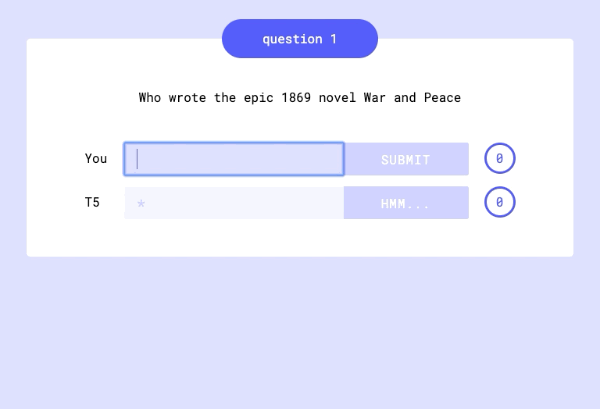

https://1.bp.blogspot.com/-SllNg6Q4DEE/Xk7ZRCtzXaI/AAAAAAAAFVY/PaaM-FEgyFIdSn7VeT_XhvG9PXQdSC3_wCLcBGAsYHQ/s640/t5-trivia-lrg.gif

T5가 학습한 새로운 task 중 또다른 하나는 **fill-in-the blank task**였습니다. 바로 빈칸 채우기인데요, 특이하게도 빈칸에 들어갈 단어의 수가 달라지면 결과도 다르게 나옵니다. 신기하지 않나요?

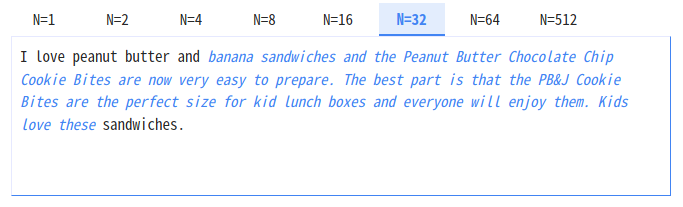

T5가 어떻게 위의 두 문제를 풀었는지 궁금하다면 아래의 링크를 참고하세요.

  - [Exploring Transfer Learning with T5: the Text-To-Text Transfer Transformer](https://research.google/blog/exploring-transfer-learning-with-t5-the-text-to-text-transfer-transformer/)

그렇다면 T5의 모델 부분을 코드로 한 번 확인해 볼까요?

<details>
<summary>코드보기</summary>
<div markdown="1">



```
class TFT5LayerNorm(tf.keras.layers.Layer):
    def __init__(self, epsilon=1e-6, **kwargs):
        """
        Construct a layernorm module in the T5 style No bias and no subtraction of mean.
        """
        super().__init__(**kwargs)
        self.variance_epsilon = epsilon

    def build(self, input_shape):
        """Build shared word embedding layer"""
        self.weight = self.add_weight("weight", shape=(input_shape[-1],), initializer="ones")
        super().build(input_shape)

    def call(self, hidden_states):
        variance = tf.math.reduce_mean(tf.math.square(hidden_states), axis=-1, keepdims=True)
        hidden_states = hidden_states * tf.math.rsqrt(variance + self.variance_epsilon)
        return self.weight * hidden_states


class TFT5DenseReluDense(tf.keras.layers.Layer):
    def __init__(self, config, **kwargs):
        super().__init__(**kwargs)
        self.wi = tf.keras.layers.Dense(config.d_ff, use_bias=False, name="wi")
        self.wo = tf.keras.layers.Dense(config.d_model, use_bias=False, name="wo")
        self.dropout = tf.keras.layers.Dropout(config.dropout_rate)
        self.act = tf.keras.activations.relu

    def call(self, hidden_states, training=False):
        hidden_states = self.wi(hidden_states)
        hidden_states = self.act(hidden_states)
        hidden_states = self.dropout(hidden_states, training=training)
        hidden_states = self.wo(hidden_states)
        return hidden_states


class TFT5GatedGeluDense(tf.keras.layers.Layer):
    def __init__(self, config, **kwargs):
        super().__init__(**kwargs)
        self.wi_0 = tf.keras.layers.Dense(config.d_ff, use_bias=False, name="wi_0")
        self.wi_1 = tf.keras.layers.Dense(config.d_ff, use_bias=False, name="wi_1")
        self.wo = tf.keras.layers.Dense(config.d_model, use_bias=False, name="wo")
        self.dropout = tf.keras.layers.Dropout(config.dropout_rate)
        self.act = get_tf_activation("gelu_new")

    def call(self, hidden_states, training=False):
        hidden_gelu = self.act(self.wi_0(hidden_states))
        hidden_linear = self.wi_1(hidden_states)
        hidden_states = hidden_gelu * hidden_linear
        hidden_states = self.dropout(hidden_states, training=training)
        hidden_states = self.wo(hidden_states)
        return hidden_states


class TFT5LayerFF(tf.keras.layers.Layer):
    def __init__(self, config, **kwargs):
        super().__init__(**kwargs)
        if config.feed_forward_proj == "relu":
            self.DenseReluDense = TFT5DenseReluDense(config, name="DenseReluDense")
        elif config.feed_forward_proj == "gated-gelu":
            self.DenseReluDense = TFT5GatedGeluDense(config, name="DenseReluDense")
        else:
            raise ValueError(
                f"{self.config.feed_forward_proj} is not supported. Choose between `relu` and `gated-gelu`"
            )
        self.layer_norm = TFT5LayerNorm(epsilon=config.layer_norm_epsilon, name="layer_norm")
        self.dropout = tf.keras.layers.Dropout(config.dropout_rate)

    def call(self, hidden_states, training=False):
        normed_hidden_states = self.layer_norm(hidden_states)
        dense_output = self.DenseReluDense(normed_hidden_states, training=training)
        hidden_states = hidden_states + self.dropout(dense_output, training=training)
        return hidden_states


class TFT5Attention(tf.keras.layers.Layer):
    NEW_ID = itertools.count()

    def __init__(self, config, has_relative_attention_bias=False, **kwargs):
        super().__init__(**kwargs)
        self.layer_id = next(TFT5Attention.NEW_ID)
        self.is_decoder = config.is_decoder
        self.use_cache = config.use_cache
        self.has_relative_attention_bias = has_relative_attention_bias
        self.output_attentions = config.output_attentions

        self.relative_attention_num_buckets = config.relative_attention_num_buckets
        self.d_model = config.d_model
        self.key_value_proj_dim = config.d_kv
        self.n_heads = config.num_heads
        self.inner_dim = self.n_heads * self.key_value_proj_dim

        # Mesh TensorFlow initialization to avoid scaling before softmax
        self.q = tf.keras.layers.Dense(self.inner_dim, use_bias=False, name="q")
        self.k = tf.keras.layers.Dense(self.inner_dim, use_bias=False, name="k")
        self.v = tf.keras.layers.Dense(self.inner_dim, use_bias=False, name="v")
        self.o = tf.keras.layers.Dense(self.d_model, use_bias=False, name="o")
        self.dropout = tf.keras.layers.Dropout(config.dropout_rate)

        self.pruned_heads = set()

    def build(self, input_shape):
        if self.has_relative_attention_bias:
            with tf.name_scope("relative_attention_bias"):
                self.relative_attention_bias = self.add_weight(
                    name="embeddings",
                    shape=[self.relative_attention_num_buckets, self.n_heads],
                )

        return super().build(input_shape)

    def prune_heads(self, heads):
        raise NotImplementedError

    @staticmethod
    def _relative_position_bucket(relative_position, bidirectional=True, num_buckets=32, max_distance=128):
        """
        Adapted from Mesh Tensorflow:
        https://github.com/tensorflow/mesh/blob/0cb87fe07da627bf0b7e60475d59f95ed6b5be3d/mesh_tensorflow/transformer/transformer_layers.py#L593

        Translate relative position to a bucket number for relative attention. The relative position is defined as
        memory_position - query_position, i.e. the distance in tokens from the attending position to the attended-to
        position. If bidirectional=False, then positive relative positions are invalid. We use smaller buckets for
        small absolute relative_position and larger buckets for larger absolute relative_positions. All relative
        positions >=max_distance map to the same bucket. All relative positions <=-max_distance map to the same bucket.
        This should allow for more graceful generalization to longer sequences than the model has been trained on

        Args:
            relative_position: an int32 Tensor
            bidirectional: a boolean - whether the attention is bidirectional
            num_buckets: an integer
            max_distance: an integer

        Returns:
            a Tensor with the same shape as relative_position, containing int32 values in the range [0, num_buckets)
        """
        relative_buckets = 0
        #        n = -relative_position
        if bidirectional:
            num_buckets //= 2
            relative_buckets += (
                tf.cast(tf.math.greater(relative_position, 0), dtype=relative_position.dtype) * num_buckets
            )
            relative_position = tf.math.abs(relative_position)
        else:
            relative_position = -tf.math.minimum(relative_position, 0)
        # now n is in the range [0, inf)
        max_exact = num_buckets // 2
        is_small = tf.math.less(relative_position, max_exact)
        relative_position_if_large = max_exact + tf.cast(
            tf.math.log(relative_position / max_exact)
            / math.log(max_distance / max_exact)
            * (num_buckets - max_exact),
            dtype=relative_position.dtype,
        )
        relative_position_if_large = tf.math.minimum(relative_position_if_large, num_buckets - 1)
        relative_buckets += tf.where(is_small, relative_position, relative_position_if_large)
        return relative_buckets

    def compute_bias(self, query_length, key_length):
        """Compute binned relative position bias"""
        context_position = tf.range(query_length)[:, None]
        memory_position = tf.range(key_length)[None, :]
        relative_position = memory_position - context_position  # shape (query_length, key_length)
        relative_position_bucket = self._relative_position_bucket(
            relative_position,
            bidirectional=(not self.is_decoder),
            num_buckets=self.relative_attention_num_buckets,
        )
        values = tf.gather(
            self.relative_attention_bias, relative_position_bucket
        )  # shape (query_length, key_length, num_heads)
        values = tf.expand_dims(
            tf.transpose(values, [2, 0, 1]), axis=0
        )  # shape (1, num_heads, query_length, key_length)
        return values

    def call(
        self,
        hidden_states,
        mask=None,
        key_value_states=None,
        position_bias=None,
        past_key_value=None,
        layer_head_mask=None,
        query_length=None,
        use_cache=False,
        training=False,
        output_attentions=False,
    ):
        """
        Self-attention (if key_value_states is None) or attention over source sentence (provided by key_value_states).
        """
        # Input is (batch_size, query_length, dim)
        # Mask is (batch_size, key_length) (non-causal) or (batch_size, key_length, key_length)
        # past_key_value[0] is (batch_size, n_heads, q_len - 1, dim_per_head)
        batch_size, seq_length = shape_list(hidden_states)[:2]

        real_seq_length = seq_length

        if past_key_value is not None:
            assert (
                len(past_key_value) == 2
            ), f"past_key_value should have 2 past states: keys and values. Got {len(past_key_value)} past states"
            real_seq_length += shape_list(past_key_value[0])[2] if query_length is None else query_length

        key_length = real_seq_length if key_value_states is None else shape_list(key_value_states)[1]

        def shape(hidden_states):
            """projection"""
            return tf.transpose(
                tf.reshape(hidden_states, (batch_size, -1, self.n_heads, self.key_value_proj_dim)), perm=(0, 2, 1, 3)
            )

        def unshape(hidden_states):
            """compute context"""
            return tf.reshape(tf.transpose(hidden_states, perm=(0, 2, 1, 3)), (batch_size, -1, self.inner_dim))

        def project(hidden_states, proj_layer, key_value_states, past_key_value):
            """projects hidden states correctly to key/query states"""
            if key_value_states is None:
                # self-attn
                # (batch_size, n_heads, seq_length, dim_per_head)
                hidden_states = shape(proj_layer(hidden_states))
            elif past_key_value is None:
                # cross-attn
                # (batch_size, n_heads, seq_length, dim_per_head)
                hidden_states = shape(proj_layer(key_value_states))

            if past_key_value is not None:
                if key_value_states is None:
                    # self-attn
                    # (batch_size, n_heads, key_length, dim_per_head)
                    hidden_states = tf.concat([past_key_value, hidden_states], axis=2)
                else:
                    # cross-attn
                    hidden_states = past_key_value
            return hidden_states

        # get query
        query_states = shape(self.q(hidden_states))  # (batch_size, n_heads, query_length, dim_per_head)

        # get key/value
        key_states = project(
            hidden_states, self.k, key_value_states, past_key_value[0] if past_key_value is not None else None
        )
        value_states = project(
            hidden_states, self.v, key_value_states, past_key_value[1] if past_key_value is not None else None
        )

        # to cope with keras serialization
        if self.is_decoder and use_cache:
            present_key_value_state = (key_states, value_states)
        else:
            present_key_value_state = None

        scores = tf.einsum(
            "bnqd,bnkd->bnqk", query_states, key_states
        )  # (batch_size, n_heads, query_length, key_length)

        if position_bias is None:
            if not self.has_relative_attention_bias:
                position_bias = tf.zeros((1, self.n_heads, real_seq_length, key_length))
            else:
                position_bias = self.compute_bias(real_seq_length, key_length)

            # if key and values are already calculated
            # we want only the last query position bias
            if past_key_value is not None:
                position_bias = position_bias[:, :, -seq_length:, :]

            if mask is not None:
                position_bias = tf.cast(position_bias, dtype=mask.dtype)
                position_bias = position_bias + mask  # (batch_size, n_heads, query_length, key_length)

        scores += position_bias
        weights = tf.nn.softmax(scores, axis=-1)  # (batch_size, n_heads, query_length, key_length)
        weights = self.dropout(weights, training=training)  # (batch_size, n_heads, query_length, key_length)

        # Mask heads if we want to
        if layer_head_mask is not None:
            tf.debugging.assert_equal(
                shape_list(layer_head_mask),
                [self.n_heads],
                message=f"Head mask for a single layer should be of size {(self.n_heads)}, but is {shape_list(layer_head_mask)}",
            )
            weights = tf.reshape(layer_head_mask, (1, -1, 1, 1)) * weights

        attn_output = tf.matmul(weights, value_states)  # (batch_size, n_heads, query_length, dim_per_head)

        attn_output = self.o(unshape(attn_output))

        outputs = (attn_output,) + (present_key_value_state,) + (position_bias,)

        if output_attentions:
            outputs = outputs + (weights,)

        return outputs


class TFT5LayerSelfAttention(tf.keras.layers.Layer):
    def __init__(self, config, has_relative_attention_bias=False, **kwargs):
        super().__init__(**kwargs)
        self.SelfAttention = TFT5Attention(
            config,
            has_relative_attention_bias=has_relative_attention_bias,
            name="SelfAttention",
        )
        self.layer_norm = TFT5LayerNorm(epsilon=config.layer_norm_epsilon, name="layer_norm")
        self.dropout = tf.keras.layers.Dropout(config.dropout_rate)

    def call(
        self,
        hidden_states,
        attention_mask=None,
        position_bias=None,
        layer_head_mask=None,
        past_key_value=None,
        use_cache=False,
        output_attentions=False,
        training=False,
    ):
        normed_hidden_states = self.layer_norm(hidden_states)
        attention_output = self.SelfAttention(
            normed_hidden_states,
            mask=attention_mask,
            position_bias=position_bias,
            layer_head_mask=layer_head_mask,
            past_key_value=past_key_value,
            use_cache=use_cache,
            output_attentions=output_attentions,
            training=training,
        )
        hidden_states = hidden_states + self.dropout(attention_output[0], training=training)
        outputs = (hidden_states,) + attention_output[1:]  # add attentions if we output them
        return outputs


class TFT5LayerCrossAttention(tf.keras.layers.Layer):
    def __init__(self, config, **kwargs):
        super().__init__(**kwargs)
        self.EncDecAttention = TFT5Attention(
            config,
            has_relative_attention_bias=False,
            name="EncDecAttention",
        )
        self.layer_norm = TFT5LayerNorm(epsilon=config.layer_norm_epsilon, name="layer_norm")
        self.dropout = tf.keras.layers.Dropout(config.dropout_rate)

    def call(
        self,
        hidden_states,
        key_value_states,
        attention_mask=None,
        position_bias=None,
        layer_head_mask=None,
        past_key_value=None,
        query_length=None,
        use_cache=False,
        output_attentions=False,
        training=False,
    ):
        normed_hidden_states = self.layer_norm(hidden_states)
        attention_output = self.EncDecAttention(
            normed_hidden_states,
            mask=attention_mask,
            key_value_states=key_value_states,
            position_bias=position_bias,
            layer_head_mask=layer_head_mask,
            past_key_value=past_key_value,
            query_length=query_length,
            use_cache=use_cache,
            output_attentions=output_attentions,
            training=training,
        )
        hidden_states = hidden_states + self.dropout(attention_output[0], training=training)
        outputs = (hidden_states,) + attention_output[1:]  # add attentions if we output them
        return outputs


class TFT5Block(tf.keras.layers.Layer):
    def __init__(self, config, has_relative_attention_bias=False, **kwargs):
        super().__init__(**kwargs)
        self.is_decoder = config.is_decoder
        self.layer = []
        self.layer.append(
            TFT5LayerSelfAttention(
                config,
                has_relative_attention_bias=has_relative_attention_bias,
                name="layer_._0",
            )
        )
        if self.is_decoder:
            self.layer.append(
                TFT5LayerCrossAttention(
                    config,
                    name="layer_._1",
                )
            )

        self.layer.append(TFT5LayerFF(config, name=f"layer_._{len(self.layer)}"))

    def call(
        self,
        hidden_states,
        attention_mask=None,
        position_bias=None,
        encoder_hidden_states=None,
        encoder_attention_mask=None,
        encoder_decoder_position_bias=None,
        layer_head_mask=None,
        encoder_layer_head_mask=None,
        past_key_value=None,
        use_cache=False,
        output_attentions=False,
        training=False,
    ):

        if past_key_value is not None:
            assert self.is_decoder, "Only decoder can use `past_key_values`"
            expected_num_past_key_values = 2 if encoder_hidden_states is None else 4

            if len(past_key_value) != expected_num_past_key_values:
                raise ValueError(
                    f"There should be {expected_num_past_key_values} past states. "
                    f"{'2 (past / key) for cross attention' if expected_num_past_key_values == 4 else ''}."
                    f"Got {len(past_key_value)} past key / value states"
                )

            self_attn_past_key_value = past_key_value[:2]
            cross_attn_past_key_value = past_key_value[2:]
        else:
            self_attn_past_key_value, cross_attn_past_key_value = None, None

        self_attention_outputs = self.layer[0](
            hidden_states,
            attention_mask=attention_mask,
            position_bias=position_bias,
            layer_head_mask=layer_head_mask,
            past_key_value=self_attn_past_key_value,
            use_cache=use_cache,
            output_attentions=output_attentions,
            training=training,
        )
        hidden_states, present_key_value_state = self_attention_outputs[:2]
        attention_outputs = self_attention_outputs[2:]  # Keep self-attention outputs and relative position weights

        if self.is_decoder and encoder_hidden_states is not None:
            # the actual query length is unknown for cross attention
            # if using past key value states. Need to inject it here
            if present_key_value_state is not None:
                query_length = shape_list(present_key_value_state[0])[2]
            else:
                query_length = None

            cross_attention_outputs = self.layer[1](
                hidden_states,
                key_value_states=encoder_hidden_states,
                attention_mask=encoder_attention_mask,
                position_bias=encoder_decoder_position_bias,
                layer_head_mask=encoder_layer_head_mask,
                past_key_value=cross_attn_past_key_value,
                query_length=query_length,
                use_cache=use_cache,
                output_attentions=output_attentions,
                training=training,
            )
            hidden_states = cross_attention_outputs[0]
            # Combine self attn and cross attn key value states
            if present_key_value_state is not None:
                present_key_value_state = present_key_value_state + cross_attention_outputs[1]

            # Keep cross-attention outputs and relative position weights
            attention_outputs = attention_outputs + cross_attention_outputs[2:]

        # Apply Feed Forward layer
        hidden_states = self.layer[-1](hidden_states, training=training)
        outputs = (hidden_states,)

        # Add attentions if we output them
        outputs = outputs + (present_key_value_state,) + attention_outputs
        return outputs  # hidden-states, present_key_value_states, (self-attention weights), (self-attention position bias), (cross-attention weights), (cross-attention position bias)

@keras_serializable
class TFT5MainLayer(tf.keras.layers.Layer):
    config_class = T5Config

    def __init__(self, config, embed_tokens=None, **kwargs):
        super().__init__(**kwargs)

        self.config = config
        self.output_hidden_states = config.output_hidden_states
        self.output_attentions = config.output_attentions
        self.use_cache = config.use_cache

        self.embed_tokens = embed_tokens
        self.is_decoder = config.is_decoder

        self.config = config
        self.num_hidden_layers = config.num_layers

        self.block = [
            TFT5Block(config, has_relative_attention_bias=bool(i == 0), name=f"block_._{i}")
            for i in range(config.num_layers)
        ]
        self.final_layer_norm = TFT5LayerNorm(epsilon=config.layer_norm_epsilon, name="final_layer_norm")
        self.dropout = tf.keras.layers.Dropout(config.dropout_rate)

    def _prune_heads(self, heads_to_prune):
        raise NotImplementedError  # Not implemented yet in the library fr TF 2.0 models

    def call(
        self,
        input_ids=None,
        attention_mask=None,
        encoder_hidden_states=None,
        encoder_attention_mask=None,
        inputs_embeds=None,
        head_mask=None,
        encoder_head_mask=None,
        past_key_values=None,
        use_cache=None,
        output_attentions=None,
        output_hidden_states=None,
        return_dict=None,
        training=False,
        **kwargs,
    ) -> Tuple:
        inputs = input_processing(
            func=self.call,
            config=self.config,
            input_ids=input_ids,
            attention_mask=attention_mask,
            encoder_hidden_states=encoder_hidden_states,
            encoder_attention_mask=encoder_attention_mask,
            inputs_embeds=inputs_embeds,
            head_mask=head_mask,
            encoder_head_mask=encoder_head_mask,
            past_key_values=past_key_values,
            use_cache=use_cache,
            output_attentions=output_attentions,
            output_hidden_states=output_hidden_states,
            return_dict=return_dict,
            training=training,
            kwargs_call=kwargs,
        )

        if inputs["input_ids"] is not None and inputs["inputs_embeds"] is not None:
            err_msg_prefix = "decoder_" if self.is_decoder else ""
            raise ValueError(
                f"You cannot specify both {err_msg_prefix}input_ids and {err_msg_prefix}inputs_embeds at the same time"
            )
        elif inputs["input_ids"] is not None:
            input_shape = shape_list(inputs["input_ids"])
            inputs["input_ids"] = tf.reshape(inputs["input_ids"], (-1, input_shape[-1]))
        elif inputs["inputs_embeds"] is not None:
            input_shape = shape_list(inputs["inputs_embeds"])[:-1]
        else:
            err_msg_prefix = "decoder_" if self.is_decoder else ""
            raise ValueError(f"You have to specify either {err_msg_prefix}input_ids or {err_msg_prefix}inputs_embeds")

        if inputs["inputs_embeds"] is None:
            assert self.embed_tokens is not None, "You have to initialize the model with valid token embeddings"
            inputs["inputs_embeds"] = self.embed_tokens(inputs["input_ids"])

        batch_size, seq_length = input_shape

        # required mask seq length can be calculated via length of past
        mask_seq_length = (
            shape_list(inputs["past_key_values"][0][0])[2] + seq_length
            if inputs["past_key_values"] is not None
            else seq_length
        )

        if inputs["attention_mask"] is None:
            inputs["attention_mask"] = tf.fill((batch_size, mask_seq_length), 1)
        if (
            self.is_decoder
            and inputs["encoder_attention_mask"] is None
            and inputs["encoder_hidden_states"] is not None
        ):
            encoder_seq_length = shape_list(inputs["encoder_hidden_states"])[1]
            inputs["encoder_attention_mask"] = tf.fill((batch_size, encoder_seq_length), 1)

        # initialize past_key_values with `None` if past does not exist
        if inputs["past_key_values"] is None:
            inputs["past_key_values"] = [None] * len(self.block)

        # We can provide a self-attention mask of dimensions [batch_size, from_seq_length, to_seq_length]
        # ourselves in which case we just need to make it broadcastable to all heads.
        inputs["attention_mask"] = tf.cast(inputs["attention_mask"], dtype=inputs["inputs_embeds"].dtype)
        num_dims_attention_mask = len(shape_list(inputs["attention_mask"]))
        if num_dims_attention_mask == 3:
            extended_attention_mask = inputs["attention_mask"][:, None, :, :]
        elif num_dims_attention_mask == 2:
            # Provided a padding mask of dimensions [batch_size, mask_seq_length]
            # - if the model is a decoder, apply a causal mask in addition to the padding mask
            # - if the model is an encoder, make the mask broadcastable to [batch_size, num_heads, mask_seq_length, mask_seq_length]
            if self.is_decoder:
                seq_ids = tf.range(mask_seq_length)
                causal_mask = tf.less_equal(
                    tf.tile(seq_ids[None, None, :], (batch_size, mask_seq_length, 1)),
                    seq_ids[None, :, None],
                )
                causal_mask = tf.cast(causal_mask, dtype=inputs["attention_mask"].dtype)
                extended_attention_mask = causal_mask[:, None, :, :] * inputs["attention_mask"][:, None, None, :]
                if inputs["past_key_values"][0] is not None:
                    extended_attention_mask = extended_attention_mask[:, :, -seq_length:, :]
            else:
                extended_attention_mask = inputs["attention_mask"][:, None, None, :]

        # Since attention_mask is 1.0 for positions we want to attend and 0.0 for
        # masked positions, this operation will create a tensor which is 0.0 for
        # positions we want to attend and  -1e9 for masked positions.
        # Since we are adding it to the raw scores before the softmax, this is
        # effectively the same as removing these entirely.

        # T5 has a mask that can compare sequence ids, we can simulate this here with this transposition
        # Cf. https://github.com/tensorflow/mesh/blob/8d2465e9bc93129b913b5ccc6a59aa97abd96ec6/mesh_tensorflow/transformer/transformer_layers.py#L270
        # extended_attention_mask = tf.math.equal(extended_attention_mask,
        #                                         tf.transpose(extended_attention_mask, perm=(-1, -2)))

        extended_attention_mask = (1.0 - extended_attention_mask) * -1e9

        if self.is_decoder and inputs["encoder_attention_mask"] is not None:
            # If a 2D ou 3D attention mask is provided for the cross-attention
            # we need to make broadcastable to [batch_size, num_heads, mask_seq_length, mask_seq_length]
            # we need to make broadcastable to [batch_size, num_heads, seq_length, seq_length]
            inputs["encoder_attention_mask"] = tf.cast(
                inputs["encoder_attention_mask"], dtype=extended_attention_mask.dtype
            )
            num_dims_encoder_attention_mask = len(shape_list(inputs["encoder_attention_mask"]))
            if num_dims_encoder_attention_mask == 3:
                encoder_extended_attention_mask = inputs["encoder_attention_mask"][:, None, :, :]
            if num_dims_encoder_attention_mask == 2:
                encoder_extended_attention_mask = inputs["encoder_attention_mask"][:, None, None, :]

            # T5 has a mask that can compare sequence ids, we can simulate this here with this transposition
            # Cf. https://github.com/tensorflow/mesh/blob/8d2465e9bc93129b913b5ccc6a59aa97abd96ec6/mesh_tensorflow/transformer/transformer_layers.py#L270
            # encoder_extended_attention_mask = tf.math.equal(encoder_extended_attention_mask,
            #                                         tf.transpose(encoder_extended_attention_mask, perm=(-1, -2)))

            encoder_extended_attention_mask = (1.0 - encoder_extended_attention_mask) * -1e9
        else:
            encoder_extended_attention_mask = None

        present_key_value_states = () if inputs["use_cache"] and self.is_decoder else None
        all_hidden_states = () if inputs["output_hidden_states"] else None
        all_attentions = () if inputs["output_attentions"] else None
        position_bias = None
        encoder_decoder_position_bias = None

        hidden_states = self.dropout(inputs["inputs_embeds"], training=inputs["training"])

        for idx, (layer_module, past_key_value) in enumerate(zip(self.block, inputs["past_key_values"])):
            if inputs["output_hidden_states"]:
                all_hidden_states = all_hidden_states + (hidden_states,)
            layer_outputs = layer_module(
                hidden_states,
                attention_mask=extended_attention_mask,
                position_bias=position_bias,
                encoder_hidden_states=inputs["encoder_hidden_states"],
                encoder_attention_mask=encoder_extended_attention_mask,
                encoder_decoder_position_bias=encoder_decoder_position_bias,
                layer_head_mask=inputs["head_mask"][idx] if inputs["head_mask"] is not None else None,
                encoder_layer_head_mask=inputs["encoder_head_mask"][idx]
                if inputs["encoder_head_mask"] is not None
                else None,
                past_key_value=past_key_value,
                use_cache=inputs["use_cache"],
                output_attentions=inputs["output_attentions"],
                training=inputs["training"],
            )

            # layer_outputs is a tuple with:
            # hidden-states, key-value-states, (self-attention weights), (self-attention position bias), (cross-attention weights), (cross-attention position bias)
            hidden_states, present_key_value_state = layer_outputs[:2]

            # We share the position biases between the layers - the first layer store them
            # layer_outputs = hidden-states, past_key_values, (self-attention weights),
            # (self-attention position bias), (cross-attention position bias), (cross-attention weights),
            position_bias = layer_outputs[2]

            if self.is_decoder and inputs["encoder_hidden_states"] is not None:
                encoder_decoder_position_bias = layer_outputs[4 if inputs["output_attentions"] else 3]

            # append next layer key value states
            if present_key_value_state is not None and inputs["use_cache"] and self.is_decoder:
                present_key_value_states = present_key_value_states + (present_key_value_state,)

            if inputs["output_attentions"]:
                all_attentions = all_attentions + (layer_outputs[3],)

        hidden_states = self.final_layer_norm(hidden_states)
        hidden_states = self.dropout(hidden_states, training=inputs["training"])

        # Add last layer
        if inputs["output_hidden_states"]:
            all_hidden_states = all_hidden_states + (hidden_states,)

        if not inputs["return_dict"]:
            outputs = (hidden_states,)
            # need to check if is decoder here as well for special cases when using keras compile
            if inputs["use_cache"] and self.is_decoder:
                outputs = outputs + (present_key_value_states,)
            if inputs["output_hidden_states"]:
                outputs = outputs + (all_hidden_states,)
            if inputs["output_attentions"]:
                outputs = outputs + (all_attentions,)
            return outputs  # last-layer hidden state, (all hidden states), (all attentions)

        if self.is_decoder:
            return TFBaseModelOutputWithPast(
                last_hidden_state=hidden_states,
                past_key_values=present_key_value_states,
                hidden_states=all_hidden_states,
                attentions=all_attentions,
            )
        else:
            return TFBaseModelOutput(
                last_hidden_state=hidden_states,
                hidden_states=all_hidden_states,
                attentions=all_attentions,
            )
```



</div>
</details>

T5에 대해 더 자세히 알아보고 싶다면 논문을 직접 읽어보세요!

  - [Exploring the Limits of Transfer Learning with a Unified Text-to-Text Transformer](https://arxiv.org/pdf/1910.10683v3)

# Switch Transformer

2021년 1월 Google Brain AI 연구팀이 **Switch Transformer**라는 모델을 공개했습니다. Switch Transformer는 backbone 모델로 T5을 사용하여 T5와 거의 비슷한 성능을 보이지만, T5보다 4배에서 7배까지 학습 속도가 빠른 모델이었어요.

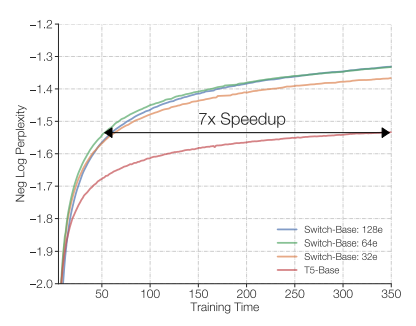

[Switch Transformer의 학습 속도]

 https://arxiv.org/pdf/2101.03961.pdf

Switch Transformer의 특징 중 하나는 1조 6천억 개의 파라미터를 가졌다는 것입니다. 이전까지 이렇게 많은 파라미터를 가진 모델은 없었어요. 아래의 그림은 Transformer 계열 모델의 파라미터를 비교한 것인데요, 파라미터가 많다고 여겨졌던 GPT3와는 비교할 수 없을 정도로 파라미터의 수가 큰 것을 알 수 있습니다.

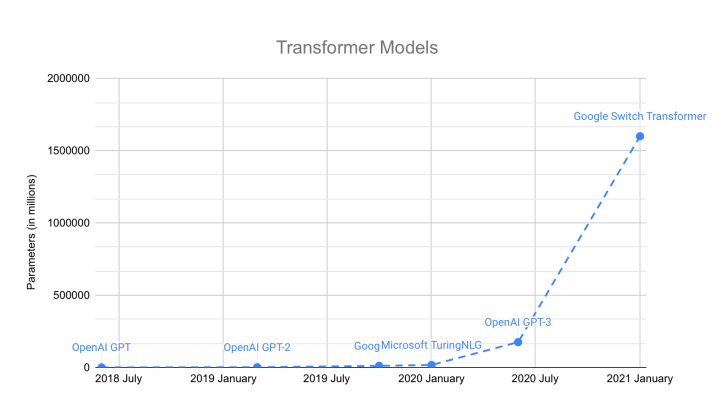

[모델의 파라미터 수 비교]

일반적으로 파라미터의 수가 증가하면 성능도 증가하지만, 계산 비용이 증가하고 학습 시간도 오래 걸리는 단점이 있습니다. 그러나 Switch Transformer는 이런 단점을 해결하기 위해 다양한 방법을 시도하였고, 결국 성공하였죠. 이제부터 Switch Transformer가 많은 수의 파라미터로 인한 단점을 보완하기 위해 사용한 여러 방법을 하나씩 알아봅시다.

MoE
---
Switch Transformer의 가장 큰 특징은 Transformer의 FFN(Feed Forward Network) 레이어를 MoE(Mixture of Expert) 레이어로 바꾸었다는 것입니다.

우선 MOE가 무엇인지 설명해야겠죠? 예를 들어 '고양이'라는 클래스가 있을 때 고양이 클래스를 나타내는 이미지는 다양할 것입니다. 고양이의 일부만 보일 수 있고, 다른 객체들이 고양이와 함께 있는 이미지도 있을 수 있겠죠. 그런 경우 하나의 모델이 다양한 입력 이미지를 학습하기 어려울 수 있기 때문에 'expert'라는 개념을 도입했습니다. 고양이의 일부만 보는 expert, 객체 탐지 expert, 배경 분리 expert 등의 다양한 expert를 두고, gate 또는 router라고 불리는 곳에서 각각의 입력에 대해 적합한 expert를 할당하는 거죠.

gate에서는 하나의 입력과 가중치를 곱해 softmax를 통과시켜, 높은 확률 순으로 적당한 expert 후보를 top K개 뽑고, top K개의 expert와 입력을 연산한 결과를 가중합하여 출력하게 됩니다.

그런데 MoE에는 몇 가지 단점이 있었습니다. 구조가 복잡하고 expert간 커뮤니케이션 비용이 높으며 학습이 불안정하다는 것이었죠.

**Q. MoE 를 사용하는 모델을 "Sparsely-activated model"이라 달리 부르기도 합니다. 왜인지 생각해보고 맞혀볼까요?**

A. [ 답변을 적어볼까요! ]

<details>
<summary>💡예시답안 확인하기💡</summary>

앞서 말씀드렸듯, MoE는 여러 개의 expert로 구성됩니다. 각 expert는 주어진 입력에 대해 독립적으로 작동하며, 다른 전문가들과 상호 작용하지 않습니다. 즉 어떤 입력 데이터에 대해 일부 expert들만 활성화되고, 대부분의 나머지는 관련이 없어 작동하지 않겠죠. 이 점이 모든 노드가 활성화되는 FFN와 구별되기에 sparsely-activated model이라 부르기도 합니다.

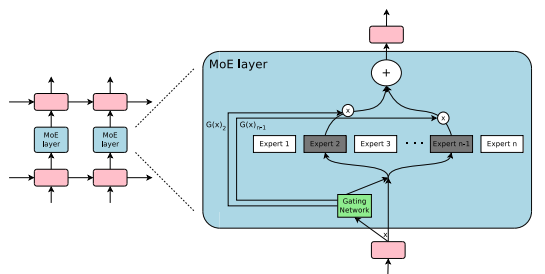

[A Mixture of Experts]

 https://arxiv.org/pdf/1701.06538.pdf

Switch Routing
---
Switch Transformer는 MoE의 단점을 해결하기 위해 expert를 1개만 선택하였습니다. 아래의 그림에서 보듯 여러 개의 토큰이 입력으로 들어오게 되면 Router라는 곳에서 각 토큰에 적합한 expert를 하나만 지정해 주는 것죠.

이로 인해 성능은 기존의 MoE와 비슷하지만 router의 연산과 batch 사이즈, 그리고 routing 연산 후의 expert간 커뮤티케이션 비용이 줄어든다는 효과를 얻을 수 있었습니다.

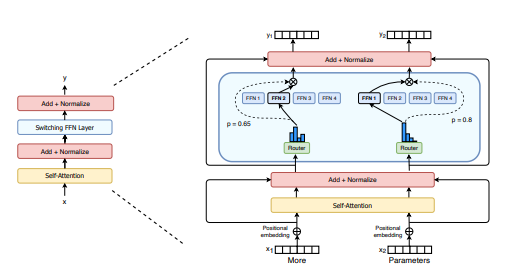

[Switch Transformer encoder block.]

 https://arxiv.org/pdf/2101.03961.pdf

Distributed Switch Implementation
---
하나의 token에 하나의 expert를 지정한다고 해도 expert의 수가 제한되어 있기 때문에 token이 많아지면 한 expert에 여러 개의 token이 몰리게 되는 현상이 일어날 수 있습니다. 각 expert에 token이 고르게 배정된다면 이상적이겠지만 하나의 expert에 많은 token이 배정되고, 어떤 expert에는 token이 배정되지 않는 경우가 있을 수도 있겠죠.

이런 경우를 방지하기 위해서 Switch Transformer는 **Distributed Switch Implementation**라는 방법을 고안해 하나의 expert에 배정될 token의 수를 제한해 두었습니다. 아래의 그림에서 보듯 capacity factor라는 것을 두어 expert가 배정받을 token 수를 제한한 거죠. 예를 들어 capacity factor가 1이면 배정될 token수는 2입니다. 당연하게도 capacity factor가 증가하면 계산 속도나 연산 비용은 늘어나겠죠?

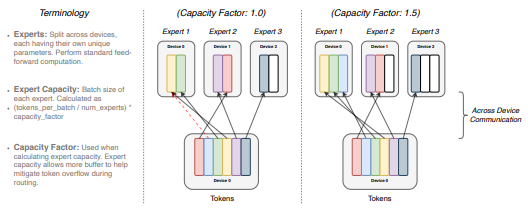

[token routing dynamics]

 https://arxiv.org/pdf/2101.03961.pdf

Differentiable Load Balancing Loss
---
한 expert에 배정될 token수가 제한되었다 하더라도 일부의 expert에 token이 더 몰릴 가능성이 있습니다. 따라서 각각의 expert에 token이 골고루 배분되도록 Switch Transformer는 load balancing loss라는 것을 만들어 두었습니다. 간단히 설명하자면 router에서 각 expert에 대한 확률값의 최대값이 최소화되도록 기존의 loss에 load balancing loss라는 항을 더해 주는 겁니다. 이에 대한 식은 아래와 같고, $α$는 0.01로 해 주었습니다.

$$\text{loss} = \alpha N \cdot \sum_{i=1}^N f_i \cdot P_i$$

Selective precision
---
Google Brain 팀에서는 bfloat16(Brain Floating Point Format)라는 새로운 데이터타입을 만들었습니다. bfloat16는 floating point를 16 비트로 줄인 후, 지수부가 32만큼 넓은 range를 표현할 수 있도록 하되, precision을 희생하는 부동소수점 포맷입니다. 보통 거대한 모델에서는 bfloat16을 사용하면 모델을 효율적으로 학습시킬 수 있었지만, MoE 모델에서는 bfloat16을 사용하면 발산하는 문제가 생겼다고 합니다.

그래서 Switch Transformer에서는 router 레이어에서만 bfloat32를 사용하고, 그 외의 부분에서는 bfloat16을 사용해 발산하는 문제도 줄이고 효율적인 커뮤니케이션도 가능하도록 했습니다.

이 외에도 Switch Transformer에서 사용된 다양한 방법에는 parameter initialization를 작게 만들거나 expert dropout와 기존의 dropout을 적절히 조정해 사용하는 selective dropout을 사용하는 것 등이 있습니다.

더 자세히 알아보고 싶다면 Switch Transformer의 논문을 직접 읽어보고, 코드도 한번 살펴보세요.

  - [SWITCH TRANSFORMERS: SCALING TO TRILLION PARAMETER MODELS WITH SIMPLE AND EFFICIENT SPARSITY](https://arxiv.org/pdf/2101.03961)
  - [Switch Transformer 코드](https://github.com/tensorflow/mesh/blob/master/mesh_tensorflow/transformer/moe.py)

# ERNIE

이번에는 조금 특별한 모델을 살펴볼 예정입니다. 지금까지 살펴본 모델들은 우리가 흔히 접하는 Tensorflow나 PyTorch같은 프레임워크로 구현이 되었습니다. 그런데 이제부터 살펴볼 모델은 [PaddlePaddle](https://github.com/PaddlePaddle/Paddle)이라는 중국의 오픈소스 프레임워크를 사용하였습니다.

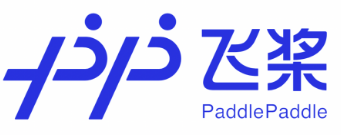

https://github.com/paddlepaddle/paddle

PaddlePaddle은 'PArallel Distributed Deep LEarning’의 약자로, 중국의 검색엔진 Baidu에서 만든 머신러닝 프레임워크입니다. 코어 라이브러리는 C++이고, Python으로 인터페이스를 만들었다고 하네요.

그 후 PaddlePaddle을 사용한 모델이 여러 개 만들어졌고, 그 중 하나가 ERNIE입니다. 사실 ERNIE는 두 가지 버전이 있어요. 하나는 칭화대에서 만든 [ERNIE: Enhanced Language Representation with Informative Entities](https://arxiv.org/pdf/1905.07129)이고, 다른 하나는 바이두에서 만든 [ERNIE: Enhanced Representation through Knowledge Integration](https://arxiv.org/pdf/1904.09223)입니다.

ERNIE라고 불리기에는 조금 억지가 아닌가 싶지만 BERT에게 친구를 만들어주긴 위한 중국인들의 노력이 가상하지 않나요? 😝

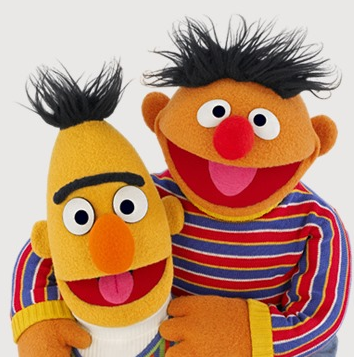

[사이 좋은 Bert와 Ernie]

 https://www.facebook.com/SesameBertandErnie

2가지 버전의 ERNIE 중 바이두에서 만든 ERNIE를 살펴볼 예정인데요, 그 이유는 바이두의 ERNIE v3가 [SuperGLUE Leaderboard](https://super.gluebenchmark.com/leaderboard/)에서 1등을 차지하기도 하였고, 바이두에서 계속해서 발전된 모델을 선보이고 있기 때문이기도 해요.

아래의 그림에서처럼 바이두의 ENRIE는 다양한 버전이 존재하고, 라이브러리도 지원되며 서버로 서비스할 수 있는 모듈까지 제공하고 있습니다.

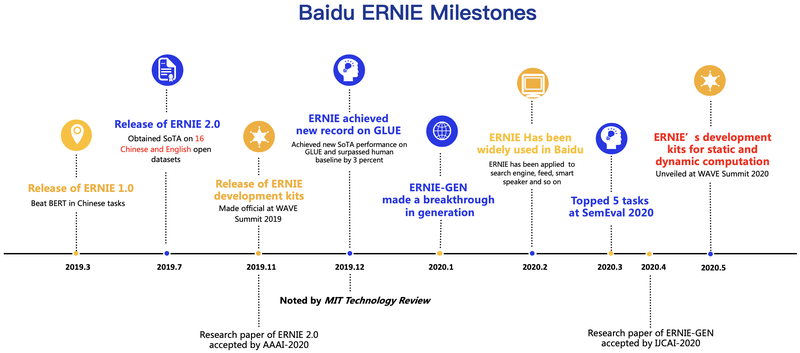

[ERNIE milestone]

 https://code.ihub.org.cn/projects/686/repository/revisions/develop/entry/.metas/ERNIE_milestone_en.png

위에서도 살짝 언급했듯이 ERNIE는 버전 3까지 있는데요, 이번 스텝에서는 v1만 살펴볼 예정입니다. 논문 [ERNIE: Enhanced Representation through Knowledge Integration](https://arxiv.org/pdf/1904.09223)에서 소개된 ERNIE v1를 살펴볼까요?

Masking Strategies
---
ERNIE는 아래의 한 문장으로 요약할 수 있습니다. 다양한 마스킹 전략을 통해 language representation을 향상시켰다는 거죠.

>ERNIE is designed to learn language representation enhanced by knowledge masking strategies, which includes entity-level masking and phrase-level masking.

ERNIE는 일반적인 마스킹 방법뿐 아니라 Phrase-Level Masking과 Entity-Level Masking을 추가로 사용하였습니다. 일반적인 마스킹 방법은 각 글자를 단위로 하여 입력의 15%를 무작위로 마스킹하였지만, ENRIE의 경우 구문 전체를 마스킹(Phrase-Level Masking)하거나 고유 명사 전체를 마스킹(Entity-Level Masking)하였죠. 이는 모델에 사전 지식을 주입하기 위한 것이었어요.

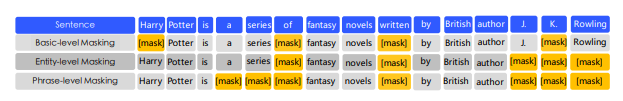

[ERNIE에 사용된 다양한 마스킹 방식]

 https://arxiv.org/pdf/1904.09223.pdf

Transformer Encoder
---
ERNIE는 GPT, BERT, XLM과 같이 여러 층을 쌓은 Transformer를 Encoder로 사용했어요. 하지만 중국어 corpus를 사용하기 때문에 CJK Unicode에 있는 모든 글자에 공간을 추가해주었고, WordPiece를 사용했다고 해요.

ERNIE는 BERT와 같이 12개의 Encoder layer, 768개의 Hidden Units, 12개의 Attention Head로 구성되어 있고, 중국어 위키피디아, 바이두 백과, 바이두 뉴스, 레딧과 비슷한 포럼 공간인 바이두 티에바에서 가져온 다양한 데이터를 입력 데이터로 사용합니다. 특히 바이두 티에바에서는 다이얼로그 형식의 데이터를 가지고 와 DLM task에 사용했다고 해요.

DLM(Dialogue Language Model)는 대화형 데이터를 학습하기 위해 도입된 것으로, 아래 그림에서와 같이 Dialogue embedding을 사용해 다이얼로그의 역할을 구분하였습니다. Dialogue embedding은 BERT의 token embedding과 같은 역할을 하지만 여러 번의 턴(turn)을 가지는 대화를 표현할 수 있도록 하였어요. 예를 들어 QRQ, QRR, QQR과 같은 식으로 말이죠. 여기서 Q는 Query, R은 Response에요. ERNIE는 Q와 R에 마스킹을 씌워 마스킹된 단어를 예측하게 하기도 하고, 가짜 대화를 만들어서 DLM이 여러 번의 턴을 가지는 대화가 진짜인지, 가짜인지 판단하도록 하기도 했어요.

DLM task는 ERNIE가 대화에서 암묵적인 관계를 학습하도록 해 semantic representation을 잘 학습할 수 있도록 도와주었습니다. 또한 MLM과 같은 구조와 역할을 하기 때문에 BERT의 MLM 대신 DLM을 사용했다고 하네요.

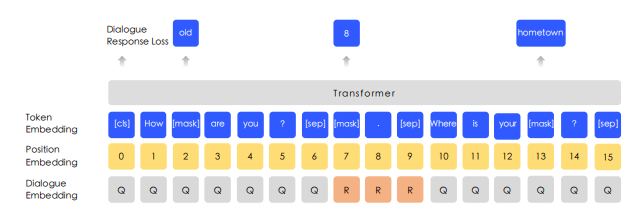

[Dialogue Language Model]

 https://arxiv.org/pdf/1904.09223.pdf

ERNIE v1이 나온지 3개월만에 v2가 나왔습니다. ERNIE v2는 pretraining할 때 여러 task를 추가해 학습하는 방식을 사용했어요. 2021년에 나온 ERNIE v3은 v1과 v2를 합친 모델이에요. 자세한 내용은 아래의 논문을 참고해 보세요.

  - [ERNIE 2.0: A Continual Pre-Training Framework for Language Understanding](https://arxiv.org/pdf/1907.12412)
  - [ERNIE 3.0: LARGE-SCALE KNOWLEDGE ENHANCED PRE-TRAINING FOR LANGUAGE UNDERSTANDING AND GENERATION](https://arxiv.org/pdf/2107.02137)

**Q. ERNIE가 앞에서 설명한 모델들과 같는 차이점은 무엇이 있나요? 하나만 적어주세요.**

A. [ 구문 단위를 마스킹하거나, 고유명사를 가리는 entity-level masking 활용 등이 포함되죠.
! ]

<details>
<summary>💡예시답안 확인하기💡</summary>

다양한 마스킹전략을 사용하였습니다. Phrase-level masking을 통해 구문 단위를 마스킹하거나, 고유명사를 가리는 entity-level masking 활용 등이 포함되죠.

DLM(Dialogue Language Model)개념도 앞의 모델들과 다릅니다. 대화의 형태를 표현하기 위해 query와 response에 대한 임베딩이 단어 임베딩 과정에 포함되어 있고, 학습 단계에서도 활용됩니다. 이를 통해 모델이 semantic representation을 잘 학습했다고 해요.

# 마무리하며

## 종합 문제
---
Transformer 이후의 흐름을 살펴보았습니다. 어떠신가요? 기술의 흐름이 너무나도 빨라 숨가쁘게 따라오시지는 않으셨는지요?

지금까지 여러분들이 얼마나 학습을 충실히 하셨는지 알아볼까 합니다. 여러분의 실력을 쑥쑥 향상시켜줄 수 있는 퀴즈이기도 하므로 배운 내용을 다시 생각하면서 아래의 퀴즈를 빠짐없이 풀어보세요. 🤗

**Q. 임베딩 모델은 크게 AR(AutoRegressive)모델과 AE(AutoEncoding)모델로 나뉩니다. 각각에 대하여 짧게 설명해볼까요?**

A. [ AR(AutoRegressive) 모델: 이전 문맥을 바탕으로 다음 단어를 예측합니다. 대신 문맥을 양방향으로 보기가 힘들어요.
AE(AutoEncoding) 모델: 앞뒤 문맥을 모두 살펴 [MASK] 단어를 예측합니다. 하지만 마스킹 처리한 토큰이 독립적으로 예측되므로 토큰 사이의 의존 관계를 학습할 수 없는데다가 fine-tuning과 evaluation 시 [MASK] 토큰이 보이지 않아 불일치가 발생할 수 있습니다 ]

<details>
<summary>💡예시답안 확인하기💡</summary>

AR(AutoRegressive) 모델: 이전 문맥을 바탕으로 다음 단어를 예측합니다. 대신 문맥을 양방향으로 보기가 힘들어요.
AE(AutoEncoding) 모델: 앞뒤 문맥을 모두 살펴 [MASK] 단어를 예측합니다. 하지만 마스킹 처리한 토큰이 독립적으로 예측되므로 토큰 사이의 의존 관계를 학습할 수 없는데다가 fine-tuning과 evaluation 시 [MASK] 토큰이 보이지 않아 불일치가 발생할 수 있습니다.

**Q. BERT는 뛰어난 성능을 보여주며 transformer 계열 모델의 부흥을 일으켰는데요, BERT의 학습 방법 중 '두 문장의 순서가 올바른지 확인'하는 task는 무엇이었나요?**

A. [NSP(Next Sentence Prediction)입니다! 이를 위해 BERT의 학습 데이터는 1건당 두 개의 문장으로 구성합니다. 50%의 확률로 TRUE와 FALSE를 부여하도록 만들죠. 이렇게 NSP를 학습하게 되면, 문장과 문장 사이의 관계를 학습할 수 있게 됩니다.  ]

<details>
<summary>💡예시답안 확인하기💡</summary>

정답은 NSP(Next Sentence Prediction)입니다! 이를 위해 BERT의 학습 데이터는 1건당 두 개의 문장으로 구성합니다. 50%의 확률로 TRUE와 FALSE를 부여하도록 만들죠. 이렇게 NSP를 학습하게 되면, 문장과 문장 사이의 관계를 학습할 수 있게 됩니다. 그러나 연산량이 적지 않은 관계로, ALBERT에서는 해당 task를 Sentence Order Prediction(SOP)로 대체하죠.

종합 퀴즈의 난도는 어떠셨나요?

학습을 충실히 하셨다면 쉽게 해결하셨을 것이라 생각합니다. 혹시라도 답을 맞추지 못하셨다면 다시 한번 배웠던 내용을 복습해 보세요.

지금까지 수고 많이 하셨습니다! 🫡